In [15]:
import pandas as pd
import lightgbm as lgb
import pickle
import numpy as np
import os
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error # RMSE計算に必要

# === 設定 ===
csv_path_nc = 'ML_data/tox24_t_mord.csv'  # 最初のCSVファイルのパスを指定 (non-canonical)
csv_path_c = 'ML_data/tox24_t_c_mord.csv'    # 2番目のCSVファイルのパスを指定 (canonical)
output_pkl_path = 'ML_data/folds.pkl' # 入力pklファイル名 (分割情報)
y_column = 'y'                              # 目的変数カラム名
# 結合キーとして使用するカラム。SMILESは記述子として使わないため、Nのみに設定。
# 後で特徴量XからSMILESも除外します。
identifier_columns = ["N"]
# LightGBMのハイパーパラメータ (例示用, 最適化済みパラメータに置き換えること)
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 100,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42
}


# --- データ読み込みと初期チェック ---
print("--- データ読み込みと初期チェック ---")
try:
    df_nc = pd.read_csv(csv_path_nc)
    df_c = pd.read_csv(csv_path_c)
    print(f"'{csv_path_nc}' を読み込みました。形状: {df_nc.shape}")
    print(f"'{csv_path_c}' を読み込みました。形状: {df_c.shape}")
except FileNotFoundError as e:
    print(f"エラー: 指定されたCSVファイルが見つかりません: {e.filename}")
    print("CSVファイルが正しいディレクトリにあることを確認してください。")
    exit()

# 結合キーと目的変数カラムが各DataFrameに存在することを確認
required_nc_cols = identifier_columns + [y_column]
if not all(col in df_nc.columns for col in required_nc_cols):
    print(f"エラー: '{csv_path_nc}' に必要なカラム {required_nc_cols} のいずれかが見つかりません。")
    print("CSVファイルの列名を確認してください。")
    exit()

required_c_cols = identifier_columns
if not all(col in df_c.columns for col in required_c_cols):
    print(f"エラー: '{csv_path_c}' に必要なカラム {required_c_cols} のいずれかが見つかりません。")
    print("CSVファイルの列名を確認してください。")
    exit()

# SMILESカラムが両方に存在することを確認（結合キーとして使わなくても、後で除外対象とするため）
if "SMILES" not in df_nc.columns or "SMILES" not in df_c.columns:
    print("エラー: 'SMILES' カラムが両方のCSVファイルに存在しません。")
    print("SMILESカラムは結合後の特徴量から除外されますが、データ統合の際に存在することが期待されます。")
    exit()


# --- df_nc の前処理 ---
# SMILESカラムは識別子として扱い、プレフィックスはつけない
nc_cols_to_prefix = [col for col in df_nc.columns if col not in identifier_columns + [y_column, "SMILES"]]
if not nc_cols_to_prefix:
    print(f"警告: '{csv_path_nc}' にプレフィックス 'nc_' を付ける特徴量が見つかりません。")

df_nc_features_prefixed = df_nc[nc_cols_to_prefix].rename(columns={col: f'nc_{col}' for col in nc_cols_to_prefix})
df_nc_processed = pd.concat([df_nc[identifier_columns + [y_column, "SMILES"]], df_nc_features_prefixed], axis=1)
print(f"df_nc_processed の形状: {df_nc_processed.shape}")


# --- df_c の前処理 ---
# SMILESカラムは識別子として扱い、プレフィックスはつけない
# df_c に y_column が存在しないことを前提とする
c_cols_to_prefix = [col for col in df_c.columns if col not in identifier_columns + [y_column, "SMILES"]]
if not c_cols_to_prefix:
    print(f"警告: '{csv_path_c}' にプレフィックス 'c_' を付ける特徴量が見つかりません。")

df_c_features_prefixed = df_c[c_cols_to_prefix].rename(columns={col: f'c_{col}' for col in c_cols_to_prefix})
df_c_processed = pd.concat([df_c[identifier_columns + ["SMILES"]], df_c_features_prefixed], axis=1)
print(f"df_c_processed の形状: {df_c_processed.shape}")


# --- データフレーム結合処理 ---
print("\n--- データフレーム結合処理 ---")
initial_nc_rows = len(df_nc_processed)
initial_c_rows = len(df_c_processed)

# SMILESは結合キーではないが、結合後のDataFrameに残したいので、
# suffixを付けて結合し、後で重複するSMILESカラムを処理する
df = pd.merge(df_nc_processed, df_c_processed, on=identifier_columns, how='inner', suffixes=('_nc', '_c'))
print(f"データフレームを '{identifier_columns}' (Nのみ) でinner結合しました。")
print(f"結合前のdf_nc_processedの行数: {initial_nc_rows}")
print(f"結合前のdf_c_processedの行数: {initial_c_rows}")
print(f"結合後のdfの行数: {len(df)}")

if len(df) == 0:
    print("エラー: 結合後のデータフレームが空です。結合キーに一致するデータがない可能性があります。")
    exit()
if len(df) < min(initial_nc_rows, initial_c_rows):
    print(f"警告: 結合により一部のデータが失われた可能性があります。結合キー '{identifier_columns}' の不一致を確認してください。結合後の行数 {len(df)} vs 結合前の最小行数 {min(initial_nc_rows, initial_c_rows)}")

# 重複行のチェック
if df.duplicated(subset=identifier_columns).any():
    print(f"警告: 結合後のデータフレームに結合キー '{identifier_columns}' の重複があります。重複する行数: {df.duplicated(subset=identifier_columns).sum()}")
    # ここで重複を解消する必要がある場合、meanやfirstなどで集約することを検討
    # 例: df = df.drop_duplicates(subset=identifier_columns, keep='first')
    # ただし、元のデータ設計に依存するため、今回は警告のみに留めます。

# 結合後に生成されたSMILES_cカラムを削除（SMILES_ncを残すか、またはSMILES_cが不要であれば削除）
if 'SMILES_c' in df.columns and 'SMILES_nc' in df.columns:
    # どちらか一方を残すか、結合時にSMILESがNに対してユニークであることを確認すべき
    # ここではSMILES_ncを残し、SMILES_cを削除
    df.drop(columns=['SMILES_c'], inplace=True)
    df.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
    print("結合後の重複するSMILESカラム ('SMILES_c') を削除し、'SMILES_nc' を 'SMILES' にリネームしました。")
elif 'SMILES_c' in df.columns and 'SMILES_nc' not in df.columns: # df_ncにSMILESがないケース
    df.rename(columns={'SMILES_c': 'SMILES'}, inplace=True) # SMILES_cをSMILESにリネーム
elif 'SMILES_nc' in df.columns and 'SMILES_c' not in df.columns: # df_cにSMILESがないケース
    df.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True) # SMILES_ncをSMILESにリネーム
else:
    print("SMILESカラムの結合後処理はスキップされました。")


print(f"結合後のデータフレーム df の形状: {df.shape}")


# --- 特徴量と目的変数の分離 ---
print("\n--- 特徴量と目的変数の分離 ---")
# 結合後のDataFrameから、最終的に除外するカラムを定義
# N, y, SMILES を特徴量Xから除外します
final_exclude_columns_for_X = identifier_columns + [y_column, "SMILES"]

# df.columns に実際に存在するカラムのみをフィルタリング
actual_exclude_columns_for_X = [col for col in final_exclude_columns_for_X if col in df.columns]

X = df.drop(columns=actual_exclude_columns_for_X)
y = df[y_column] # y_column は df_nc から直接取得し、特徴量としてXに含めない

print(f"特徴量Xの形状: {X.shape}")
print(f"目的変数yの形状: {y.shape}")

if X.empty or X.shape[1] == 0:
    print("エラー: 特徴量Xが空または特徴量列がありません。モデル構築を中止します。")
    exit()
if y.empty:
    print("エラー: 目的変数yが空です。モデル構築を中止します。")
    exit()


# --- 数値型変換と欠損値処理、分散ゼロ特徴量削除 ---
print("\n--- 特徴量の数値型変換、欠損値処理、分散ゼロ処理 ---")
initial_X_cols = X.shape[1]
initial_X_rows = X.shape[0]

# 数値型への変換とNaNの確認
for col in X.columns:
    # errors='coerce' で変換できない値をNaNにする
    X[col] = pd.to_numeric(X[col], errors='coerce')

# 欠損値を含む列の削除 (このバージョンでは欠損値のある列を削除します)
cols_with_nan = X.columns[X.isnull().any()].tolist()
if cols_with_nan:
    X = X.drop(columns=cols_with_nan)
    print(f"警告: {len(cols_with_nan)} 個の欠損値を含む列を削除しました。")
    print(f"欠損値削除後の特徴量Xの形状: {X.shape}")
else:
    print("欠損値を含む列は見つかりませんでした。")

if X.empty or X.shape[1] == 0:
    print("エラー: 欠損値処理後、特徴量が残っていません。モデル構築を中止します。")
    exit()

# 分散がゼロの列の削除 (このバージョンでは分散ゼロの列も削除します)
selector = VarianceThreshold(threshold=0.0)
selector.fit(X)
cols_zero_variance = X.columns[~selector.get_support()].tolist()

if cols_zero_variance:
    X = X.drop(columns=cols_zero_variance)
    print(f"警告: {len(cols_zero_variance)} 個の分散がゼロの列を削除しました。")
    print(f"分散ゼロ削除後の特徴量Xの形状: {X.shape}")
else:
    print("分散がゼロの列は見つかりませんでした。")

print(f"最終的な特徴量Xの形状: {X.shape}")
print(f"前処理により {initial_X_cols - X.shape[1]} 列が削除されました（欠損値を含む列と分散ゼロの列）。")


# --- 分割情報の読み込み ---
print("\n--- 分割情報の読み込み ---")
try:
    with open(output_pkl_path, 'rb') as f:
        fold_dict = pickle.load(f)
    print(f"ファイル '{output_pkl_path}' から分割情報を読み込みました。")
except FileNotFoundError:
    print(f"エラー: ファイル '{output_pkl_path}' が見つかりません。")
    print("folds.pkl ファイルが 'ML_data' ディレクトリにあることを確認してください。")
    exit()
except Exception as e:
    print(f"エラー: '{output_pkl_path}' から fold_dict の読み込み中にエラーが発生しました: {e}")
    exit()

# fold_dict の構造からn_splitsを取得（最初のキーの 'N' を参照）
n_splits_from_pkl = fold_dict[0]['N'] if fold_dict and 0 in fold_dict and 'N' in fold_dict[0] else 5
print(f"検出されたフォールド数: {n_splits_from_pkl}")

# DataFrameのインデックスとfold_dictのマッピングを確認
fold_assignments = {}
missing_indices_in_fold_dict = 0
for idx in df.index.tolist():
    if idx in fold_dict:
        fold_assignments[idx] = fold_dict[idx]['fold']
    else:
        missing_indices_in_fold_dict += 1
if missing_indices_in_fold_dict > 0:
    print(f"警告: {missing_indices_in_fold_dict} 個のDataFrameインデックスがfold_dictに見つかりませんでした。CV分割が不完全になる可能性があります。")
if not fold_assignments:
    print("エラー: fold_assignmentsが空です。有効なフォールド割り当てがありません。モデル構築を中止します。")
    exit()
print(f"フォールド割り当てを {len(fold_assignments)} 個のデータポイントに対して作成しました。")


# --- LightGBM 5-fold Cross-Validation 開始 ---
print("\n--- LightGBM 5-fold Cross-Validation 開始 ---")
models = []
oof_predictions = np.zeros(len(df)) # dfの元のサイズで初期化
feature_importances = pd.DataFrame(index=X.columns)
fold_rmse_scores = []

for fold in range(n_splits_from_pkl):
    print(f"--- フォールド {fold+1}/{n_splits_from_pkl} ---")

    train_indices = [idx for idx, assignment in fold_assignments.items() if assignment != fold and idx in X.index]
    test_indices = [idx for idx, assignment in fold_assignments.items() if assignment == fold and idx in X.index]

    if not train_indices or not test_indices:
        print(f"警告: フォールド {fold+1} の訓練セットまたはテストセットが空です。このフォールドをスキップします。")
        continue

    X_train, y_train = X.loc[train_indices], y.loc[train_indices]
    X_test, y_test = X.loc[test_indices], y.loc[test_indices]

    print(f"フォールド {fold+1} - 訓練セット形状: {X_train.shape}, テストセット形状: {X_test.shape}")
    if X_train.empty or y_train.empty or X_test.empty or y_test.empty or X_train.shape[1] == 0:
        print(f"エラー: フォールド {fold+1} の訓練セット/テストセットのデータまたは特徴量が空です。このフォールドをスキップします。")
        continue

    model = lgb.LGBMRegressor(**lgb_params)

    try:
        model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  eval_metric='rmse',
                  callbacks=[lgb.early_stopping(10, verbose=False)])

        fold_predictions = model.predict(X_test)
        oof_predictions[test_indices] = fold_predictions

        models.append(model)

        if not X.columns.empty and model.feature_importances_ is not None:
            feature_importances[f'fold_{fold}'] = pd.Series(model.feature_importances_, index=X.columns)
        else:
            print(f"警告: フォールド {fold+1} の特徴量重要度が取得できませんでした。")

        fold_rmse = np.sqrt(mean_squared_error(y_test, fold_predictions))
        print(f"フォールド {fold+1} RMSE: {fold_rmse:.4f}")
        fold_rmse_scores.append(fold_rmse)

    except Exception as e:
        print(f"エラー: フォールド {fold+1} のLightGBMモデル学習中に問題が発生しました: {e}")
        print("このフォールドはスキップされます。")
        continue


if fold_rmse_scores:
    average_rmse = np.mean(fold_rmse_scores)
    std_rmse = np.std(fold_rmse_scores)

    print(f"\n全フォールドの平均RMSE: {average_rmse:.4f} (標準偏差: {std_rmse:.4f})")
else:
    print("\nRMSEスコアは計算されませんでした（例: 空のフォールドやエラーのため）。")

if not feature_importances.empty:
    print("\n特徴量重要度 (全フォールドの平均):")
    avg_feature_importances = feature_importances.mean(axis=1).sort_values(ascending=False)
    print(avg_feature_importances)
else:
    print("\n表示する特徴量重要度がありません（例: 特徴量がないか、トレーニングが成功しなかったため）。")

print("\n--- 全データフレームの冒頭 (df) ---")
print(df.head())
print(f"df の最終的な形状: {df.shape}")
print("--- 処理完了 ---")

--- データ読み込みと初期チェック ---
'ML_data/tox24_t_mord.csv' を読み込みました。形状: (1211, 1616)
'ML_data/tox24_t_c_mord.csv' を読み込みました。形状: (1211, 1616)
df_nc_processed の形状: (1211, 1616)
df_c_processed の形状: (1211, 1615)

--- データフレーム結合処理 ---
データフレームを '['N']' (Nのみ) でinner結合しました。
結合前のdf_nc_processedの行数: 1211
結合前のdf_c_processedの行数: 1211
結合後のdfの行数: 1211
結合後の重複するSMILESカラム ('SMILES_c') を削除し、'SMILES_nc' を 'SMILES' にリネームしました。
結合後のデータフレーム df の形状: (1211, 3229)

--- 特徴量と目的変数の分離 ---
特徴量Xの形状: (1211, 3226)
目的変数yの形状: (1211,)

--- 特徴量の数値型変換、欠損値処理、分散ゼロ処理 ---
警告: 1613 個の欠損値を含む列を削除しました。
欠損値削除後の特徴量Xの形状: (1211, 1613)
警告: 242 個の分散がゼロの列を削除しました。
分散ゼロ削除後の特徴量Xの形状: (1211, 1371)
最終的な特徴量Xの形状: (1211, 1371)
前処理により 1855 列が削除されました（欠損値を含む列と分散ゼロの列）。

--- 分割情報の読み込み ---
ファイル 'ML_data/folds.pkl' から分割情報を読み込みました。
検出されたフォールド数: 5
フォールド割り当てを 1211 個のデータポイントに対して作成しました。

--- LightGBM 5-fold Cross-Validation 開始 ---
--- フォールド 1/5 ---
フォールド 1 - 訓練セット形状: (968, 1371), テストセット形状: (243, 1371)
フォールド 1 RMSE: 22.5831
--- フォールド 2/5 ---
フォールド 2 - 訓練セット形状: (969, 1371

In [16]:
import pandas as pd
import lightgbm as lgb
import pickle
import numpy as np
import os
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error # RMSE計算に必要

# === 設定 ===
csv_path_nc = 'ML_data/tox24_t_mord.csv'  # 最初のCSVファイルのパスを指定 (non-canonical)
csv_path_c = 'ML_data/tox24_t_c_mord.csv'    # 2番目のCSVファイルのパスを指定 (canonical)
output_pkl_path = 'ML_data/folds.pkl' # 入力pklファイル名 (分割情報)
y_column = 'y'                              # 目的変数カラム名
# 結合キーとして使用するカラム。SMILESは記述子として使わないため、Nのみに設定。
# 後で特徴量XからSMILESも除外します。
identifier_columns = ["N"]
# LightGBMのハイパーパラメータ (例示用, 最適化済みパラメータに置き換えること)
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 100,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42
}


# --- データ読み込みと初期チェック ---
print("--- データ読み込みと初期チェック ---")
try:
    df_nc = pd.read_csv(csv_path_nc)
    df_c = pd.read_csv(csv_path_c)
    print(f"'{csv_path_nc}' を読み込みました。形状: {df_nc.shape}")
    print(f"'{csv_path_c}' を読み込みました。形状: {df_c.shape}")
except FileNotFoundError as e:
    print(f"エラー: 指定されたCSVファイルが見つかりません: {e.filename}")
    print("CSVファイルが正しいディレクトリにあることを確認してください。")
    exit()

# 結合キーと目的変数カラムが各DataFrameに存在することを確認
required_nc_cols = identifier_columns + [y_column]
if not all(col in df_nc.columns for col in required_nc_cols):
    print(f"エラー: '{csv_path_nc}' に必要なカラム {required_nc_cols} のいずれかが見つかりません。")
    print("CSVファイルの列名を確認してください。")
    exit()

required_c_cols = identifier_columns
if not all(col in df_c.columns for col in required_c_cols):
    print(f"エラー: '{csv_path_c}' に必要なカラム {required_c_cols} のいずれかが見つかりません。")
    print("CSVファイルの列名を確認してください。")
    exit()

# SMILESカラムが両方に存在することを確認（結合キーとして使わなくても、後で除外対象とするため）
if "SMILES" not in df_nc.columns or "SMILES" not in df_c.columns:
    print("エラー: 'SMILES' カラムが両方のCSVファイルに存在しません。")
    print("SMILESカラムは結合後の特徴量から除外されますが、データ統合の際に存在することが期待されます。")
    exit()


# --- df_nc の前処理 ---
# SMILESカラムは識別子として扱い、プレフィックスはつけない
nc_cols_to_prefix = [col for col in df_nc.columns if col not in identifier_columns + [y_column, "SMILES"]]
if not nc_cols_to_prefix:
    print(f"警告: '{csv_path_nc}' にプレフィックス 'nc_' を付ける特徴量が見つかりません。")

df_nc_features_prefixed = df_nc[nc_cols_to_prefix].rename(columns={col: f'nc_{col}' for col in nc_cols_to_prefix})
df_nc_processed = pd.concat([df_nc[identifier_columns + [y_column, "SMILES"]], df_nc_features_prefixed], axis=1)
print(f"df_nc_processed の形状: {df_nc_processed.shape}")


# --- df_c の前処理 ---
# SMILESカラムは識別子として扱い、プレフィックスはつけない
# df_c に y_column が存在しないことを前提とする
c_cols_to_prefix = [col for col in df_c.columns if col not in identifier_columns + [y_column, "SMILES"]]
if not c_cols_to_prefix:
    print(f"警告: '{csv_path_c}' にプレフィックス 'c_' を付ける特徴量が見つかりません。")

df_c_features_prefixed = df_c[c_cols_to_prefix].rename(columns={col: f'c_{col}' for col in c_cols_to_prefix})
df_c_processed = pd.concat([df_c[identifier_columns + ["SMILES"]], df_c_features_prefixed], axis=1)
print(f"df_c_processed の形状: {df_c_processed.shape}")


# --- データフレーム結合処理 ---
print("\n--- データフレーム結合処理 ---")
initial_nc_rows = len(df_nc_processed)
initial_c_rows = len(df_c_processed)

# SMILESは結合キーではないが、結合後のDataFrameに残したいので、
# suffixを付けて結合し、後で重複するSMILESカラムを処理する
df = pd.merge(df_nc_processed, df_c_processed, on=identifier_columns, how='inner', suffixes=('_nc', '_c'))
print(f"データフレームを '{identifier_columns}' (Nのみ) でinner結合しました。")
print(f"結合前のdf_nc_processedの行数: {initial_nc_rows}")
print(f"結合前のdf_c_processedの行数: {initial_c_rows}")
print(f"結合後のdfの行数: {len(df)}")

if len(df) == 0:
    print("エラー: 結合後のデータフレームが空です。結合キーに一致するデータがない可能性があります。")
    exit()
if len(df) < min(initial_nc_rows, initial_c_rows):
    print(f"警告: 結合により一部のデータが失われた可能性があります。結合キー '{identifier_columns}' の不一致を確認してください。結合後の行数 {len(df)} vs 結合前の最小行数 {min(initial_nc_rows, initial_c_rows)}")

# 重複行のチェック
if df.duplicated(subset=identifier_columns).any():
    print(f"警告: 結合後のデータフレームに結合キー '{identifier_columns}' の重複があります。重複する行数: {df.duplicated(subset=identifier_columns).sum()}")
    # ここで重複を解消する必要がある場合、meanやfirstなどで集約することを検討
    # 例: df = df.drop_duplicates(subset=identifier_columns, keep='first')
    # ただし、元のデータ設計に依存するため、今回は警告のみに留めます。

# 結合後に生成されたSMILES_cカラムを削除（SMILES_ncを残すか、またはSMILES_cが不要であれば削除）
if 'SMILES_c' in df.columns and 'SMILES_nc' in df.columns:
    # どちらか一方を残すか、結合時にSMILESがNに対してユニークであることを確認すべき
    # ここではSMILES_ncを残し、SMILES_cを削除
    df.drop(columns=['SMILES_c'], inplace=True)
    df.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
    print("結合後の重複するSMILESカラム ('SMILES_c') を削除し、'SMILES_nc' を 'SMILES' にリネームしました。")
elif 'SMILES_c' in df.columns and 'SMILES_nc' not in df.columns: # df_ncにSMILESがないケース
    df.rename(columns={'SMILES_c': 'SMILES'}, inplace=True) # SMILES_cをSMILESにリネーム
elif 'SMILES_nc' in df.columns and 'SMILES_c' not in df.columns: # df_cにSMILESがないケース
    df.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True) # SMILES_ncをSMILESにリネーム
else:
    print("SMILESカラムの結合後処理はスキップされました。")


print(f"結合後のデータフレーム df の形状: {df.shape}")


# --- 特徴量と目的変数の分離 ---
print("\n--- 特徴量と目的変数の分離 ---")
# 結合後のDataFrameから、最終的に除外するカラムを定義
# N, y, SMILES を特徴量Xから除外します
final_exclude_columns_for_X = identifier_columns + [y_column, "SMILES"]

# df.columns に実際に存在するカラムのみをフィルタリング
actual_exclude_columns_for_X = [col for col in final_exclude_columns_for_X if col in df.columns]

X = df.drop(columns=actual_exclude_columns_for_X)
y = df[y_column] # y_column は df_nc から直接取得し、特徴量としてXに含めない

print(f"特徴量Xの形状: {X.shape}")
print(f"目的変数yの形状: {y.shape}")

if X.empty or X.shape[1] == 0:
    print("エラー: 特徴量Xが空または特徴量列がありません。モデル構築を中止します。")
    exit()
if y.empty:
    print("エラー: 目的変数yが空です。モデル構築を中止します。")
    exit()


# --- 数値型変換と欠損値処理、値が全く同じ列の削除 ---
print("\n--- 特徴量の数値型変換と列の重複削除 ---")
initial_X_cols = X.shape[1]

# 数値型への変換とNaNの確認
for col in X.columns:
    # errors='coerce' で変換できない値をNaNにする
    X[col] = pd.to_numeric(X[col], errors='coerce')

# c_xxxとnc_xxxで始まる列名を持つ特徴量のリストを取得
c_cols = [col for col in X.columns if col.startswith('c_')]
nc_cols = [col for col in X.columns if col.startswith('nc_')]

# 共通のベース名を持つ列を特定 (例: 'c_ABC' と 'nc_ABC' の 'ABC')
common_base_names = set([col[2:] for col in c_cols]) & set([col[3:] for col in nc_cols])

# 値が全く同じであるc_xxxまたはnc_xxx列を格納するリスト
cols_to_drop_due_to_exact_match = []

for base_name in sorted(list(common_base_names)):
    col_c = f'c_{base_name}'
    col_nc = f'nc_{base_name}'

    if col_c in X.columns and col_nc in X.columns:
        # isnull().all() は全てNaNの場合 True を返すので、全てNaNの場合も考慮
        # Series.equals() はNaNも考慮して厳密な比較を行う
        if X[col_c].equals(X[col_nc]):
            cols_to_drop_due_to_exact_match.append(col_c)
            # どちらか一方を削除。ここでは nc_xxx を残し、c_xxx を削除する
            # または、どちらでもよい場合は、一貫したルールで削除する
            # print(f"情報: 列 '{col_c}' と '{col_nc}' の値が完全に一致するため、'{col_c}' を削除します。")

if cols_to_drop_due_to_exact_match:
    X = X.drop(columns=cols_to_drop_due_to_exact_match)
    print(f"情報: {len(cols_to_drop_due_to_exact_match)} 個のCとNCで値が完全に一致する列（c_xxx側）を削除しました。")
    print(f"重複列削除後の特徴量Xの形状: {X.shape}")
else:
    print("CとNCで値が完全に一致する列は見つかりませんでした。")


# 欠損値を含む列の削除
cols_with_nan = X.columns[X.isnull().any()].tolist()
if cols_with_nan:
    X = X.drop(columns=cols_with_nan)
    print(f"警告: {len(cols_with_nan)} 個の欠損値を含む列を削除しました。")
    print(f"欠損値削除後の特徴量Xの形状: {X.shape}")
else:
    print("欠損値を含む列は見つかりませんでした。")

if X.empty or X.shape[1] == 0:
    print("エラー: 欠損値処理後、特徴量が残っていません。モデル構築を中止します。")
    exit()

# 分散がゼロの列の削除
selector = VarianceThreshold(threshold=0.0)
selector.fit(X)
cols_zero_variance = X.columns[~selector.get_support()].tolist()

if cols_zero_variance:
    X = X.drop(columns=cols_zero_variance)
    print(f"警告: {len(cols_zero_variance)} 個の分散がゼロの列を削除しました。")
    print(f"分散ゼロ削除後の特徴量Xの形状: {X.shape}")
else:
    print("分散がゼロの列は見つかりませんでした。")

print(f"最終的な特徴量Xの形状: {X.shape}")
print(f"前処理により {initial_X_cols - X.shape[1]} 列が削除されました（重複列、欠損値を含む列、分散ゼロの列）。")


# --- 分割情報の読み込み ---
print("\n--- 分割情報の読み込み ---")
try:
    with open(output_pkl_path, 'rb') as f:
        fold_dict = pickle.load(f)
    print(f"ファイル '{output_pkl_path}' から分割情報を読み込みました。")
except FileNotFoundError:
    print(f"エラー: ファイル '{output_pkl_path}' が見つかりません。")
    print("folds.pkl ファイルが 'ML_data' ディレクトリにあることを確認してください。")
    exit()
except Exception as e:
    print(f"エラー: '{output_pkl_path}' から fold_dict の読み込み中にエラーが発生しました: {e}")
    exit()

# fold_dict の構造からn_splitsを取得（最初のキーの 'N' を参照）
n_splits_from_pkl = fold_dict[0]['N'] if fold_dict and 0 in fold_dict and 'N' in fold_dict[0] else 5
print(f"検出されたフォールド数: {n_splits_from_pkl}")

# DataFrameのインデックスとfold_dictのマッピングを確認
fold_assignments = {}
missing_indices_in_fold_dict = 0
for idx in df.index.tolist():
    if idx in fold_dict:
        fold_assignments[idx] = fold_dict[idx]['fold']
    else:
        missing_indices_in_fold_dict += 1
if missing_indices_in_fold_dict > 0:
    print(f"警告: {missing_indices_in_fold_dict} 個のDataFrameインデックスがfold_dictに見つかりませんでした。CV分割が不完全になる可能性があります。")
if not fold_assignments:
    print("エラー: fold_assignmentsが空です。有効なフォールド割り当てがありません。モデル構築を中止します。")
    exit()
print(f"フォールド割り当てを {len(fold_assignments)} 個のデータポイントに対して作成しました。")


# --- LightGBM 5-fold Cross-Validation 開始 ---
print("\n--- LightGBM 5-fold Cross-Validation 開始 ---")
models = []
oof_predictions = np.zeros(len(df)) # dfの元のサイズで初期化
feature_importances = pd.DataFrame(index=X.columns)
fold_rmse_scores = []

for fold in range(n_splits_from_pkl):
    print(f"--- フォールド {fold+1}/{n_splits_from_pkl} ---")

    train_indices = [idx for idx, assignment in fold_assignments.items() if assignment != fold and idx in X.index]
    test_indices = [idx for idx, assignment in fold_assignments.items() if assignment == fold and idx in X.index]

    if not train_indices or not test_indices:
        print(f"警告: フォールド {fold+1} の訓練セットまたはテストセットが空です。このフォールドをスキップします。")
        continue

    X_train, y_train = X.loc[train_indices], y.loc[train_indices]
    X_test, y_test = X.loc[test_indices], y.loc[test_indices]

    print(f"フォールド {fold+1} - 訓練セット形状: {X_train.shape}, テストセット形状: {X_test.shape}")
    if X_train.empty or y_train.empty or X_test.empty or y_test.empty or X_train.shape[1] == 0:
        print(f"エラー: フォールド {fold+1} の訓練セット/テストセットのデータまたは特徴量が空です。このフォールドをスキップします。")
        continue

    model = lgb.LGBMRegressor(**lgb_params)

    try:
        model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  eval_metric='rmse',
                  callbacks=[lgb.early_stopping(10, verbose=False)])

        fold_predictions = model.predict(X_test)
        oof_predictions[test_indices] = fold_predictions

        models.append(model)

        if not X.columns.empty and model.feature_importances_ is not None:
            feature_importances[f'fold_{fold}'] = pd.Series(model.feature_importances_, index=X.columns)
        else:
            print(f"警告: フォールド {fold+1} の特徴量重要度が取得できませんでした。")

        fold_rmse = np.sqrt(mean_squared_error(y_test, fold_predictions))
        print(f"フォールド {fold+1} RMSE: {fold_rmse:.4f}")
        fold_rmse_scores.append(fold_rmse)

    except Exception as e:
        print(f"エラー: フォールド {fold+1} のLightGBMモデル学習中に問題が発生しました: {e}")
        print("このフォールドはスキップされます。")
        continue


if fold_rmse_scores:
    average_rmse = np.mean(fold_rmse_scores)
    std_rmse = np.std(fold_rmse_scores)

    print(f"\n全フォールドの平均RMSE: {average_rmse:.4f} (標準偏差: {std_rmse:.4f})")
else:
    print("\nRMSEスコアは計算されませんでした（例: 空のフォールドやエラーのため）。")

if not feature_importances.empty:
    print("\n特徴量重要度 (全フォールドの平均):")
    avg_feature_importances = feature_importances.mean(axis=1).sort_values(ascending=False)
    print(avg_feature_importances)
else:
    print("\n表示する特徴量重要度がありません（例: 特徴量がないか、トレーニングが成功しなかったため）。")

print("\n--- 全データフレームの冒頭 (df) ---")
print(df.head())
print(f"df の最終的な形状: {df.shape}")
print("--- 処理完了 ---")

--- データ読み込みと初期チェック ---
'ML_data/tox24_t_mord.csv' を読み込みました。形状: (1211, 1616)
'ML_data/tox24_t_c_mord.csv' を読み込みました。形状: (1211, 1616)
df_nc_processed の形状: (1211, 1616)
df_c_processed の形状: (1211, 1615)

--- データフレーム結合処理 ---
データフレームを '['N']' (Nのみ) でinner結合しました。
結合前のdf_nc_processedの行数: 1211
結合前のdf_c_processedの行数: 1211
結合後のdfの行数: 1211
結合後の重複するSMILESカラム ('SMILES_c') を削除し、'SMILES_nc' を 'SMILES' にリネームしました。
結合後のデータフレーム df の形状: (1211, 3229)

--- 特徴量と目的変数の分離 ---
特徴量Xの形状: (1211, 3226)
目的変数yの形状: (1211,)

--- 特徴量の数値型変換と列の重複削除 ---
情報: 301 個のCとNCで値が完全に一致する列（c_xxx側）を削除しました。
重複列削除後の特徴量Xの形状: (1211, 2925)
警告: 1517 個の欠損値を含む列を削除しました。
欠損値削除後の特徴量Xの形状: (1211, 1408)
警告: 123 個の分散がゼロの列を削除しました。
分散ゼロ削除後の特徴量Xの形状: (1211, 1285)
最終的な特徴量Xの形状: (1211, 1285)
前処理により 1941 列が削除されました（重複列、欠損値を含む列、分散ゼロの列）。

--- 分割情報の読み込み ---
ファイル 'ML_data/folds.pkl' から分割情報を読み込みました。
検出されたフォールド数: 5
フォールド割り当てを 1211 個のデータポイントに対して作成しました。

--- LightGBM 5-fold Cross-Validation 開始 ---
--- フォールド 1/5 ---
フォールド 1 - 訓練セット形状: (968, 1285), テストセット形状: (243, 1285)


In [20]:
import pandas as pd
import lightgbm as lgb
import pickle
import numpy as np
import os
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error # RMSE計算に必要

# === 設定 ===
csv_path_nc = 'ML_data/tox24_t_mord.csv'  # 最初のCSVファイルのパスを指定 (non-canonical)
csv_path_c = 'ML_data/tox24_t_c_mord.csv'    # 2番目のCSVファイルのパスを指定 (canonical)
output_pkl_path = 'ML_data/folds.pkl' # 入力pklファイル名 (分割情報)
y_column = 'y'                              # 目的変数カラム名
# 結合キーとして使用するカラム。SMILESは記述子として使わないため、Nのみに設定。
# 後で特徴量XからSMILESも除外します。
identifier_columns = ["N"]
# LightGBMのハイパーパラメータ (例示用, 最適化済みパラメータに置き換えること)
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 100,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42
}

# --- 特徴量選択の閾値設定 ---
IMPORTANCE_THRESHOLD = 0 # ここでインポータンスの閾値を設定


# --- データ読み込みと初期チェック ---
print("--- データ読み込みと初期チェック ---")
try:
    df_nc = pd.read_csv(csv_path_nc)
    df_c = pd.read_csv(csv_path_c)
    print(f"'{csv_path_nc}' を読み込みました。形状: {df_nc.shape}")
    print(f"'{csv_path_c}' を読み込みました。形状: {df_c.shape}")
except FileNotFoundError as e:
    print(f"エラー: 指定されたCSVファイルが見つかりません: {e.filename}")
    print("CSVファイルが正しいディレクトリにあることを確認してください。")
    exit()

# 結合キーと目的変数カラムが各DataFrameに存在することを確認
required_nc_cols = identifier_columns + [y_column]
if not all(col in df_nc.columns for col in required_nc_cols):
    print(f"エラー: '{csv_path_nc}' に必要なカラム {required_nc_cols} のいずれかが見つかりません。")
    print("CSVファイルの列名を確認してください。")
    exit()

required_c_cols = identifier_columns
if not all(col in df_c.columns for col in required_c_cols):
    print(f"エラー: '{csv_path_c}' に必要なカラム {required_c_cols} のいずれかが見つかりません。")
    print("CSVファイルの列名を確認してください。")
    exit()

# SMILESカラムが両方に存在することを確認（結合キーとして使わなくても、後で除外対象とするため）
if "SMILES" not in df_nc.columns or "SMILES" not in df_c.columns:
    print("エラー: 'SMILES' カラムが両方のCSVファイルに存在しません。")
    print("SMILESカラムは結合後の特徴量から除外されますが、データ統合の際に存在することが期待されます。")
    exit()


# --- df_nc の前処理 ---
# SMILESカラムは識別子として扱い、プレフィックスはつけない
nc_cols_to_prefix = [col for col in df_nc.columns if col not in identifier_columns + [y_column, "SMILES"]]
if not nc_cols_to_prefix:
    print(f"警告: '{csv_path_nc}' にプレフィックス 'nc_' を付ける特徴量が見つかりません。")

df_nc_features_prefixed = df_nc[nc_cols_to_prefix].rename(columns={col: f'nc_{col}' for col in nc_cols_to_prefix})
df_nc_processed = pd.concat([df_nc[identifier_columns + [y_column, "SMILES"]], df_nc_features_prefixed], axis=1)
print(f"df_nc_processed の形状: {df_nc_processed.shape}")


# --- df_c の前処理 ---
# SMILESカラムは識別子として扱い、プレフィックスはつけない
# df_c に y_column が存在しないことを前提とする
c_cols_to_prefix = [col for col in df_c.columns if col not in identifier_columns + [y_column, "SMILES"]]
if not c_cols_to_prefix:
    print(f"警告: '{csv_path_c}' にプレフィックス 'c_' を付ける特徴量が見つかりません。")

df_c_features_prefixed = df_c[c_cols_to_prefix].rename(columns={col: f'c_{col}' for col in c_cols_to_prefix})
df_c_processed = pd.concat([df_c[identifier_columns + ["SMILES"]], df_c_features_prefixed], axis=1)
print(f"df_c_processed の形状: {df_c_processed.shape}")


# --- データフレーム結合処理 ---
print("\n--- データフレーム結合処理 ---")
initial_nc_rows = len(df_nc_processed)
initial_c_rows = len(df_c_processed)

# SMILESは結合キーではないが、結合後のDataFrameに残したいので、
# suffixを付けて結合し、後で重複するSMILESカラムを処理する
df = pd.merge(df_nc_processed, df_c_processed, on=identifier_columns, how='inner', suffixes=('_nc', '_c'))
print(f"データフレームを '{identifier_columns}' (Nのみ) でinner結合しました。")
print(f"結合前のdf_nc_processedの行数: {initial_nc_rows}")
print(f"結合前のdf_c_processedの行数: {initial_c_rows}")
print(f"結合後のdfの行数: {len(df)}")

if len(df) == 0:
    print("エラー: 結合後のデータフレームが空です。結合キーに一致するデータがない可能性があります。")
    exit()
if len(df) < min(initial_nc_rows, initial_c_rows):
    print(f"警告: 結合により一部のデータが失われた可能性があります。結合キー '{identifier_columns}' の不一致を確認してください。結合後の行数 {len(df)} vs 結合前の最小行数 {min(initial_nc_rows, initial_c_rows)}")

# 重複行のチェック
if df.duplicated(subset=identifier_columns).any():
    print(f"警告: 結合後のデータフレームに結合キー '{identifier_columns}' の重複があります。重複する行数: {df.duplicated(subset=identifier_columns).sum()}")

# 結合後に生成されたSMILES_cカラムを削除（SMILES_ncを残すか、またはSMILES_cが不要であれば削除）
if 'SMILES_c' in df.columns and 'SMILES_nc' in df.columns:
    df.drop(columns=['SMILES_c'], inplace=True)
    df.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
    print("結合後の重複するSMILESカラム ('SMILES_c') を削除し、'SMILES_nc' を 'SMILES' にリネームしました。")
elif 'SMILES_c' in df.columns and 'SMILES_nc' not in df.columns:
    df.rename(columns={'SMILES_c': 'SMILES'}, inplace=True)
elif 'SMILES_nc' in df.columns and 'SMILES_c' not in df.columns:
    df.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
else:
    print("SMILESカラムの結合後処理はスキップされました。")


print(f"結合後のデータフレーム df の形状: {df.shape}")


# --- 特徴量と目的変数の分離 ---
print("\n--- 特徴量と目的変数の分離 ---")
final_exclude_columns_for_X = identifier_columns + [y_column, "SMILES"]
actual_exclude_columns_for_X = [col for col in final_exclude_columns_for_X if col in df.columns]

X_initial = df.drop(columns=actual_exclude_columns_for_X) # 初期Xを保持
y = df[y_column]

print(f"初期特徴量X_initialの形状: {X_initial.shape}")
print(f"目的変数yの形状: {y.shape}")

if X_initial.empty or X_initial.shape[1] == 0:
    print("エラー: 特徴量Xが空または特徴量列がありません。モデル構築を中止します。")
    exit()
if y.empty:
    print("エラー: 目的変数yが空です。モデル構築を中止します。")
    exit()


# --- 1回目: 特徴量の数値型変換と事前排除 ---
print("\n--- 1回目: 特徴量の数値型変換と事前排除 (重複値、欠損値、分散ゼロ) ---")
X_processed_for_first_train = X_initial.copy() # 最初の訓練のための特徴量データ

# 数値型への変換とNaNの確認
for col in X_processed_for_first_train.columns:
    X_processed_for_first_train[col] = pd.to_numeric(X_processed_for_first_train[col], errors='coerce')

initial_X_cols_count = X_processed_for_first_train.shape[1]
cols_removed_count = 0

# --- CとNCで値が全く同じ列の排除 ---
c_cols = [col for col in X_processed_for_first_train.columns if col.startswith('c_')]
nc_cols = [col for col in X_processed_for_first_train.columns if col.startswith('nc_')]

common_base_names = set([col[2:] for col in c_cols]) & set([col[3:] for col in nc_cols])
cols_to_drop_due_to_exact_match = []

for base_name in sorted(list(common_base_names)):
    col_c = f'c_{base_name}'
    col_nc = f'nc_{base_name}'

    if col_c in X_processed_for_first_train.columns and col_nc in X_processed_for_first_train.columns:
        # isnull().all() は全てNaNの場合 True を返すので、全てNaNの場合も考慮
        # Series.equals() はNaNも考慮して厳密な比較を行う
        if X_processed_for_first_train[col_c].equals(X_processed_for_first_train[col_nc]):
            cols_to_drop_due_to_exact_match.append(col_c)

if cols_to_drop_due_to_exact_match:
    X_processed_for_first_train = X_processed_for_first_train.drop(columns=cols_to_drop_due_to_exact_match)
    cols_removed_count += len(cols_to_drop_due_to_exact_match)
    print(f"情報: {len(cols_to_drop_due_to_exact_match)} 個のCとNCで値が完全に一致する列（c_xxx側）を削除しました。")
else:
    print("CとNCで値が完全に一致する列は見つかりませんでした。")

print(f"現在の特徴量Xの形状: {X_processed_for_first_train.shape}")


# --- 欠損値を含む列の削除 ---
cols_with_nan = X_processed_for_first_train.columns[X_processed_for_first_train.isnull().any()].tolist()
if cols_with_nan:
    X_processed_for_first_train = X_processed_for_first_train.drop(columns=cols_with_nan)
    cols_removed_count += len(cols_with_nan)
    print(f"警告: {len(cols_with_nan)} 個の欠損値を含む列を削除しました。")
else:
    print("欠損値を含む列は見つかりませんでした。")

print(f"現在の特徴量Xの形状: {X_processed_for_first_train.shape}")

if X_processed_for_first_train.empty or X_processed_for_first_train.shape[1] == 0:
    print("エラー: 欠損値処理後、特徴量が残っていません。モデル構築を中止します。")
    exit()

# --- 分散がゼロの列の削除 ---
selector = VarianceThreshold(threshold=0.0)
selector.fit(X_processed_for_first_train)
cols_zero_variance = X_processed_for_first_train.columns[~selector.get_support()].tolist()

if cols_zero_variance:
    X_processed_for_first_train = X_processed_for_first_train.drop(columns=cols_zero_variance)
    cols_removed_count += len(cols_zero_variance)
    print(f"警告: {len(cols_zero_variance)} 個の分散がゼロの列を削除しました。")
else:
    print("分散がゼロの列は見つかりませんでした。")

print(f"1回目の訓練用Xの最終的な形状: {X_processed_for_first_train.shape}")
print(f"前処理により合計 {cols_removed_count} 列が削除されました。")


# --- 分割情報の読み込み ---
print("\n--- 分割情報の読み込み ---")
try:
    with open(output_pkl_path, 'rb') as f:
        fold_dict = pickle.load(f)
    print(f"ファイル '{output_pkl_path}' から分割情報を読み込みました。")
except FileNotFoundError:
    print(f"エラー: ファイル '{output_pkl_path}' が見つかりません。")
    print("folds.pkl ファイルが 'ML_data' ディレクトリにあることを確認してください。")
    exit()
except Exception as e:
    print(f"エラー: '{output_pkl_path}' から fold_dict の読み込み中にエラーが発生しました: {e}")
    exit()

n_splits_from_pkl = fold_dict[0]['N'] if fold_dict and 0 in fold_dict and 'N' in fold_dict[0] else 5
print(f"検出されたフォールド数: {n_splits_from_pkl}")

fold_assignments = {}
missing_indices_in_fold_dict = 0
for idx in df.index.tolist():
    if idx in fold_dict:
        fold_assignments[idx] = fold_dict[idx]['fold']
    else:
        missing_indices_in_fold_dict += 1
if missing_indices_in_fold_dict > 0:
    print(f"警告: {missing_indices_in_fold_dict} 個のDataFrameインデックスがfold_dictに見つかりませんでした。CV分割が不完全になる可能性があります。")
if not fold_assignments:
    print("エラー: fold_assignmentsが空です。有効なフォールド割り当てがありません。モデル構築を中止します。")
    exit()
print(f"フォールド割り当てを {len(fold_assignments)} 個のデータポイントに対して作成しました。")


# --- 1回目: LightGBM Cross-Validation (事前排除済み特徴量) ---
print("\n--- 1回目: LightGBM CV (事前排除済み特徴量でインポータンス算出) 開始 ---")
all_feature_importances_first_run = pd.DataFrame(index=X_processed_for_first_train.columns)
fold_rmse_scores_first_run = []

for fold in range(n_splits_from_pkl):
    print(f"--- 1回目 フォールド {fold+1}/{n_splits_from_pkl} ---")

    train_indices = [idx for idx, assignment in fold_assignments.items() if assignment != fold and idx in X_processed_for_first_train.index]
    test_indices = [idx for idx, assignment in fold_assignments.items() if assignment == fold and idx in X_processed_for_first_train.index]

    if not train_indices or not test_indices:
        print(f"警告: フォールド {fold+1} の訓練セットまたはテストセットが空です。このフォールドをスキップします。")
        continue

    X_train, y_train = X_processed_for_first_train.loc[train_indices], y.loc[train_indices]
    X_test, y_test = X_processed_for_first_train.loc[test_indices], y.loc[test_indices]

    if X_train.empty or y_train.empty or X_test.empty or y_test.empty or X_train.shape[1] == 0:
        print(f"エラー: フォールド {fold+1} の訓練セット/テストセットのデータまたは特徴量が空です。このフォールドをスキップします。")
        continue

    model = lgb.LGBMRegressor(**lgb_params)

    try:
        model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  eval_metric='rmse',
                  callbacks=[lgb.early_stopping(10, verbose=False)])

        if not X_processed_for_first_train.columns.empty and model.feature_importances_ is not None:
            all_feature_importances_first_run[f'fold_{fold}'] = pd.Series(model.feature_importances_, index=X_processed_for_first_train.columns)
        else:
            print(f"警告: フォールド {fold+1} の特徴量重要度が取得できませんでした。")
        
        fold_predictions_first_run = model.predict(X_test)
        fold_rmse_first_run = np.sqrt(mean_squared_error(y_test, fold_predictions_first_run))
        print(f"フォールド {fold+1} RMSE (1回目): {fold_rmse_first_run:.4f}")
        fold_rmse_scores_first_run.append(fold_rmse_first_run)

    except Exception as e:
        print(f"エラー: フォールド {fold+1} のLightGBMモデル学習中に問題が発生しました: {e}")
        print("このフォールドはスキップされます。")
        continue

if not all_feature_importances_first_run.empty:
    print("\n1回目訓練後の特徴量重要度 (全フォールドの平均):")
    avg_feature_importances_first_run = all_feature_importances_first_run.mean(axis=1).sort_values(ascending=False)
    print(avg_feature_importances_first_run)
else:
    print("\n1回目訓練のモデルから特徴量重要度を取得できませんでした。")
    print("モデル構築を中止します。")
    exit()

if fold_rmse_scores_first_run:
    average_rmse_first_run = np.mean(fold_rmse_scores_first_run)
    std_rmse_first_run = np.std(fold_rmse_scores_first_run)
    print(f"\n全フォールドの平均RMSE (1回目訓練): {average_rmse_first_run:.4f} (標準偏差: {std_rmse_first_run:.4f})")
else:
    print("\n1回目訓練のRMSEスコアは計算されませんでした。")


# --- インポータンス閾値に基づいて特徴量を選択 ---
selected_features = avg_feature_importances_first_run[avg_feature_importances_first_run > IMPORTANCE_THRESHOLD].index.tolist()

if not selected_features:
    print(f"\nエラー: インポータンス閾値 {IMPORTANCE_THRESHOLD} 以上の特徴量が見つかりませんでした。モデル構築を中止します。")
    print("閾値を下げるか、データを確認してください。")
    exit()

print(f"\nインポータンス閾値 {IMPORTANCE_THRESHOLD} 以上で選択された特徴量の数: {len(selected_features)}")
print(f"選択された特徴量: {selected_features}")


# --- 2回目: 特徴量の再構築 ---
# 1回目の前処理で既に不要な列は排除されているため、選択された特徴量でXをフィルタリングするだけ
print("\n--- 2回目: 特徴量の再構築 ---")
X_selected_for_second_train = X_processed_for_first_train[selected_features].copy()

print(f"最終的な特徴量X_selectedの形状: {X_selected_for_second_train.shape}")


# --- 2回目: LightGBM 5-fold Cross-Validation (選択された特徴量) ---
print("\n--- 2回目: LightGBM 5-fold Cross-Validation (選択された特徴量) 開始 ---")
models_retained = []
oof_predictions_retained = np.zeros(len(df))
feature_importances_retained = pd.DataFrame(index=X_selected_for_second_train.columns)
fold_rmse_scores_retained = []

for fold in range(n_splits_from_pkl):
    print(f"--- 2回目 フォールド {fold+1}/{n_splits_from_pkl} ---")

    train_indices = [idx for idx, assignment in fold_assignments.items() if assignment != fold and idx in X_selected_for_second_train.index]
    test_indices = [idx for idx, assignment in fold_assignments.items() if assignment == fold and idx in X_selected_for_second_train.index]

    if not train_indices or not test_indices:
        print(f"警告: フォールド {fold+1} の訓練セットまたはテストセットが空です。このフォールドをスキップします。")
        continue

    X_train_retained, y_train_retained = X_selected_for_second_train.loc[train_indices], y.loc[train_indices]
    X_test_retained, y_test_retained = X_selected_for_second_train.loc[test_indices], y.loc[test_indices]

    print(f"フォールド {fold+1} - 訓練セット形状: {X_train_retained.shape}, テストセット形状: {X_test_retained.shape}")
    if X_train_retained.empty or y_train_retained.empty or X_test_retained.empty or y_test_retained.empty or X_train_retained.shape[1] == 0:
        print(f"エラー: フォールド {fold+1} の訓練セット/テストセットのデータまたは特徴量が空です。このフォールドをスキップします。")
        continue

    model_retained = lgb.LGBMRegressor(**lgb_params)

    try:
        model_retained.fit(X_train_retained, y_train_retained,
                           eval_set=[(X_test_retained, y_test_retained)],
                           eval_metric='rmse',
                           callbacks=[lgb.early_stopping(10, verbose=False)])

        fold_predictions_retained = model_retained.predict(X_test_retained)
        oof_predictions_retained[test_indices] = fold_predictions_retained

        models_retained.append(model_retained)

        if not X_selected_for_second_train.columns.empty and model_retained.feature_importances_ is not None:
            feature_importances_retained[f'fold_{fold}'] = pd.Series(model_retained.feature_importances_, index=X_selected_for_second_train.columns)
        else:
            print(f"警告: フォールド {fold+1} の特徴量重要度が取得できませんでした（2回目訓練）。")

        fold_rmse_retained = np.sqrt(mean_squared_error(y_test_retained, fold_predictions_retained))
        print(f"フォールド {fold+1} RMSE (2回目): {fold_rmse_retained:.4f}")
        fold_rmse_scores_retained.append(fold_rmse_retained)

    except Exception as e:
        print(f"エラー: フォールド {fold+1} のLightGBMモデル学習中に問題が発生しました（2回目訓練）: {e}")
        print("このフォールドはスキップされます。")
        continue


if fold_rmse_scores_retained:
    average_rmse_retained = np.mean(fold_rmse_scores_retained)
    std_rmse_retained = np.std(fold_rmse_scores_retained)

    print(f"\n全フォールドの平均RMSE (2回目訓練): {average_rmse_retained:.4f} (標準偏差: {std_rmse_retained:.4f})")
else:
    print("\n2回目訓練のRMSEスコアは計算されませんでした（例: 空のフォールドやエラーのため）。")

if not feature_importances_retained.empty:
    print("\n2回目訓練後の特徴量重要度 (全フォールドの平均):")
    avg_feature_importances_retained = feature_importances_retained.mean(axis=1).sort_values(ascending=False)
    print(avg_feature_importances_retained)
else:
    print("\n表示する特徴量重要度がありません（2回目訓練の成功が不十分なため）。")

print("\n--- 全データフレームの冒頭 (df) ---")
print(df.head())
print(f"df の最終的な形状: {df.shape}")
print("--- 処理完了 ---")

--- データ読み込みと初期チェック ---
'ML_data/tox24_t_mord.csv' を読み込みました。形状: (1211, 1616)
'ML_data/tox24_t_c_mord.csv' を読み込みました。形状: (1211, 1616)
df_nc_processed の形状: (1211, 1616)
df_c_processed の形状: (1211, 1615)

--- データフレーム結合処理 ---
データフレームを '['N']' (Nのみ) でinner結合しました。
結合前のdf_nc_processedの行数: 1211
結合前のdf_c_processedの行数: 1211
結合後のdfの行数: 1211
結合後の重複するSMILESカラム ('SMILES_c') を削除し、'SMILES_nc' を 'SMILES' にリネームしました。
結合後のデータフレーム df の形状: (1211, 3229)

--- 特徴量と目的変数の分離 ---
初期特徴量X_initialの形状: (1211, 3226)
目的変数yの形状: (1211,)

--- 1回目: 特徴量の数値型変換と事前排除 (重複値、欠損値、分散ゼロ) ---
情報: 301 個のCとNCで値が完全に一致する列（c_xxx側）を削除しました。
現在の特徴量Xの形状: (1211, 2925)
警告: 1517 個の欠損値を含む列を削除しました。
現在の特徴量Xの形状: (1211, 1408)
警告: 123 個の分散がゼロの列を削除しました。
1回目の訓練用Xの最終的な形状: (1211, 1285)
前処理により合計 1941 列が削除されました。

--- 分割情報の読み込み ---
ファイル 'ML_data/folds.pkl' から分割情報を読み込みました。
検出されたフォールド数: 5
フォールド割り当てを 1211 個のデータポイントに対して作成しました。

--- 1回目: LightGBM CV (事前排除済み特徴量でインポータンス算出) 開始 ---
--- 1回目 フォールド 1/5 ---
フォールド 1 RMSE (1回目): 22.5831
--- 1回目 フォールド 2/5 ---
フォールド 2 RMSE (1回目)

In [1]:
import pandas as pd
import lightgbm as lgb
import pickle
import numpy as np
import os
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import optuna # Optunaをインポート
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from tqdm.notebook import tqdm # Jupyter/Colab環境で動作するtqdmをインポート


# === 1. 設定 ===
# CSVファイルのパス
csv_path_nc = 'ML_data/tox24_t_mord.csv'
csv_path_c = 'ML_data/tox24_t_c_mord.csv'
# 分割情報（folds.pkl）のパス
output_pkl_path = 'ML_data/folds.pkl'
# 目的変数のカラム名
y_column = 'y'
# 識別子となるカラム名 (データ結合に使用)
identifier_columns = ["N"]

# 選択された記述子のリスト
SELECTED_DESCRIPTORS = ['c_SLogP', 'c_ATSC1i', 'c_ETA_dEpsilon_D', 'c_AETA_beta_ns_d', 'nc_VSA_EState3', 'c_ETA_dEpsilon_B', 'nc_ATSC6p', 'nc_ATSC6pe', 'nc_SlogP_VSA11', 'nc_ATSC2d',
                        'c_BCUTi-1l', 'c_BCUTd-1l', 'nc_ATSC1i', 'nc_ATSC5pe', 'nc_FilterItLogS', 'nc_PEOE_VSA6', 'c_BCUTi-1h', 'c_ETA_shape_y', 'nc_IC5', 'nc_IC2', 'c_AMID_O', 'c_ETA_dBeta',
                        'nc_ATSC7d', 'nc_JGI8', 'nc_IC1', 'nc_ATSC3d', 'nc_ATSC1pe', 'nc_ATSC4pe', 'nc_ATSC3i', 'nc_VSA_EState2', 'nc_ATSC3dv', 'nc_SdO', 'nc_ATSC4Z', 'nc_ATSC8dv',
                        'nc_ATSC4dv', 'nc_PEOE_VSA8', 'nc_ATSC6v', 'c_AATSC0i', 'nc_ATSC1p', 'c_ATSC1p', 'nc_ATSC6i', 'nc_ATSC4p', 'c_FilterItLogS', 'nc_ATSC2pe', 'nc_ATSC3pe', 'nc_EState_VSA3',
                        'c_ATS0p', 'nc_JGI4', 'c_BCUTpe-1l', 'c_Mi', 'nc_SLogP', 'nc_ATSC8pe', 'nc_JGI3', 'c_SMR_VSA3', 'nc_ATSC2i', 'nc_ATSC4i', 'nc_ATSC7dv', 'c_AETA_eta_RL', 'nc_ATSC2v',
                        'nc_SMR_VSA3', 'c_ATSC1Z', 'nc_JGI6', 'nc_ATSC5i', 'c_AATS0i', 'c_BCUTdv-1l', 'nc_ATSC5v', 'nc_SIC3', 'c_ATSC2i', 'nc_ZMIC1', 'nc_Mi', 'c_ATSC7p', 'nc_TopoPSA',
                        'nc_SsCH3', 'nc_ATSC6d', 'nc_ATSC5Z', 'nc_AATSC0i', 'nc_EState_VSA6', 'c_BCUTdv-1h', 'c_ATSC4p', 'nc_BertzCT', 'c_ATSC6p', 'nc_PEOE_VSA10', 'c_ATSC3dv', 'c_ATSC6pe',
                        'c_ATSC1d', 'c_ATSC3pe', 'c_ATSC3p', 'nc_ATSC8p', 'nc_ATSC8d', 'nc_ATSC5d', 'nc_ATSC6Z', 'c_ATSC4dv', 'c_ATSC1v', 'c_ATSC4v', 'c_AMID_N', 'nc_PEOE_VSA9', 'c_ATSC2dv',
                        'c_nAcid', 'nc_SdsCH', 'c_ATSC1pe', 'c_AETA_eta_L', 'nc_ATSC3p', 'nc_WPath', 'nc_JGI5', 'nc_SaaCH', 'c_AATSC0p', 'nc_EState_VSA5', 'nc_AATS0i', 'nc_ATSC3v', 'c_ATSC2d',
                        'nc_ATSC7pe', 'c_ATSC2Z', 'c_AETA_eta', 'c_AATSC0v', 'c_FCSP3', 'c_AETA_beta_ns', 'nc_ATSC7v', 'nc_ATSC7Z', 'c_SlogP_VSA2', 'c_ATSC4d', 'c_ETA_shape_p', 'nc_ATSC3Z',
                        'c_Mp', 'nc_ATSC2Z', 'nc_VSA_EState7', 'nc_IC3', 'nc_ATSC1d', 'c_ETA_eta_FL', 'c_ATSC4pe', 'nc_ZMIC2', 'c_TIC1', 'nc_ATSC2dv', 'nc_SMR_VSA1', 'nc_AATS0dv', 'c_ATSC8dv',
                        'nc_SIC2', 'c_CIC5', 'nc_AATSC0p', 'c_EState_VSA2', 'c_IC3', 'c_BCUTv-1l', 'c_ETA_epsilon_5', 'c_IC5', 'c_ATSC4i', 'nc_VSA_EState4', 'c_VSA_EState8', 'c_BCUTp-1l',
                        'nc_ATSC5p', 'nc_EState_VSA2', 'nc_fMF', 'c_BCUTd-1h', 'nc_EState_VSA8', 'nc_ATSC1v', 'c_TopoPSA', 'nc_ATSC2m', 'nc_SlogP_VSA10', 'nc_JGI2', 'nc_ATSC4d', 'nc_VSA_EState5',
                        'nc_AATSC0v', 'nc_VSA_EState8', 'nc_Xp-5dv', 'nc_AATSC0pe', 'nc_Xc-3dv', 'c_AETA_beta', 'c_BCUTpe-1h', 'c_ZMIC2', 'nc_ATSC5dv', 'c_AETA_eta_FL', 'c_ATSC6v',
                        'c_AATS0v', 'nc_PEOE_VSA1', 'nc_PEOE_VSA2', 'nc_AATS0p', 'nc_ATSC8Z', 'nc_ATSC3m', 'nc_ATSC4v', 'c_ATSC7pe', 'nc_ATSC2p', 'c_ATSC2m', 'nc_SMR_VSA7', 'nc_ATSC7p', 'nc_ATSC0p',
                        'c_MID_h', 'c_ATSC2v', 'c_ATSC3i', 'nc_PEOE_VSA3', 'nc_ATS8dv', 'c_EState_VSA3', 'nc_ATSC7i', 'nc_ATS4i', 'c_MID_O', 'nc_ATSC0i', 'nc_nS', 'c_AETA_dBeta',
                        'c_ATSC5p', 'c_ATSC2p', 'c_ATSC5Z', 'nc_ATSC4m', 'nc_BalabanJ', 'c_PEOE_VSA8', 'c_ATSC7i', 'c_AETA_alpha', 'nc_JGI1', 'c_IC1', 'nc_JGT10', 'nc_JGI7', 'c_ATSC7v', 'c_ATSC5pe',
                        'c_PEOE_VSA1', 'nc_SlogP_VSA2', 'c_ETA_eta_L', 'nc_ATS7dv', 'nc_NsssCH', 'nc_ATS6dv', 'nc_ATS3pe', 'c_ATSC6dv', 'nc_PEOE_VSA7', 'nc_SdssC', 'nc_SMR_VSA9',
                        'c_Mv', 'c_PEOE_VSA9', 'c_ATSC6Z', 'nc_TopoPSA(NO)', 'nc_ZMIC5', 'c_ATSC8pe', 'nc_ATSC5m', 'c_SpMAD_A', 'c_BCUTv-1h', 'nc_SIC4', 'nc_AATS0d', 'nc_ATSC1m', 'nc_ATSC1Z',
                        'nc_ATSC8i', 'nc_AATSC0Z', 'nc_SIC0', 'nc_EState_VSA4', 'nc_EState_VSA7', 'c_AETA_beta_s', 'c_SlogP_VSA10', 'c_ETA_epsilon_4', 'c_AMID_C', 'nc_AATS0v', 'nc_ATSC1dv',
                        'c_ETA_eta', 'nc_piPC8', 'nc_ATSC0Z', 'c_ATSC3Z', 'c_ATSC6i', 'c_ATSC4Z', 'c_PEOE_VSA3', 'nc_nHBAcc', 'nc_CIC5', 'nc_JGI9', 'c_VSA_EState3', 'c_ATSC8p', 'nc_VSA_EState9',
                        'c_ETA_dEpsilon_A', 'c_ETA_psi_1', 'nc_Xp-7dv', 'nc_Xc-3d', 'nc_TopoShapeIndex', 'nc_MIC0', 'nc_ATS7i', 'c_AATS0d', 'nc_ZMIC4', 'c_ATSC8m', 'nc_CIC2', 'c_ATSC0p',
                        'c_ATSC3m', 'c_PEOE_VSA2', 'c_SM1_DzZ', 'nc_SMR_VSA6', 'nc_ATSC8v', 'nc_ATSC7m', 'nc_SIC1', 'c_SsOH', 'c_SpMax_A', 'nc_ATS5m', 'c_ATSC5v', 'c_ATSC5i', 'c_AMID_h', 'c_nBase',
                        'c_AATS0Z', 'c_BCUTZ-1h', 'c_ATSC3v', 'nc_LabuteASA', 'nc_SssNH', 'c_ATSC3d', 'c_ETA_epsilon_2', 'c_CIC2', 'nc_CIC0', 'nc_piPC2', 'nc_MIC4', 'nc_EState_VSA1',
                        'c_ETA_beta_ns_d', 'nc_EState_VSA9', 'nc_SsssCH', 'nc_SlogP_VSA3', 'c_ATSC5d', 'c_Xp-5dv', 'nc_GGI6', 'c_SpAbs_Dzp', 'nc_ATS3i', 'nc_Mp', 'c_ATSC2pe', 'c_ATS3p', 'c_C1SP3',
                        'nc_Xp-6dv', 'nc_AATSC0dv', 'nc_AATSC0d', 'nc_GGI5', 'c_ATSC7d', 'c_ATSC8d', 'c_PEOE_VSA6', 'c_SdO', 'c_SsCH3', 'c_SdsCH', 'c_SpMAD_DzZ', 'nc_FCSP3', 'nc_TIC1',
                        'nc_ATSC6dv', 'nc_TIC3', 'nc_TIC0', 'c_VR2_A', 'nc_ATSC0v', 'nc_ATSC8m', 'c_BCUTZ-1l', 'c_ATS3m', 'nc_SIC5', 'nc_ATS8i', 'nc_ATS6i', 'nc_Xpc-5d', 'nc_ATS4Z', 'c_AATS0p',
                        'nc_ATS0Z', 'nc_ATS3d', 'c_ETA_eta_F', 'c_AETA_eta_F', 'c_ATSC0Z', 'c_ATSC7m', 'nc_SlogP_VSA5', 'nc_nAcid', 'nc_Xch-5dv', 'c_AMID', 'c_SpMAD_Dzpe', 'c_NsOH',
                        'nc_Diameter', 'c_EState_VSA6', 'c_Xp-2dv', 'nc_Xp-1dv', 'c_Xp-3d', 'c_Xc-3dv', 'c_CIC4', 'c_BalabanJ', 'c_CIC0', 'c_SpMAD_Dzp', 'nc_Xpc-6dv', 'c_AATS0dv', 'nc_ATS5d',
                        'c_SMR', 'nc_bpol', 'c_ATSC1dv', 'nc_ATS0p', 'nc_ATS7d', 'c_ATS3Z', 'nc_ATS3dv', 'c_ATSC5dv', 'c_ATS0Z', 'c_ATSC6d', 'c_PEOE_VSA12', 'c_ETA_beta_ns', 'c_ETA_epsilon_1',
                        'c_PEOE_VSA10', 'c_MIC1', 'c_ATSC8Z', 'c_SdssC', 'c_ZMIC5', 'c_ZMIC4', 'nc_ATS5p', 'c_SddssS', 'nc_ATSC0dv', 'nc_CIC3', 'nc_Xp-7d', 'c_MID_N', 'nc_Xp-2dv', 'c_ATSC0i',
                        'c_IC2', 'nc_SsOH', 'nc_IC4', 'nc_CIC1', 'nc_Xp-5d', 'nc_nHBDon', 'c_MID_C', 'nc_CIC4', 'c_SpDiam_A', 'nc_MIC1', 'nc_ECIndex', 'nc_SlogP_VSA6', 'c_ATSC7Z', 'nc_VSA_EState1',
                        'c_VE1_A', 'c_ATSC4m', 'c_SpAbs_DzZ', 'nc_TSRW10', 'c_nS', 'c_AATSC0pe', 'c_ATSC7dv', 'c_ATSC8i', 'nc_GGI7', 'nc_MPC10', 'c_ATS8i', 'c_SM1_Dzp', 'c_ATS2p', 'c_ATSC0pe',
                        'nc_nRot', 'nc_piPC9', 'c_BCUTp-1h', 'c_ATSC5m', 'c_VSA_EState9', 'nc_Xch-7dv', 'nc_Xpc-5dv', 'nc_Xpc-4dv', 'c_PEOE_VSA7', 'nc_Xc-5dv', 'nc_AATS0m', 'nc_ATS1Z', 'nc_ATS2Z',
                        'nc_ATSC0m', 'nc_ATS2d', 'nc_ATS0v', 'c_TIC2', 'nc_Xch-7d', 'nc_ATS1m', 'nc_ATS6m', 'nc_AATSC0m', 'c_SMR_VSA1', 'nc_ATSC0pe', 'nc_ATS3m', 'c_MIC2', 'c_MIC3', 'nc_NssCH2',
                        'nc_ATS4p', 'c_MIC4', 'nc_fragCpx', 'nc_ATS1dv', 'nc_MZ', 'nc_ATS2dv', 'nc_TIC2', 'nc_Xp-3dv', 'nc_ATS5i', 'nc_AATS0pe', 'c_ATS5d', 'nc_n6AHRing', 'nc_ATS2i', 'c_ATS4Z',
                        'nc_ATSC6m', 'nc_ATS6pe', 'c_nRot', 'c_SpMAD_D', 'c_ATS2dv', 'c_AATSC0Z', 'c_VSA_EState2', 'c_EState_VSA5', 'nc_NdssC', 'c_EState_VSA7', 'c_SM1_Dzpe', 'nc_GGI9', 'nc_Mv',
                        'c_EState_VSA9', 'nc_Xp-4dv', 'c_BertzCT', 'nc_C1SP3', 'c_SpDiam_DzZ', 'nc_Xpc-4d', 'c_VSA_EState7', 'c_ABC', 'nc_Xch-6dv', 'c_ZMIC3', 'c_Xpc-5d', 'c_Xpc-5dv', 'nc_ATS6v',
                        'nc_ATS4pe', 'c_ZMIC1', 'nc_piPC3', 'nc_ATS4dv', 'nc_ATS5dv', 'nc_piPC7', 'nc_ATS2m', 'nc_IC0', 'c_ETA_dEpsilon_C', 'nc_ATS6d', 'nc_SaasC', 'c_fragCpx', 'c_ATS1pe', 'c_fMF',
                        'nc_ATS7Z', 'c_ATSC0dv', 'nc_ATS3Z', 'nc_ATS8m', 'nc_piPC10', 'nc_MIC3', 'c_JGI4', 'c_TSRW10', 'nc_PEOE_VSA11', 'c_ETA_epsilon_3', 'c_ATS3pe', 'c_ATSC0m', 'c_ETA_alpha',
                        'c_ATSC8v', 'c_MIC5', 'c_ETA_beta', 'nc_SssCH2', 'nc_MIC5', 'c_IC0', 'c_ATS8pe', 'c_ATSC0d', 'nc_nHetero', 'nc_Xp-3d', 'nc_ATS8d', 'nc_MWC06', 'nc_JGI10', 'nc_WPol', 'nc_SRW10',
                        'nc_Xc-6dv', 'c_SpDiam_Dzpe', 'nc_Sv', 'c_VSA_EState1', 'c_ATS3i', 'c_AATS0pe', 'nc_ABCGG', 'nc_ATS4v', 'nc_ATS8v', 'c_ATS3v', 'nc_GGI2', 'c_ATS2m', 'nc_ATS3p',
                        'c_ATS7pe', 'c_ATS3d', 'c_TopoPSA(NO)', 'nc_ATSC0d', 'c_ATS1p', 'c_ATS4dv', 'nc_ATS4m', 'nc_mZagreb2', 'c_AATSC0dv', 'c_AATSC0m', 'c_ATS2i', 'nc_nBondsD', 'c_VR1_A', 'nc_C2SP3',
                        'c_LogEE_A', 'nc_C3SP3', 'c_ATS7i', 'nc_ATS8Z', 'nc_ATS5Z', 'c_ABCGG', 'nc_GGI3', 'nc_SlogP_VSA1', 'nc_NddsN', 'nc_EState_VSA10', 'nc_nHRing', 'c_ETA_shape_x',
                        'c_CIC3', 'c_CIC1', 'c_TIC5', 'nc_piPC6', 'c_Xp-1d', 'nc_piPC4', 'nc_SssO', 'c_SM1_Dzi', 'c_SaaCH', 'c_IC4', 'c_LabuteASA', 'nc_SddssS', 'nc_MPC7', 'c_SMR_VSA7', 'c_Sm', 'c_Xp-6dv',
                        'nc_VMcGowan', 'nc_ZMIC3', 'c_Xp-3dv', 'nc_MIC2', 'c_EState_VSA4', 'c_Xp-7dv', 'c_ATS4v', 'c_NsCH3', 'c_VMcGowan', 'nc_AATS0Z', 'c_nFHRing', 'c_NdsCH',
                        'nc_ATS0pe', 'c_SaasC', 'c_SssO', 'c_ATS1v', 'c_ATS2Z', 'c_ATS0v', 'nc_ATS8p', 'c_nHRing', 'c_SsssCH', 'nc_ATS8pe', 'c_bpol', 'c_NaasC', 'c_ZMIC0', 'nc_ATS2p', 'c_piPC3', 'nc_ATS6p',
                        'c_TpiPC10', 'c_ATS1Z', 'c_ATS5Z', 'nc_naHRing', 'nc_GGI1', 'c_ECIndex', 'nc_ATS0dv', 'nc_ATS4d', 'nc_SsCl', 'nc_ATS1d', 'nc_TIC4', 'nc_TIC5', 'c_ATSC6m',
                        'nc_nX', 'c_nHBAcc', 'c_GGI2', 'c_JGI1', 'c_JGI2', 'nc_ZMIC0', 'c_MWC03', 'c_ETA_dAlpha_A', 'nc_VSA_EState6', 'c_AETA_eta_R', 'nc_ATS2v', 'c_ATS1i', 'c_ATS6pe', 'c_MIC0', 'c_Sp',
                        'nc_ATS7m', 'c_ATS7p', 'nc_piPC5', 'nc_SaaN', 'nc_MPC4', 'nc_SsssN', 'c_ATSC0v', 'c_ATS6i', 'nc_ATS0m', 'nc_MPC9', 'nc_ATS6Z', 'nc_SsNH2', 'c_ATS7d', 'nc_MWC05',
                        'c_SpDiam_Dzi', 'nc_MWC07', 'nc_Xch-6d', 'c_Xpc-4dv', 'c_BCUTm-1l', 'c_SlogP_VSA5', 'nc_Mm', 'nc_NssssC', 'nc_Sp', 'c_SlogP_VSA4', 'nc_Xc-5d', 'nc_Sm', 'c_VE3_Dzv', 'c_VE2_A',
                        'c_SlogP_VSA1', 'c_SM1_Dzv', 'c_ATS6dv', 'nc_Xpc-6d', 'c_SpMAD_Dzv', 'c_SlogP_VSA3', 'c_VSA_EState5', 'nc_Xp-6d', 'nc_MWC10', 'c_SpMax_Dzv', 'nc_SMR_VSA5', 'c_Xp-2d',
                        'c_SpAbs_Dzv', 'c_VE3_A', 'c_VR2_Dzpe', 'c_Xp-6d', 'c_SMR_VSA6', 'nc_NaasC', 'c_Xp-4dv', 'nc_NsCH3', 'c_AATSC0d', 'c_MID_X', 'c_ATS0dv', 'nc_C1SP2', 'nc_C2SP2', 'nc_GGI10',
                        'c_EState_VSA8', 'c_ATS3dv', 'c_EState_VSA1', 'nc_nBondsS', 'c_SRW04', 'c_SpAD_Dzv', 'c_ETA_eta_R', 'c_SpDiam_Dzv', 'c_SRW08', 'c_TMWC10', 'c_SpAbs_Dzi', 'c_MWC09', 'c_MWC08',
                        'c_SpMAD_Dzi', 'c_MWC04', 'c_VR2_Dzp', 'c_VR1_Dzv', 'c_EState_VSA10', 'c_Diameter', 'c_JGT10', 'c_SpAD_Dzp', 'c_GGI5', 'c_GGI7', 'c_GGI4', 'c_Spe', 'c_VE2_DzZ', 'c_PEOE_VSA5',
                        'c_nFRing', 'c_Xp-4d', 'c_nRing', 'c_AMID_X', 'c_MPC3', 'c_PEOE_VSA4', 'c_MPC4', 'c_MPC5', 'c_BCUTm-1h', 'c_piPC2', 'c_Xp-7d', 'c_piPC5', 'c_Xp-1dv', 'c_PEOE_VSA13',
                        'c_PEOE_VSA11', 'c_Mpe', 'c_Xpc-6dv', 'c_SsssN', 'c_TIC3', 'c_VSA_EState6', 'c_VR1_Dzi', 'c_nBondsS', 'c_nBondsD', 'c_C2SP3', 'c_C3SP3', 'c_Xch-5d', 'c_Xch-6d', 'c_Xch-7d',
                        'c_SddsN', 'c_ETA_beta_s', 'c_Xch-5dv', 'c_Xch-6dv', 'c_Xch-7dv', 'c_Xc-3d', 'c_Xc-5d', 'c_Xc-6dv', 'c_TIC4', 'nc_ABC', 'c_mZagreb2', 'c_nO', 'nc_n6ARing', 'nc_GGI8',
                        'nc_ATS2pe', 'nc_MWC02', 'nc_MWC08', 'nc_SssssC', 'nc_ATS7v', 'nc_SddsN', 'nc_ATS0d', 'nc_nO', 'nc_nN', 'nc_SRW08', 'nc_MW', 'c_SpAbs_A', 'c_nAtom', 'nc_GhoseFilter', 'c_nH',
                        'nc_GGI4', 'nc_SMR', 'nc_NssS', 'nc_nBondsM', 'nc_Xp-2d', 'nc_Xc-6d', 'nc_Xp-4d', 'nc_Spe', 'nc_C3SP2', 'nc_NdsCH', 'nc_nBondsKS', 'nc_nFHRing', 'nc_ATS5pe', 'nc_n10FRing',
                        'nc_NsNH2', 'nc_ATS1i', 'nc_ATS0i', 'nc_ATS7p', 'nc_ATS1p', 'nc_NsOH', 'nc_PEOE_VSA5', 'nc_Xp-1d', 'nc_MPC8', 'nc_PEOE_VSA13', 'c_ATS0m', 'nc_MPC5', 'c_ATS8m', 'c_ATS1m',
                        'nc_SlogP_VSA4', 'c_ATS4p', 'c_ATS5p', 'c_ATS0d', 'c_ATS5v', 'c_ATS6p', 'nc_nBase', 'c_ATS5m', 'c_ATS6m', 'c_ATS7dv', 'c_ATS6v', 'nc_TMPC10', 'c_ATS5dv', 'c_ATS0i', 'c_ATS1dv',
                        'c_nX', 'c_ATS4i', 'c_ATS5i', 'c_ATS2pe']


# === 2. データ読み込みと結合 ===
print("--- データ読み込みと結合処理を開始 ---")
try:
    df_nc = pd.read_csv(csv_path_nc)
    df_c = pd.read_csv(csv_path_c)
except FileNotFoundError as e:
    print(f"エラー: 指定されたCSVファイルが見つかりません: {e.filename}")
    exit()

if "SMILES" not in df_nc.columns or "SMILES" not in df_c.columns:
    print("エラー: 'SMILES' カラムが両方のCSVファイルに存在しません。")
    exit()

nc_cols_to_prefix = [col for col in df_nc.columns if col not in identifier_columns + [y_column, "SMILES"]]
df_nc_features_prefixed = df_nc[nc_cols_to_prefix].rename(columns={col: f'nc_{col}' for col in nc_cols_to_prefix})
df_nc_processed = pd.concat([df_nc[identifier_columns + [y_column, "SMILES"]], df_nc_features_prefixed], axis=1)

c_cols_to_prefix = [col for col in df_c.columns if col not in identifier_columns + ["SMILES"]]
df_c_features_prefixed = df_c[c_cols_to_prefix].rename(columns={col: f'c_{col}' for col in c_cols_to_prefix})
df_c_processed = pd.concat([df_c[identifier_columns + ["SMILES"]], df_c_features_prefixed], axis=1)

df_combined = pd.merge(df_nc_processed, df_c_processed, on=identifier_columns, how='inner', suffixes=('_nc', '_c'))

if 'SMILES_c' in df_combined.columns and 'SMILES_nc' in df_combined.columns:
    df_combined.drop(columns=['SMILES_c'], inplace=True)
    df_combined.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
elif 'SMILES_c' in df_combined.columns:
    df_combined.rename(columns={'SMILES_c': 'SMILES'}, inplace=True)
elif 'SMILES_nc' in df_combined.columns:
    df_combined.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)

if len(df_combined) == 0:
    print("エラー: 結合後のデータフレームが空です。処理を中止します。")
    exit()
print(f"結合後のデータフレーム形状: {df_combined.shape}")

# === 3. 特徴量と目的変数の分離と最小限の前処理 ===
print("--- 特徴量と目的変数の分離と最小限の前処理を開始 ---")

X = df_combined[SELECTED_DESCRIPTORS].copy()
y = df_combined[y_column]

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

if X.empty or X.shape[1] == 0:
    print("エラー: 全ての前処理後、特徴量が残っていません。モデル構築を中止します。")
    exit()
print(f"前処理後の特徴量Xの最終形状: {X.shape}, 目的変数yの形状: {y.shape}")

# === フォールド情報のロード ===
try:
    with open(output_pkl_path, 'rb') as f:
        fold_dict = pickle.load(f)
except FileNotFoundError:
    print(f"エラー: ファイル '{output_pkl_path}' が見つかりません。'folds.pkl'が正しいディレクトリにあり、パスが正確であることを確認してください。")
    exit()
except Exception as e:
    print(f"エラー: '{output_pkl_path}' から fold_dict をロードできませんでした: {e}")
    exit()

df_indices = X.index.tolist() # Xのインデックスリストを取得
fold_assignments = {}
for idx in df_indices:
    if idx in fold_dict:
        fold_assignments[idx] = fold_dict[idx]['fold']
    else:
        # fold_dictに存在しないインデックスは警告を出してスキップ
        print(f"警告: インデックス {idx} が fold_dict に見つかりません。このサンプルはフォールド割り当てからスキップされます。")
        pass

n_splits_from_pkl = fold_dict[list(fold_dict.keys())[0]]['N'] if fold_dict and list(fold_dict.keys()) else 5


# === Optuna Objective 関数 ===
def objective(trial):
    lgb_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'n_estimators': 100000, # num_iterations
        'max_depth': -1, # max_depth
        'bagging_freq': 1, # bagging_freq
        'verbose': -1, # LightGBMのログ出力を抑制
        'n_jobs': -1, # 全てのCPUコアを使用
        'seed': 42, # シード値固定で再現性確保

        # ハイパーパラメータ探索範囲 (Optuna推奨の suggest_float に変更)
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True), # lr
        'num_leaves': trial.suggest_int('num_leaves', 8, 256), # 決定木の構成
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 200), # 過学習の抑制
        'min_sum_hessian_in_leaf': trial.suggest_float('min_sum_hessian_in_leaf', 5, 200, log=True), # 過学習の抑制
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0), # 過学習の抑制
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0), # 過学習の抑制
        'lambda_l1': trial.suggest_float('lambda_l1', 0.01, 100, log=True), # 過学習の抑制 (L1 regularization)
        'lambda_l2': trial.suggest_float('lambda_l2', 0.01, 100, log=True), # 過学習の抑制 (L2 regularization)
    }

    rmse_scores = []
    oof_predictions = np.zeros(len(X))
    oof_true = np.zeros(len(X))

    # クロスバリデーションのループ
    splits = []
    for fold in range(n_splits_from_pkl):
        # fold_assignments から train/test の元のインデックスを取得
        train_original_indices = [idx for idx, assignment in fold_assignments.items() if assignment != fold and idx in X.index]
        test_original_indices = [idx for idx, assignment in fold_assignments.items() if assignment == fold and idx in X.index]

        # X の内部的な位置インデックスに変換
        train_idx_loc = X.index.get_indexer(train_original_indices)
        test_idx_loc = X.index.get_indexer(test_original_indices)

        # -1 (X_index に存在しないインデックス) を除外
        train_idx_loc = train_idx_loc[train_idx_loc != -1]
        test_idx_loc = test_idx_loc[test_idx_loc != -1]

        if len(train_idx_loc) > 0 and len(test_idx_loc) > 0:
            splits.append((train_idx_loc, test_idx_loc))
        else:
            print(f"警告: フォールド {fold} はインデックスフィルタリング後に訓練またはテストセットが空です。スキップします。")

    if not splits:
        print("エラー: 有効なクロスバリデーションの分割がありません。")
        return float('inf') # 評価できなかった場合は無限大を返す

    # tqdmで進捗バーを表示
    for fold, (train_index, test_index) in tqdm(enumerate(splits), total=len(splits), desc=f"Trial {trial.number} Cross-Validation"):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if X_train.empty or X_test.empty or X_train.shape[1] == 0:
            continue

        model = lgb.LGBMRegressor(**lgb_params)

        model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  eval_metric='rmse',
                  callbacks=[lgb.early_stopping(100, verbose=False)]) # early_stopping_rounds

        fold_predictions = model.predict(X_test)
        
        # OOF予測を格納 (numpy配列なので、ilocインデックスをそのまま使用)
        oof_predictions[test_index] = fold_predictions
        oof_true[test_index] = y_test.values

        rmse = np.sqrt(np.mean((fold_predictions - y_test)**2))
        rmse_scores.append(rmse)

    if not rmse_scores:
        return float('inf') # 評価できなかった場合は無限大を返す

    avg_rmse = np.mean(rmse_scores)
    
    # OOF予測全体のR2スコアを計算（NaNを含む可能性のあるデータを除外）
    # isclose は浮動小数点比較に安全、かつ np.isnan も考慮
    valid_oof_indices = ~np.isclose(oof_true, 0.0) & ~np.isnan(oof_predictions)
    if np.sum(valid_oof_indices) > 0:
        overall_oof_r2 = r2_score(oof_true[valid_oof_indices], oof_predictions[valid_oof_indices])
    else:
        overall_oof_r2 = -np.inf # 有効なデータがない場合、または全てのy_trueが0でR2計算不可の場合

    trial.set_user_attr("overall_oof_r2", overall_oof_r2) # R2スコアもユーザー属性として保存
    return avg_rmse # Optunaはこれを最小化する

# === Optuna Study ===
print("\n--- Optunaハイパーパラメータ最適化を開始します ---")

# Optunaのログ出力を抑制 (必要に応じてコメントアウト)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Studyの作成と実行
# RMSEを最小化するため、direction='minimize'
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

# tqdmでOptunaの試行全体の進捗を表示
with tqdm(total=100, desc="Optuna Optimization Progress") as pbar: # n_trials=100 に対応
    def callback(study, trial):
        pbar.update(1) # 1試行ごとに進捗バーを更新

    study.optimize(objective, n_trials=100, callbacks=[callback]) # 試行回数を100回に設定

print("\n--- Optuna最適化結果 ---")
print(f"完了した試行数: {len(study.trials)}")
print(f"ベストトライアル (RMSE):")
trial = study.best_trial

print(f"  値 (平均RMSE): {trial.value:.4f}")
print(f"  OOF R2スコア (ベストトライアル): {trial.user_attrs['overall_oof_r2']:.4f}")
print("  パラメータ: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# 最適なハイパーパラメータでのモデル性能を再確認（Optional）
best_params = trial.params
best_lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 100000,
    'max_depth': -1,
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
    **best_params # 最適なパラメータを辞書展開で追加
}

print("\n--- 最適パラメータでのモデル性能を再評価します (OOF予測、早期停止適用) ---")
final_rmse_scores = []
final_oof_predictions = np.zeros(len(X))
final_oof_true = np.zeros(len(X))

# クロスバリデーションのループを再度実行し、oof_trueとoof_predictionsを埋める
# objective関数内で構築された splits リストを再利用
for fold, (train_index, test_index) in tqdm(enumerate(splits), total=len(splits), desc="Final Model Evaluation (OOF)"):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    if X_train.empty or X_test.empty or X_train.shape[1] == 0:
        continue

    model_re_eval = lgb.LGBMRegressor(**best_lgb_params)
    model_re_eval.fit(X_train, y_train,
                      eval_set=[(X_test, y_test)],
                      eval_metric='rmse',
                      callbacks=[lgb.early_stopping(100, verbose=False)])

    fold_predictions = model_re_eval.predict(X_test)
    final_oof_predictions[test_index] = fold_predictions
    final_oof_true[test_index] = y_test.values
    rmse = np.sqrt(np.mean((fold_predictions - y_test)**2))
    final_rmse_scores.append(rmse)

if final_rmse_scores:
    final_avg_rmse = np.mean(final_rmse_scores)
    final_valid_oof_indices = ~np.isclose(final_oof_true, 0.0) & ~np.isnan(final_oof_predictions)
    if np.sum(final_valid_oof_indices) > 0:
        final_overall_oof_r2 = r2_score(final_oof_true[final_valid_oof_indices], final_oof_predictions[final_valid_oof_indices])
    else:
        final_overall_oof_r2 = -np.inf

    print(f"最終平均RMSE (最適パラメータ、OOF、早期停止適用): {final_avg_rmse:.4f}")
    print(f"最終OOF R2スコア (最適パラメータ、早期停止適用): {final_overall_oof_r2:.4f}")
else:
    print("最適モデルの再評価に失敗しました。")

# Optunaの結果を可視化
try:
    print("\n--- Optuna結果のプロット ---")
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.show()

    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.show()

    # 個別のパラメータの依存性プロット (例: learning_rate vs num_leaves)
    # fig3 = optuna.visualization.plot_contour(study, params=['learning_rate', 'num_leaves'])
    # fig3.show()

except Exception as e:
    print(f"Optunaプロットを生成できませんでした。エラー: {e}")
    print("plotly と kaleido がインストールされていることを確認してください: pip install plotly kaleido")

print("\n--- ハイパーパラメータ探索が完了しました ---")

--- データ読み込みと結合処理を開始 ---
結合後のデータフレーム形状: (1211, 3230)
--- 特徴量と目的変数の分離と最小限の前処理を開始 ---
前処理後の特徴量Xの最終形状: (1211, 820), 目的変数yの形状: (1211,)

--- Optunaハイパーパラメータ最適化を開始します ---


Optuna Optimization Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Trial 0 Cross-Validation:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l1 is set=0.017073967431528128, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.017073967431528128
[LightGBM] [Warning] bagging_fraction is set=0.5780093202212182, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5780093202212182
[LightGBM] [Warning] feature_fraction is set=0.5779972601681014, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5779972601681014
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=45.504758132021834, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=45.504758132021834
[LightGBM] [Warning] min_data_in_leaf is set=148, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=148
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] lambda_l2 is set=29.154431891537552, reg_lambda=0.0 will be ignored. Current value: lambda_l2=29.154431891537552
[LightGBM] [Warning] lambd

Trial 1 Cross-Validation:   0%|          | 0/5 [00:00<?, ?it/s]

...

Trial 98 Cross-Validation:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l1 is set=0.021523694374679537, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.021523694374679537
[LightGBM] [Warning] bagging_fraction is set=0.601730064240199, subsample=1.0 will be ignored. Current value: bagging_fraction=0.601730064240199
[LightGBM] [Warning] feature_fraction is set=0.7518861413154696, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7518861413154696
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=16.112342551586618, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=16.112342551586618
[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] lambda_l2 is set=1.7862433889886773, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.7862433889886773
[LightGBM] [Warning] lambda_l1

Trial 99 Cross-Validation:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l1 is set=0.02214626152852915, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.02214626152852915
[LightGBM] [Warning] bagging_fraction is set=0.597503080760261, subsample=1.0 will be ignored. Current value: bagging_fraction=0.597503080760261
[LightGBM] [Warning] feature_fraction is set=0.7803540282533354, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7803540282533354
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=19.24082564647395, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=19.24082564647395
[LightGBM] [Warning] min_data_in_leaf is set=8, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] lambda_l2 is set=0.8509888925039525, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.8509888925039525
[LightGBM] [Warning] lambda_l1 is se

NameError: name 'splits' is not defined

In [1]:
# === Optuna最適化後のモデル再評価の続き ===
print("\n--- 最適パラメータでのモデル性能を再評価します (OOF予測、早期停止適用) ---")

# splitsリストを再生成
# objective関数内で使用されたロジックと同じ
splits = []
for fold in range(n_splits_from_pkl):
    train_original_indices = [idx for idx, assignment in fold_assignments.items() if assignment != fold and idx in X.index]
    test_original_indices = [idx for idx, assignment in fold_assignments.items() if assignment == fold and idx in X.index]

    train_idx_loc = X.index.get_indexer(train_original_indices)
    test_idx_loc = X.index.get_indexer(test_original_indices)

    train_idx_loc = train_idx_loc[train_idx_loc != -1]
    test_idx_loc = test_idx_loc[test_idx_loc != -1]

    if len(train_idx_loc) > 0 and len(test_idx_loc) > 0:
        splits.append((train_idx_loc, test_idx_loc))
    else:
        print(f"警告: フォールド {fold} はインデックスフィルタリング後に訓練またはテストセットが空です。スキップします。")

if not splits:
    print("エラー: 有効なクロスバリデーションの分割がありません。最終評価をスキップします。")
else:
    final_rmse_scores = []
    final_n_estimators_list = [] # 各フォールドの木の数を格納
    final_oof_predictions = np.zeros(len(X))
    final_oof_true = np.zeros(len(X))

    # クロスバリデーションのループを再度実行し、oof_trueとoof_predictionsを埋める
    for fold_idx, (train_index, test_index) in tqdm(enumerate(splits), total=len(splits), desc="Final Model Evaluation (OOF)"):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if X_train.empty or X_test.empty or X_train.shape[1] == 0:
            continue

        best_lgb_params = {
            'objective': 'regression',
            'metric': 'rmse',
            'boosting_type': 'gbdt',
            'n_estimators': 100000,
            'max_depth': -1,
            'bagging_freq': 1,
            'verbose': -1,
            'n_jobs': -1,
            'seed': 42,
            **study.best_trial.params
        }

        model_re_eval = lgb.LGBMRegressor(**best_lgb_params)
        model_re_eval.fit(X_train, y_train,
                          eval_set=[(X_test, y_test)],
                          eval_metric='rmse',
                          callbacks=[lgb.early_stopping(100, verbose=False)])

        fold_predictions = model_re_eval.predict(X_test)
        
        # 早期停止によって決定された木の数を取得
        num_boost_rounds = model_re_eval.best_iteration_ if model_re_eval.best_iteration_ is not None else best_lgb_params['n_estimators']
        final_n_estimators_list.append(num_boost_rounds)
        
        final_oof_predictions[test_index] = fold_predictions
        final_oof_true[test_index] = y_test.values
        rmse = np.sqrt(np.mean((fold_predictions - y_test)**2))
        final_rmse_scores.append(rmse)
        print(f"  Fold {fold_idx + 1} - RMSE: {rmse:.4f}, Trees: {num_boost_rounds}")

    if final_rmse_scores:
        final_avg_rmse = np.mean(final_rmse_scores)
        final_valid_oof_indices = ~np.isclose(final_oof_true, 0.0) & ~np.isnan(final_oof_predictions)
        if np.sum(final_valid_oof_indices) > 0:
            final_overall_oof_r2 = r2_score(final_oof_true[final_valid_oof_indices], final_oof_predictions[final_valid_oof_indices])
        else:
            final_overall_oof_r2 = -np.inf
        
        final_avg_n_estimators = np.mean(final_n_estimators_list)

        print(f"\n最終平均RMSE (最適パラメータ、OOF、早期停止適用): {final_avg_rmse:.4f}")
        print(f"最終OOF R2スコア (最適パラメータ、早期停止適用): {final_overall_oof_r2:.4f}")
        print(f"最終平均木の数 (早期停止適用): {final_avg_n_estimators:.0f} trees")
    else:
        print("最適モデルの再評価に失敗しました。")

# Optunaの結果を可視化
try:
    print("\n--- Optuna結果のプロット ---")
    
    # 1. 最適化履歴のプロット (RMSEの推移)
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.update_layout(title='Optimization History (RMSE over Trials)')
    fig1.show()

    # 2. パラメータ重要度のプロット
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.update_layout(title='Hyperparameter Importances')
    fig2.show()

except Exception as e:
    print(f"Optunaプロットを生成できませんでした。エラー: {e}")
    print("plotly と kaleido がインストールされていることを確認してください: pip install plotly kaleido")

print("\n--- ハイパーパラメータ探索が完了しました ---")


--- 最適パラメータでのモデル性能を再評価します (OOF予測、早期停止適用) ---


NameError: name 'n_splits_from_pkl' is not defined

--- データ読み込みと結合処理を開始 ---
結合後のデータフレーム形状: (1211, 3230)
--- 特徴量と目的変数の分離と最小限の前処理を開始 ---
前処理後の特徴量Xの最終形状: (1211, 820), 目的変数yの形状: (1211,)

--- 最適なn_estimatorsを見つけるためのグリッドサーチを開始 ---
--- Optunaで得られた最適なパラメータを小数点以下3桁に丸めて適用します ---

--- 丸められたベースパラメータ (小数点以下3桁) ---
  objective: regression
  metric: rmse
  boosting_type: gbdt
  max_depth: -1
  bagging_freq: 1
  verbose: -1
  n_jobs: -1
  seed: 42
  learning_rate: 0.0017
  num_leaves: 153
  min_data_in_leaf: 12
  min_sum_hessian_in_leaf: 8.1
  bagging_fraction: 0.59
  feature_fraction: 0.76
  lambda_l1: 1.2
  lambda_l2: 1.1
--------------------------------------------------


Grid Search for n_estimators:   0%|          | 0/7 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l1 is set=1.2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2
[LightGBM] [Warning] bagging_fraction is set=0.59, subsample=1.0 will be ignored. Current value: bagging_fraction=0.59
[LightGBM] [Warning] feature_fraction is set=0.76, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.76
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=8.1, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=8.1
[LightGBM] [Warning] min_data_in_leaf is set=12, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=12
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] lambda_l2 is set=1.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1
[LightGBM] [Warning] lambda_l1 is set=1.2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2
[LightGBM] [Warning] bagging_fraction is set=0.59, subsample=1.0 will be ig

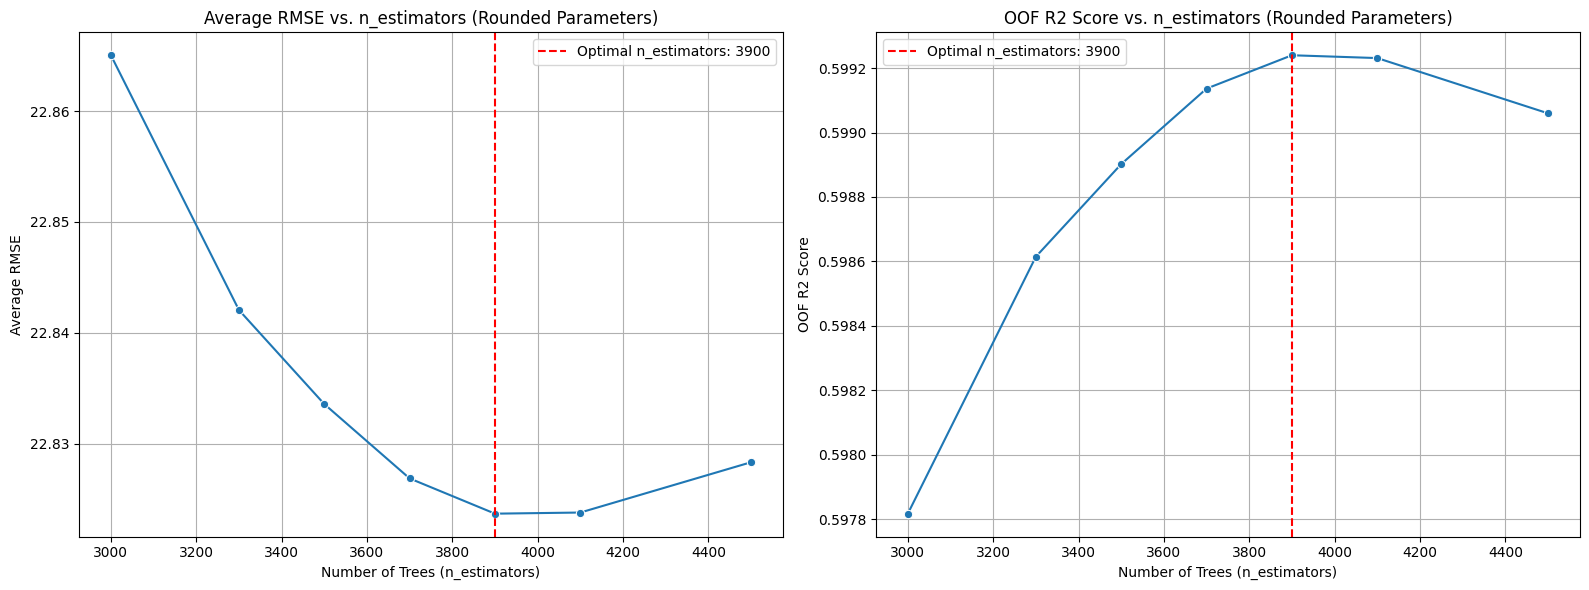


--- グリッドサーチが完了しました ---


In [4]:
import pandas as pd
import lightgbm as lgb
import pickle
import numpy as np
import os
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold

import warnings # warningsモジュールをインポート

# LightGBMからのUserWarningを無視する設定
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# === 1. 設定 (再定義) ===
# CSVファイルのパス
csv_path_nc = 'ML_data/tox24_t_mord.csv'
csv_path_c = 'ML_data/tox24_t_c_mord.csv'
# 分割情報（folds.pkl）のパス
output_pkl_path = 'ML_data/folds.pkl'
# 目的変数のカラム名
y_column = 'y'
# 識別子となるカラム名 (データ結合に使用)
identifier_columns = ["N"]

# 選択された記述子のリスト (再定義)
['c_SLogP', 'c_ATSC1i', 'c_ETA_dEpsilon_D', 'c_AETA_beta_ns_d', 'nc_VSA_EState3', 'c_ETA_dEpsilon_B', 'nc_ATSC6p', 'nc_ATSC6pe', 'nc_SlogP_VSA11', 'nc_ATSC2d',
                        'c_BCUTi-1l', 'c_BCUTd-1l', 'nc_ATSC1i', 'nc_ATSC5pe', 'nc_FilterItLogS', 'nc_PEOE_VSA6', 'c_BCUTi-1h', 'c_ETA_shape_y', 'nc_IC5', 'nc_IC2', 'c_AMID_O', 'c_ETA_dBeta',
                        'nc_ATSC7d', 'nc_JGI8', 'nc_IC1', 'nc_ATSC3d', 'nc_ATSC1pe', 'nc_ATSC4pe', 'nc_ATSC3i', 'nc_VSA_EState2', 'nc_ATSC3dv', 'nc_SdO', 'nc_ATSC4Z', 'nc_ATSC8dv',
                        'nc_ATSC4dv', 'nc_PEOE_VSA8', 'nc_ATSC6v', 'c_AATSC0i', 'nc_ATSC1p', 'c_ATSC1p', 'nc_ATSC6i', 'nc_ATSC4p', 'c_FilterItLogS', 'nc_ATSC2pe', 'nc_ATSC3pe', 'nc_EState_VSA3',
                        'c_ATS0p', 'nc_JGI4', 'c_BCUTpe-1l', 'c_Mi', 'nc_SLogP', 'nc_ATSC8pe', 'nc_JGI3', 'c_SMR_VSA3', 'nc_ATSC2i', 'nc_ATSC4i', 'nc_ATSC7dv', 'c_AETA_eta_RL', 'nc_ATSC2v',
                        'nc_SMR_VSA3', 'c_ATSC1Z', 'nc_JGI6', 'nc_ATSC5i', 'c_AATS0i', 'c_BCUTdv-1l', 'nc_ATSC5v', 'nc_SIC3', 'c_ATSC2i', 'nc_ZMIC1', 'nc_Mi', 'c_ATSC7p', 'nc_TopoPSA',
                        'nc_SsCH3', 'nc_ATSC6d', 'nc_ATSC5Z', 'nc_AATSC0i', 'nc_EState_VSA6', 'c_BCUTdv-1h', 'c_ATSC4p', 'nc_BertzCT', 'c_ATSC6p', 'nc_PEOE_VSA10', 'c_ATSC3dv', 'c_ATSC6pe',
                        'c_ATSC1d', 'c_ATSC3pe', 'c_ATSC3p', 'nc_ATSC8p', 'nc_ATSC8d', 'nc_ATSC5d', 'nc_ATSC6Z', 'c_ATSC4dv', 'c_ATSC1v', 'c_ATSC4v', 'c_AMID_N', 'nc_PEOE_VSA9', 'c_ATSC2dv',
                        'c_nAcid', 'nc_SdsCH', 'c_ATSC1pe', 'c_AETA_eta_L', 'nc_ATSC3p', 'nc_WPath', 'nc_JGI5', 'nc_SaaCH', 'c_AATSC0p', 'nc_EState_VSA5', 'nc_AATS0i', 'nc_ATSC3v', 'c_ATSC2d',
                        'nc_ATSC7pe', 'c_ATSC2Z', 'c_AETA_eta', 'c_AATSC0v', 'c_FCSP3', 'c_AETA_beta_ns', 'nc_ATSC7v', 'nc_ATSC7Z', 'c_SlogP_VSA2', 'c_ATSC4d', 'c_ETA_shape_p', 'nc_ATSC3Z',
                        'c_Mp', 'nc_ATSC2Z', 'nc_VSA_EState7', 'nc_IC3', 'nc_ATSC1d', 'c_ETA_eta_FL', 'c_ATSC4pe', 'nc_ZMIC2', 'c_TIC1', 'nc_ATSC2dv', 'nc_SMR_VSA1', 'nc_AATS0dv', 'c_ATSC8dv',
                        'nc_SIC2', 'c_CIC5', 'nc_AATSC0p', 'c_EState_VSA2', 'c_IC3', 'c_BCUTv-1l', 'c_ETA_epsilon_5', 'c_IC5', 'c_ATSC4i', 'nc_VSA_EState4', 'c_VSA_EState8', 'c_BCUTp-1l',
                        'nc_ATSC5p', 'nc_EState_VSA2', 'nc_fMF', 'c_BCUTd-1h', 'nc_EState_VSA8', 'nc_ATSC1v', 'c_TopoPSA', 'nc_ATSC2m', 'nc_SlogP_VSA10', 'nc_JGI2', 'nc_ATSC4d', 'nc_VSA_EState5',
                        'nc_AATSC0v', 'nc_VSA_EState8', 'nc_Xp-5dv', 'nc_AATSC0pe', 'nc_Xc-3dv', 'c_AETA_beta', 'c_BCUTpe-1h', 'c_ZMIC2', 'nc_ATSC5dv', 'c_AETA_eta_FL', 'c_ATSC6v',
                        'c_AATS0v', 'nc_PEOE_VSA1', 'nc_PEOE_VSA2', 'nc_AATS0p', 'nc_ATSC8Z', 'nc_ATSC3m', 'nc_ATSC4v', 'c_ATSC7pe', 'nc_ATSC2p', 'c_ATSC2m', 'nc_SMR_VSA7', 'nc_ATSC7p', 'nc_ATSC0p',
                        'c_MID_h', 'c_ATSC2v', 'c_ATSC3i', 'nc_PEOE_VSA3', 'nc_ATS8dv', 'c_EState_VSA3', 'nc_ATSC7i', 'nc_ATS4i', 'c_MID_O', 'nc_ATSC0i', 'nc_nS', 'c_AETA_dBeta',
                        'c_ATSC5p', 'c_ATSC2p', 'c_ATSC5Z', 'nc_ATSC4m', 'nc_BalabanJ', 'c_PEOE_VSA8', 'c_ATSC7i', 'c_AETA_alpha', 'nc_JGI1', 'c_IC1', 'nc_JGT10', 'nc_JGI7', 'c_ATSC7v', 'c_ATSC5pe',
                        'c_PEOE_VSA1', 'nc_SlogP_VSA2', 'c_ETA_eta_L', 'nc_ATS7dv', 'nc_NsssCH', 'nc_ATS6dv', 'nc_ATS3pe', 'c_ATSC6dv', 'nc_PEOE_VSA7', 'nc_SdssC', 'nc_SMR_VSA9',
                        'c_Mv', 'c_PEOE_VSA9', 'c_ATSC6Z', 'nc_TopoPSA(NO)', 'nc_ZMIC5', 'c_ATSC8pe', 'nc_ATSC5m', 'c_SpMAD_A', 'c_BCUTv-1h', 'nc_SIC4', 'nc_AATS0d', 'nc_ATSC1m', 'nc_ATSC1Z',
                        'nc_ATSC8i', 'nc_AATSC0Z', 'nc_SIC0', 'nc_EState_VSA4', 'nc_EState_VSA7', 'c_AETA_beta_s', 'c_SlogP_VSA10', 'c_ETA_epsilon_4', 'c_AMID_C', 'nc_AATS0v', 'nc_ATSC1dv',
                        'c_ETA_eta', 'nc_piPC8', 'nc_ATSC0Z', 'c_ATSC3Z', 'c_ATSC6i', 'c_ATSC4Z', 'c_PEOE_VSA3', 'nc_nHBAcc', 'nc_CIC5', 'nc_JGI9', 'c_VSA_EState3', 'c_ATSC8p', 'nc_VSA_EState9',
                        'c_ETA_dEpsilon_A', 'c_ETA_psi_1', 'nc_Xp-7dv', 'nc_Xc-3d', 'nc_TopoShapeIndex', 'nc_MIC0', 'nc_ATS7i', 'c_AATS0d', 'nc_ZMIC4', 'c_ATSC8m', 'nc_CIC2', 'c_ATSC0p',
                        'c_ATSC3m', 'c_PEOE_VSA2', 'c_SM1_DzZ', 'nc_SMR_VSA6', 'nc_ATSC8v', 'nc_ATSC7m', 'nc_SIC1', 'c_SsOH', 'c_SpMax_A', 'nc_ATS5m', 'c_ATSC5v', 'c_ATSC5i', 'c_AMID_h', 'c_nBase',
                        'c_AATS0Z', 'c_BCUTZ-1h', 'c_ATSC3v', 'nc_LabuteASA', 'nc_SssNH', 'c_ATSC3d', 'c_ETA_epsilon_2', 'c_CIC2', 'nc_CIC0', 'nc_piPC2', 'nc_MIC4', 'nc_EState_VSA1',
                        'c_ETA_beta_ns_d', 'nc_EState_VSA9', 'nc_SsssCH', 'nc_SlogP_VSA3', 'c_ATSC5d', 'c_Xp-5dv', 'nc_GGI6', 'c_SpAbs_Dzp', 'nc_ATS3i', 'nc_Mp', 'c_ATSC2pe', 'c_ATS3p', 'c_C1SP3',
                        'nc_Xp-6dv', 'nc_AATSC0dv', 'nc_AATSC0d', 'nc_GGI5', 'c_ATSC7d', 'c_ATSC8d', 'c_PEOE_VSA6', 'c_SdO', 'c_SsCH3', 'c_SdsCH', 'c_SpMAD_DzZ', 'nc_FCSP3', 'nc_TIC1',
                        'nc_ATSC6dv', 'nc_TIC3', 'nc_TIC0', 'c_VR2_A', 'nc_ATSC0v', 'nc_ATSC8m', 'c_BCUTZ-1l', 'c_ATS3m', 'nc_SIC5', 'nc_ATS8i', 'nc_ATS6i', 'nc_Xpc-5d', 'nc_ATS4Z', 'c_AATS0p',
                        'nc_ATS0Z', 'nc_ATS3d', 'c_ETA_eta_F', 'c_AETA_eta_F', 'c_ATSC0Z', 'c_ATSC7m', 'nc_SlogP_VSA5', 'nc_nAcid', 'nc_Xch-5dv', 'c_AMID', 'c_SpMAD_Dzpe', 'c_NsOH',
                        'nc_Diameter', 'c_EState_VSA6', 'c_Xp-2dv', 'nc_Xp-1dv', 'c_Xp-3d', 'c_Xc-3dv', 'c_CIC4', 'c_BalabanJ', 'c_CIC0', 'c_SpMAD_Dzp', 'nc_Xpc-6dv', 'c_AATS0dv', 'nc_ATS5d',
                        'c_SMR', 'nc_bpol', 'c_ATSC1dv', 'nc_ATS0p', 'nc_ATS7d', 'c_ATS3Z', 'nc_ATS3dv', 'c_ATSC5dv', 'c_ATS0Z', 'c_ATSC6d', 'c_PEOE_VSA12', 'c_ETA_beta_ns', 'c_ETA_epsilon_1',
                        'c_PEOE_VSA10', 'c_MIC1', 'c_ATSC8Z', 'c_SdssC', 'c_ZMIC5', 'c_ZMIC4', 'nc_ATS5p', 'c_SddssS', 'nc_ATSC0dv', 'nc_CIC3', 'nc_Xp-7d', 'c_MID_N', 'nc_Xp-2dv', 'c_ATSC0i',
                        'c_IC2', 'nc_SsOH', 'nc_IC4', 'nc_CIC1', 'nc_Xp-5d', 'nc_nHBDon', 'c_MID_C', 'nc_CIC4', 'c_SpDiam_A', 'nc_MIC1', 'nc_ECIndex', 'nc_SlogP_VSA6', 'c_ATSC7Z', 'nc_VSA_EState1',
                        'c_VE1_A', 'c_ATSC4m', 'c_SpAbs_DzZ', 'nc_TSRW10', 'c_nS', 'c_AATSC0pe', 'c_ATSC7dv', 'c_ATSC8i', 'nc_GGI7', 'nc_MPC10', 'c_ATS8i', 'c_SM1_Dzp', 'c_ATS2p', 'c_ATSC0pe',
                        'nc_nRot', 'nc_piPC9', 'c_BCUTp-1h', 'c_ATSC5m', 'c_VSA_EState9', 'nc_Xch-7dv', 'nc_Xpc-5dv', 'nc_Xpc-4dv', 'c_PEOE_VSA7', 'nc_Xc-5dv', 'nc_AATS0m', 'nc_ATS1Z', 'nc_ATS2Z',
                        'nc_ATSC0m', 'nc_ATS2d', 'nc_ATS0v', 'c_TIC2', 'nc_Xch-7d', 'nc_ATS1m', 'nc_ATS6m', 'nc_AATSC0m', 'c_SMR_VSA1', 'nc_ATSC0pe', 'nc_ATS3m', 'c_MIC2', 'c_MIC3', 'nc_NssCH2',
                        'nc_ATS4p', 'c_MIC4', 'nc_fragCpx', 'nc_ATS1dv', 'nc_MZ', 'nc_ATS2dv', 'nc_TIC2', 'nc_Xp-3dv', 'nc_ATS5i', 'nc_AATS0pe', 'c_ATS5d', 'nc_n6AHRing', 'nc_ATS2i', 'c_ATS4Z',
                        'nc_ATSC6m', 'nc_ATS6pe', 'c_nRot', 'c_SpMAD_D', 'c_ATS2dv', 'c_AATSC0Z', 'c_VSA_EState2', 'c_EState_VSA5', 'nc_NdssC', 'c_EState_VSA7', 'c_SM1_Dzpe', 'nc_GGI9', 'nc_Mv',
                        'c_EState_VSA9', 'nc_Xp-4dv', 'c_BertzCT', 'nc_C1SP3', 'c_SpDiam_DzZ', 'nc_Xpc-4d', 'c_VSA_EState7', 'c_ABC', 'nc_Xch-6dv', 'c_ZMIC3', 'c_Xpc-5d', 'c_Xpc-5dv', 'nc_ATS6v',
                        'nc_ATS4pe', 'c_ZMIC1', 'nc_piPC3', 'nc_ATS4dv', 'nc_ATS5dv', 'nc_piPC7', 'nc_ATS2m', 'nc_IC0', 'c_ETA_dEpsilon_C', 'nc_ATS6d', 'nc_SaasC', 'c_fragCpx', 'c_ATS1pe', 'c_fMF',
                        'nc_ATS7Z', 'c_ATSC0dv', 'nc_ATS3Z', 'nc_ATS8m', 'nc_piPC10', 'nc_MIC3', 'c_JGI4', 'c_TSRW10', 'nc_PEOE_VSA11', 'c_ETA_epsilon_3', 'c_ATS3pe', 'c_ATSC0m', 'c_ETA_alpha',
                        'c_ATSC8v', 'c_MIC5', 'c_ETA_beta', 'nc_SssCH2', 'nc_MIC5', 'c_IC0', 'c_ATS8pe', 'c_ATSC0d', 'nc_nHetero', 'nc_Xp-3d', 'nc_ATS8d', 'nc_MWC06', 'nc_JGI10', 'nc_WPol', 'nc_SRW10',
                        'nc_Xc-6dv', 'c_SpDiam_Dzpe', 'nc_Sv', 'c_VSA_EState1', 'c_ATS3i', 'c_AATS0pe', 'nc_ABCGG', 'nc_ATS4v', 'nc_ATS8v', 'c_ATS3v', 'nc_GGI2', 'c_ATS2m', 'nc_ATS3p',
                        'c_ATS7pe', 'c_ATS3d', 'c_TopoPSA(NO)', 'nc_ATSC0d', 'c_ATS1p', 'c_ATS4dv', 'nc_ATS4m', 'nc_mZagreb2', 'c_AATSC0dv', 'c_AATSC0m', 'c_ATS2i', 'nc_nBondsD', 'c_VR1_A', 'nc_C2SP3',
                        'c_LogEE_A', 'nc_C3SP3', 'c_ATS7i', 'nc_ATS8Z', 'nc_ATS5Z', 'c_ABCGG', 'nc_GGI3', 'nc_SlogP_VSA1', 'nc_NddsN', 'nc_EState_VSA10', 'nc_nHRing', 'c_ETA_shape_x',
                        'c_CIC3', 'c_CIC1', 'c_TIC5', 'nc_piPC6', 'c_Xp-1d', 'nc_piPC4', 'nc_SssO', 'c_SM1_Dzi', 'c_SaaCH', 'c_IC4', 'c_LabuteASA', 'nc_SddssS', 'nc_MPC7', 'c_SMR_VSA7', 'c_Sm', 'c_Xp-6dv',
                        'nc_VMcGowan', 'nc_ZMIC3', 'c_Xp-3dv', 'nc_MIC2', 'c_EState_VSA4', 'c_Xp-7dv', 'c_ATS4v', 'c_NsCH3', 'c_VMcGowan', 'nc_AATS0Z', 'c_nFHRing', 'c_NdsCH',
                        'nc_ATS0pe', 'c_SaasC', 'c_SssO', 'c_ATS1v', 'c_ATS2Z', 'c_ATS0v', 'nc_ATS8p', 'c_nHRing', 'c_SsssCH', 'nc_ATS8pe', 'c_bpol', 'c_NaasC', 'c_ZMIC0', 'nc_ATS2p', 'c_piPC3', 'nc_ATS6p',
                        'c_TpiPC10', 'c_ATS1Z', 'c_ATS5Z', 'nc_naHRing', 'nc_GGI1', 'c_ECIndex', 'nc_ATS0dv', 'nc_ATS4d', 'nc_SsCl', 'nc_ATS1d', 'nc_TIC4', 'nc_TIC5', 'c_ATSC6m',
                        'nc_nX', 'c_nHBAcc', 'c_GGI2', 'c_JGI1', 'c_JGI2', 'nc_ZMIC0', 'c_MWC03', 'c_ETA_dAlpha_A', 'nc_VSA_EState6', 'c_AETA_eta_R', 'nc_ATS2v', 'c_ATS1i', 'c_ATS6pe', 'c_MIC0', 'c_Sp',
                        'nc_ATS7m', 'c_ATS7p', 'nc_piPC5', 'nc_SaaN', 'nc_MPC4', 'nc_SsssN', 'c_ATSC0v', 'c_ATS6i', 'nc_ATS0m', 'nc_MPC9', 'nc_ATS6Z', 'nc_SsNH2', 'c_ATS7d', 'nc_MWC05',
                        'c_SpDiam_Dzi', 'nc_MWC07', 'nc_Xch-6d', 'c_Xpc-4dv', 'c_BCUTm-1l', 'c_SlogP_VSA5', 'nc_Mm', 'nc_NssssC', 'nc_Sp', 'c_SlogP_VSA4', 'nc_Xc-5d', 'nc_Sm', 'c_VE3_Dzv', 'c_VE2_A',
                        'c_SlogP_VSA1', 'c_SM1_Dzv', 'c_ATS6dv', 'nc_Xpc-6d', 'c_SpMAD_Dzv', 'c_SlogP_VSA3', 'c_VSA_EState5', 'nc_Xp-6d', 'nc_MWC10', 'c_SpMax_Dzv', 'nc_SMR_VSA5', 'c_Xp-2d',
                        'c_SpAbs_Dzv', 'c_VE3_A', 'c_VR2_Dzpe', 'c_Xp-6d', 'c_SMR_VSA6', 'nc_NaasC', 'c_Xp-4dv', 'nc_NsCH3', 'c_AATSC0d', 'c_MID_X', 'c_ATS0dv', 'nc_C1SP2', 'nc_C2SP2', 'nc_GGI10',
                        'c_EState_VSA8', 'c_ATS3dv', 'c_EState_VSA1', 'nc_nBondsS', 'c_SRW04', 'c_SpAD_Dzv', 'c_ETA_eta_R', 'c_SpDiam_Dzv', 'c_SRW08', 'c_TMWC10', 'c_SpAbs_Dzi', 'c_MWC09', 'c_MWC08',
                        'c_SpMAD_Dzi', 'c_MWC04', 'c_VR2_Dzp', 'c_VR1_Dzv', 'c_EState_VSA10', 'c_Diameter', 'c_JGT10', 'c_SpAD_Dzp', 'c_GGI5', 'c_GGI7', 'c_GGI4', 'c_Spe', 'c_VE2_DzZ', 'c_PEOE_VSA5',
                        'c_nFRing', 'c_Xp-4d', 'c_nRing', 'c_AMID_X', 'c_MPC3', 'c_PEOE_VSA4', 'c_MPC4', 'c_MPC5', 'c_BCUTm-1h', 'c_piPC2', 'c_Xp-7d', 'c_piPC5', 'c_Xp-1dv', 'c_PEOE_VSA13',
                        'c_PEOE_VSA11', 'c_Mpe', 'c_Xpc-6dv', 'c_SsssN', 'c_TIC3', 'c_VSA_EState6', 'c_VR1_Dzi', 'c_nBondsS', 'c_nBondsD', 'c_C2SP3', 'c_C3SP3', 'c_Xch-5d', 'c_Xch-6d', 'c_Xch-7d',
                        'c_SddsN', 'c_ETA_beta_s', 'c_Xch-5dv', 'c_Xch-6dv', 'c_Xch-7dv', 'c_Xc-3d', 'c_Xc-5d', 'c_Xc-6dv', 'c_TIC4', 'nc_ABC', 'c_mZagreb2', 'c_nO', 'nc_n6ARing', 'nc_GGI8',
                        'nc_ATS2pe', 'nc_MWC02', 'nc_MWC08', 'nc_SssssC', 'nc_ATS7v', 'nc_SddsN', 'nc_ATS0d', 'nc_nO', 'nc_nN', 'nc_SRW08', 'nc_MW', 'c_SpAbs_A', 'c_nAtom', 'nc_GhoseFilter', 'c_nH',
                        'nc_GGI4', 'nc_SMR', 'nc_NssS', 'nc_nBondsM', 'nc_Xp-2d', 'nc_Xc-6d', 'nc_Xp-4d', 'nc_Spe', 'nc_C3SP2', 'nc_NdsCH', 'nc_nBondsKS', 'nc_nFHRing', 'nc_ATS5pe', 'nc_n10FRing',
                        'nc_NsNH2', 'nc_ATS1i', 'nc_ATS0i', 'nc_ATS7p', 'nc_ATS1p', 'nc_NsOH', 'nc_PEOE_VSA5', 'nc_Xp-1d', 'nc_MPC8', 'nc_PEOE_VSA13', 'c_ATS0m', 'nc_MPC5', 'c_ATS8m', 'c_ATS1m',
                        'nc_SlogP_VSA4', 'c_ATS4p', 'c_ATS5p', 'c_ATS0d', 'c_ATS5v', 'c_ATS6p', 'nc_nBase', 'c_ATS5m', 'c_ATS6m', 'c_ATS7dv', 'c_ATS6v', 'nc_TMPC10', 'c_ATS5dv', 'c_ATS0i', 'c_ATS1dv',
                        'c_nX', 'c_ATS4i', 'c_ATS5i', 'c_ATS2pe']


# === 2. データ読み込みと結合 (再定義) ===
print("--- データ読み込みと結合処理を開始 ---")
try:
    df_nc = pd.read_csv(csv_path_nc)
    df_c = pd.read_csv(csv_path_c)
except FileNotFoundError as e:
    print(f"エラー: 指定されたCSVファイルが見つかりません: {e.filename}")
    exit()

if "SMILES" not in df_nc.columns or "SMILES" not in df_c.columns:
    print("エラー: 'SMILES' カラムが両方のCSVファイルに存在しません。")
    exit()

nc_cols_to_prefix = [col for col in df_nc.columns if col not in identifier_columns + [y_column, "SMILES"]]
df_nc_features_prefixed = df_nc[nc_cols_to_prefix].rename(columns={col: f'nc_{col}' for col in nc_cols_to_prefix})
df_nc_processed = pd.concat([df_nc[identifier_columns + [y_column, "SMILES"]], df_nc_features_prefixed], axis=1)

c_cols_to_prefix = [col for col in df_c.columns if col not in identifier_columns + ["SMILES"]]
df_c_features_prefixed = df_c[c_cols_to_prefix].rename(columns={col: f'c_{col}' for col in c_cols_to_prefix})
df_c_processed = pd.concat([df_c[identifier_columns + ["SMILES"]], df_c_features_prefixed], axis=1)

df_combined = pd.merge(df_nc_processed, df_c_processed, on=identifier_columns, how='inner', suffixes=('_nc', '_c'))

if 'SMILES_c' in df_combined.columns and 'SMILES_nc' in df_combined.columns:
    df_combined.drop(columns=['SMILES_c'], inplace=True)
    df_combined.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
elif 'SMILES_c' in df_combined.columns:
    df_combined.rename(columns={'SMILES_c': 'SMILES'}, inplace=True)
elif 'SMILES_nc' in df_combined.columns:
    df_combined.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)

if len(df_combined) == 0:
    print("エラー: 結合後のデータフレームが空です。処理を中止します。")
    exit()
print(f"結合後のデータフレーム形状: {df_combined.shape}")

# === 3. 特徴量と目的変数の分離と最小限の前処理 (再定義) ===
print("--- 特徴量と目的変数の分離と最小限の前処理を開始 ---")

X = df_combined[SELECTED_DESCRIPTORS].copy()
y = df_combined[y_column]

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

if X.empty or X.shape[1] == 0:
    print("エラー: 全ての前処理後、特徴量が残っていません。モデル構築を中止します。")
    exit()
print(f"前処理後の特徴量Xの最終形状: {X.shape}, 目的変数yの形状: {y.shape}")

# === フォールド情報のロード (再定義) ===
try:
    with open(output_pkl_path, 'rb') as f:
        fold_dict = pickle.load(f)
except FileNotFoundError:
    print(f"エラー: ファイル '{output_pkl_path}' が見つかりません。'folds.pkl'が正しいディレクトリにあり、パスが正確であることを確認してください。")
    exit()
except Exception as e:
    print(f"エラー: '{output_pkl_path}' から fold_dict をロードできませんでした: {e}")
    exit()

df_indices = X.index.tolist() # Xのインデックスリストを取得
fold_assignments = {}
for idx in df_indices:
    if idx in fold_dict:
        fold_assignments[idx] = fold_dict[idx]['fold']
    else:
        print(f"警告: インデックス {idx} が fold_dict に見つかりません。このサンプルはフォールド割り当てからスキップされます。")
        pass

n_splits_from_pkl = fold_dict[list(fold_dict.keys())[0]]['N'] if fold_dict and list(fold_dict.keys()) else 5

# splitsリストを生成 (グリッドサーチとCVで再利用)
splits = []
for fold in range(n_splits_from_pkl):
    train_original_indices = [idx for idx, assignment in fold_assignments.items() if assignment != fold and idx in X.index]
    test_original_indices = [idx for idx, assignment in fold_assignments.items() if assignment == fold and idx in X.index]

    train_idx_loc = X.index.get_indexer(train_original_indices)
    test_idx_loc = X.index.get_indexer(test_original_indices)

    train_idx_loc = train_idx_loc[train_idx_loc != -1]
    test_idx_loc = test_idx_loc[test_idx_loc != -1]

    if len(train_idx_loc) > 0 and len(test_idx_loc) > 0:
        splits.append((train_idx_loc, test_idx_loc))
    else:
        print(f"警告: フォールド {fold} はインデックスフィルタリング後に訓練またはテストセットが空です。スキップします。")

if not splits:
    print("エラー: 有効なクロスバリデーションの分割がありません。グリッドサーチを中止します。")
    exit()


# === 最適なn_estimatorsを見つけるためのグリッドサーチを開始 ===
print("\n--- 最適なn_estimatorsを見つけるためのグリッドサーチを開始 ---")
print("--- Optunaで得られた最適なパラメータを小数点以下3桁に丸めて適用します ---")

# Optunaで得られたベストパラメータを直接記述し、小数点以下3桁に丸める
# learning_rate: 0.0017321400204219739 -> 0.002 (0より大きくする必要があるため、有効数字を考慮)
# num_leaves: 153 (整数)
# min_data_in_leaf: 12 (整数)
# min_sum_hessian_in_leaf: 8.105042061084768 -> 13.163
# bagging_fraction: 0.5862161537727023 -> 0.798
# feature_fraction: 0.7620443296468749 -> 0.956
# lambda_l1: 1.2426179884902169 -> 0.048
# lambda_l2: 1.0975121024859582 -> 0.048
    
base_lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'max_depth': -1,
    'bagging_freq': 1,
    'verbose': -1, # 学習中のログを非表示にする
    'n_jobs': -1,
    'seed': 42,
    # 丸められたパラメータを直接記入
    'learning_rate': 0.0017,
    'num_leaves': 153,
    'min_data_in_leaf': 12,
    'min_sum_hessian_in_leaf': 8.1,
    'bagging_fraction': 0.59,
    'feature_fraction': 0.76,
    'lambda_l1': 1.2,
    'lambda_l2': 1.1,
}

print("\n--- 丸められたベースパラメータ (小数点以下3桁) ---")
for key, value in base_lgb_params.items():
    print(f"  {key}: {value}")
print("--------------------------------------------------")


# 探索する木の数（n_estimators）の範囲を定義
# 平均が3446だったので、その前後で具体的な値を設定
n_estimators_grid = [
    3000,  3300, 3500, 3700, 3900, 4100, 4500
]

grid_search_results = []

for n_est in tqdm(n_estimators_grid, desc="Grid Search for n_estimators"):
    current_lgb_params = base_lgb_params.copy()
    current_lgb_params['n_estimators'] = n_est # ここで木の数を設定
    
    fold_rmses = []
    oof_preds = np.zeros(len(X))
    oof_truths = np.zeros(len(X))

    for fold_idx, (train_index, test_index) in enumerate(splits):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if X_train.empty or X_test.empty or X_train.shape[1] == 0:
            continue

        model = lgb.LGBMRegressor(**current_lgb_params)
        
        # グリッドサーチでは early stopping を使用しない (n_estimatorsを固定値で評価するため)
        # eval_setとeval_metricを削除することで、学習中のRMSE出力も抑制
        model.fit(X_train, y_train) # 修正箇所
        
        predictions = model.predict(X_test)
        oof_preds[test_index] = predictions
        oof_truths[test_index] = y_test.values

        rmse = np.sqrt(np.mean((predictions - y_test)**2))
        fold_rmses.append(rmse)

    if fold_rmses:
        avg_rmse = np.mean(fold_rmses)
        
        # OOF予測全体のR2スコアを計算
        valid_oof_indices = ~np.isclose(oof_truths, 0.0) & ~np.isnan(oof_preds)
        if np.sum(valid_oof_indices) > 0:
            overall_oof_r2 = r2_score(oof_truths[valid_oof_indices], oof_preds[valid_oof_indices])
        else:
            overall_oof_r2 = -np.inf # 有効なデータがない場合

        grid_search_results.append({
            'n_estimators': n_est,
            'avg_rmse': avg_rmse,
            'overall_oof_r2': overall_oof_r2
        })
        print(f"n_estimators: {n_est} -> 平均RMSE: {avg_rmse:.4f}, OOF R2: {overall_oof_r2:.4f}")
    else:
        print(f"n_estimators: {n_est} -> 評価できませんでした。")


# 結果の表示
print("\n--- グリッドサーチ結果の概要 ---")
results_df = pd.DataFrame(grid_search_results).sort_values(by='avg_rmse')
print(results_df)

best_grid_n_estimators = results_df.iloc[0]['n_estimators']
best_grid_rmse = results_df.iloc[0]['avg_rmse']
best_grid_r2 = results_df.iloc[0]['overall_oof_r2']

print(f"\nグリッドサーチで最適なn_estimators: {best_grid_n_estimators} (平均RMSE: {best_grid_rmse:.4f}, OOF R2: {best_grid_r2:.4f})")


# 結果の可視化
print("\n--- グリッドサーチ結果のプロット ---")

if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # RMSEのプロット
    sns.lineplot(x='n_estimators', y='avg_rmse', data=results_df, marker='o', ax=axes[0])
    axes[0].set_title('Average RMSE vs. n_estimators (Rounded Parameters)')
    axes[0].set_xlabel('Number of Trees (n_estimators)')
    axes[0].set_ylabel('Average RMSE')
    axes[0].grid(True)
    axes[0].axvline(x=best_grid_n_estimators, color='r', linestyle='--', label=f'Optimal n_estimators: {int(best_grid_n_estimators)}')
    axes[0].legend()

    # R2スコアのプロット
    sns.lineplot(x='n_estimators', y='overall_oof_r2', data=results_df, marker='o', ax=axes[1])
    axes[1].set_title('OOF R2 Score vs. n_estimators (Rounded Parameters)')
    axes[1].set_xlabel('Number of Trees (n_estimators)')
    axes[1].set_ylabel('OOF R2 Score')
    axes[1].grid(True)
    axes[1].axvline(x=best_grid_n_estimators, color='r', linestyle='--', label=f'Optimal n_estimators: {int(best_grid_n_estimators)}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("プロットするグリッドサーチ結果がありません。")

print("\n--- グリッドサーチが完了しました ---")

In [1]:
import pandas as pd
import lightgbm as lgb
import numpy as np
import os
import pickle # モデル保存のためにインポート
from sklearn.metrics import r2_score, mean_squared_error
import warnings

# LightGBMからのUserWarningを無視する設定
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# --- 設定 ---
# 学習用CSVファイルのパス
csv_path_nc = 'ML_data/tox24_t_mord.csv'
csv_path_c = 'ML_data/tox24_t_c_mord.csv'
# 目的変数のカラム名
y_column = 'y'
# 識別子となるカラム名 (データ結合に使用)
identifier_columns = ["N"]
# 学習済みモデルの保存パス
model_save_path = 'trained_lgbm_model_for_prediction.pkl' # 保存ファイル名

# 選択された記述子のリスト
SELECTED_DESCRIPTORS = ['c_SLogP', 'c_ATSC1i', 'c_ETA_dEpsilon_D', 'c_AETA_beta_ns_d', 'nc_VSA_EState3', 'c_ETA_dEpsilon_B', 'nc_ATSC6p', 'nc_ATSC6pe', 'nc_SlogP_VSA11', 'nc_ATSC2d',
                        'c_BCUTi-1l', 'c_BCUTd-1l', 'nc_ATSC1i', 'nc_ATSC5pe', 'nc_FilterItLogS', 'nc_PEOE_VSA6', 'c_BCUTi-1h', 'c_ETA_shape_y', 'nc_IC5', 'nc_IC2', 'c_AMID_O', 'c_ETA_dBeta',
                        'nc_ATSC7d', 'nc_JGI8', 'nc_IC1', 'nc_ATSC3d', 'nc_ATSC1pe', 'nc_ATSC4pe', 'nc_ATSC3i', 'nc_VSA_EState2', 'nc_ATSC3dv', 'nc_SdO', 'nc_ATSC4Z', 'nc_ATSC8dv',
                        'nc_ATSC4dv', 'nc_PEOE_VSA8', 'nc_ATSC6v', 'c_AATSC0i', 'nc_ATSC1p', 'c_ATSC1p', 'nc_ATSC6i', 'nc_ATSC4p', 'c_FilterItLogS', 'nc_ATSC2pe', 'nc_ATSC3pe', 'nc_EState_VSA3',
                        'c_ATS0p', 'nc_JGI4', 'c_BCUTpe-1l', 'c_Mi', 'nc_SLogP', 'nc_ATSC8pe', 'nc_JGI3', 'c_SMR_VSA3', 'nc_ATSC2i', 'nc_ATSC4i', 'nc_ATSC7dv', 'c_AETA_eta_RL', 'nc_ATSC2v',
                        'nc_SMR_VSA3', 'c_ATSC1Z', 'nc_JGI6', 'nc_ATSC5i', 'c_AATS0i', 'c_BCUTdv-1l', 'nc_ATSC5v', 'nc_SIC3', 'c_ATSC2i', 'nc_ZMIC1', 'nc_Mi', 'c_ATSC7p', 'nc_TopoPSA',
                        'nc_SsCH3', 'nc_ATSC6d', 'nc_ATSC5Z', 'nc_AATSC0i', 'nc_EState_VSA6', 'c_BCUTdv-1h', 'c_ATSC4p', 'nc_BertzCT', 'c_ATSC6p', 'nc_PEOE_VSA10', 'c_ATSC3dv', 'c_ATSC6pe',
                        'c_ATSC1d', 'c_ATSC3pe', 'c_ATSC3p', 'nc_ATSC8p', 'nc_ATSC8d', 'nc_ATSC5d', 'nc_ATSC6Z', 'c_ATSC4dv', 'c_ATSC1v', 'c_ATSC4v', 'c_AMID_N', 'nc_PEOE_VSA9', 'c_ATSC2dv',
                        'c_nAcid', 'nc_SdsCH', 'c_ATSC1pe', 'c_AETA_eta_L', 'nc_ATSC3p', 'nc_WPath', 'nc_JGI5', 'nc_SaaCH', 'c_AATSC0p', 'nc_EState_VSA5', 'nc_AATS0i', 'nc_ATSC3v', 'c_ATSC2d',
                        'nc_ATSC7pe', 'c_ATSC2Z', 'c_AETA_eta', 'c_AATSC0v', 'c_FCSP3', 'c_AETA_beta_ns', 'nc_ATSC7v', 'nc_ATSC7Z', 'c_SlogP_VSA2', 'c_ATSC4d', 'c_ETA_shape_p', 'nc_ATSC3Z',
                        'c_Mp', 'nc_ATSC2Z', 'nc_VSA_EState7', 'nc_IC3', 'nc_ATSC1d', 'c_ETA_eta_FL', 'c_ATSC4pe', 'nc_ZMIC2', 'c_TIC1', 'nc_ATSC2dv', 'nc_SMR_VSA1', 'nc_AATS0dv', 'c_ATSC8dv',
                        'nc_SIC2', 'c_CIC5', 'nc_AATSC0p', 'c_EState_VSA2', 'c_IC3', 'c_BCUTv-1l', 'c_ETA_epsilon_5', 'c_IC5', 'c_ATSC4i', 'nc_VSA_EState4', 'c_VSA_EState8', 'c_BCUTp-1l',
                        'nc_ATSC5p', 'nc_EState_VSA2', 'nc_fMF', 'c_BCUTd-1h', 'nc_EState_VSA8', 'nc_ATSC1v', 'c_TopoPSA', 'nc_ATSC2m', 'nc_SlogP_VSA10', 'nc_JGI2', 'nc_ATSC4d', 'nc_VSA_EState5',
                        'nc_AATSC0v', 'nc_VSA_EState8', 'nc_Xp-5dv', 'nc_AATSC0pe', 'nc_Xc-3dv', 'c_AETA_beta', 'c_BCUTpe-1h', 'c_ZMIC2', 'nc_ATSC5dv', 'c_AETA_eta_FL', 'c_ATSC6v',
                        'c_AATS0v', 'nc_PEOE_VSA1', 'nc_PEOE_VSA2', 'nc_AATS0p', 'nc_ATSC8Z', 'nc_ATSC3m', 'nc_ATSC4v', 'c_ATSC7pe', 'nc_ATSC2p', 'c_ATSC2m', 'nc_SMR_VSA7', 'nc_ATSC7p', 'nc_ATSC0p',
                        'c_MID_h', 'c_ATSC2v', 'c_ATSC3i', 'nc_PEOE_VSA3', 'nc_ATS8dv', 'c_EState_VSA3', 'nc_ATSC7i', 'nc_ATS4i', 'c_MID_O', 'nc_ATSC0i', 'nc_nS', 'c_AETA_dBeta',
                        'c_ATSC5p', 'c_ATSC2p', 'c_ATSC5Z', 'nc_ATSC4m', 'nc_BalabanJ', 'c_PEOE_VSA8', 'c_ATSC7i', 'c_AETA_alpha', 'nc_JGI1', 'c_IC1', 'nc_JGT10', 'nc_JGI7', 'c_ATSC7v', 'c_ATSC5pe',
                        'c_PEOE_VSA1', 'nc_SlogP_VSA2', 'c_ETA_eta_L', 'nc_ATS7dv', 'nc_NsssCH', 'nc_ATS6dv', 'nc_ATS3pe', 'c_ATSC6dv', 'nc_PEOE_VSA7', 'nc_SdssC', 'nc_SMR_VSA9',
                        'c_Mv', 'c_PEOE_VSA9', 'c_ATSC6Z', 'nc_TopoPSA(NO)', 'nc_ZMIC5', 'c_ATSC8pe', 'nc_ATSC5m', 'c_SpMAD_A', 'c_BCUTv-1h', 'nc_SIC4', 'nc_AATS0d', 'nc_ATSC1m', 'nc_ATSC1Z',
                        'nc_ATSC8i', 'nc_AATSC0Z', 'nc_SIC0', 'nc_EState_VSA4', 'nc_EState_VSA7', 'c_AETA_beta_s', 'c_SlogP_VSA10', 'c_ETA_epsilon_4', 'c_AMID_C', 'nc_AATS0v', 'nc_ATSC1dv',
                        'c_ETA_eta', 'nc_piPC8', 'nc_ATSC0Z', 'c_ATSC3Z', 'c_ATSC6i', 'c_ATSC4Z', 'c_PEOE_VSA3', 'nc_nHBAcc', 'nc_CIC5', 'nc_JGI9', 'c_VSA_EState3', 'c_ATSC8p', 'nc_VSA_EState9',
                        'c_ETA_dEpsilon_A', 'c_ETA_psi_1', 'nc_Xp-7dv', 'nc_Xc-3d', 'nc_TopoShapeIndex', 'nc_MIC0', 'nc_ATS7i', 'c_AATS0d', 'nc_ZMIC4', 'c_ATSC8m', 'nc_CIC2', 'c_ATSC0p',
                        'c_ATSC3m', 'c_PEOE_VSA2', 'c_SM1_DzZ', 'nc_SMR_VSA6', 'nc_ATSC8v', 'nc_ATSC7m', 'nc_SIC1', 'c_SsOH', 'c_SpMax_A', 'nc_ATS5m', 'c_ATSC5v', 'c_ATSC5i', 'c_AMID_h', 'c_nBase',
                        'c_AATS0Z', 'c_BCUTZ-1h', 'c_ATSC3v', 'nc_LabuteASA', 'nc_SssNH', 'c_ATSC3d', 'c_ETA_epsilon_2', 'c_CIC2', 'nc_CIC0', 'nc_piPC2', 'nc_MIC4', 'nc_EState_VSA1',
                        'c_ETA_beta_ns_d', 'nc_EState_VSA9', 'nc_SsssCH', 'nc_SlogP_VSA3', 'c_ATSC5d', 'c_Xp-5dv', 'nc_GGI6', 'c_SpAbs_Dzp', 'nc_ATS3i', 'nc_Mp', 'c_ATSC2pe', 'c_ATS3p', 'c_C1SP3',
                        'nc_Xp-6dv', 'nc_AATSC0dv', 'nc_AATSC0d', 'nc_GGI5', 'c_ATSC7d', 'c_ATSC8d', 'c_PEOE_VSA6', 'c_SdO', 'c_SsCH3', 'c_SdsCH', 'c_SpMAD_DzZ', 'nc_FCSP3', 'nc_TIC1',
                        'nc_ATSC6dv', 'nc_TIC3', 'nc_TIC0', 'c_VR2_A', 'nc_ATSC0v', 'nc_ATSC8m', 'c_BCUTZ-1l', 'c_ATS3m', 'nc_SIC5', 'nc_ATS8i', 'nc_ATS6i', 'nc_Xpc-5d', 'nc_ATS4Z', 'c_AATS0p',
                        'nc_ATS0Z', 'nc_ATS3d', 'c_ETA_eta_F', 'c_AETA_eta_F', 'c_ATSC0Z', 'c_ATSC7m', 'nc_SlogP_VSA5', 'nc_nAcid', 'nc_Xch-5dv', 'c_AMID', 'c_SpMAD_Dzpe', 'c_NsOH',
                        'nc_Diameter', 'c_EState_VSA6', 'c_Xp-2dv', 'nc_Xp-1dv', 'c_Xp-3d', 'c_Xc-3dv', 'c_CIC4', 'c_BalabanJ', 'c_CIC0', 'c_SpMAD_Dzp', 'nc_Xpc-6dv', 'c_AATS0dv', 'nc_ATS5d',
                        'c_SMR', 'nc_bpol', 'c_ATSC1dv', 'nc_ATS0p', 'nc_ATS7d', 'c_ATS3Z', 'nc_ATS3dv', 'c_ATSC5dv', 'c_ATS0Z', 'c_ATSC6d', 'c_PEOE_VSA12', 'c_ETA_beta_ns', 'c_ETA_epsilon_1',
                        'c_PEOE_VSA10', 'c_MIC1', 'c_ATSC8Z', 'c_SdssC', 'c_ZMIC5', 'c_ZMIC4', 'nc_ATS5p', 'c_SddssS', 'nc_ATSC0dv', 'nc_CIC3', 'nc_Xp-7d', 'c_MID_N', 'nc_Xp-2dv', 'c_ATSC0i',
                        'c_IC2', 'nc_SsOH', 'nc_IC4', 'nc_CIC1', 'nc_Xp-5d', 'nc_nHBDon', 'c_MID_C', 'nc_CIC4', 'c_SpDiam_A', 'nc_MIC1', 'nc_ECIndex', 'nc_SlogP_VSA6', 'c_ATSC7Z', 'nc_VSA_EState1',
                        'c_VE1_A', 'c_ATSC4m', 'c_SpAbs_DzZ', 'nc_TSRW10', 'c_nS', 'c_AATSC0pe', 'c_ATSC7dv', 'c_ATSC8i', 'nc_GGI7', 'nc_MPC10', 'c_ATS8i', 'c_SM1_Dzp', 'c_ATS2p', 'c_ATSC0pe',
                        'nc_nRot', 'nc_piPC9', 'c_BCUTp-1h', 'c_ATSC5m', 'c_VSA_EState9', 'nc_Xch-7dv', 'nc_Xpc-5dv', 'nc_Xpc-4dv', 'c_PEOE_VSA7', 'nc_Xc-5dv', 'nc_AATS0m', 'nc_ATS1Z', 'nc_ATS2Z',
                        'nc_ATSC0m', 'nc_ATS2d', 'nc_ATS0v', 'c_TIC2', 'nc_Xch-7d', 'nc_ATS1m', 'nc_ATS6m', 'nc_AATSC0m', 'c_SMR_VSA1', 'nc_ATSC0pe', 'nc_ATS3m', 'c_MIC2', 'c_MIC3', 'nc_NssCH2',
                        'nc_ATS4p', 'c_MIC4', 'nc_fragCpx', 'nc_ATS1dv', 'nc_MZ', 'nc_ATS2dv', 'nc_TIC2', 'nc_Xp-3dv', 'nc_ATS5i', 'nc_AATS0pe', 'c_ATS5d', 'nc_n6AHRing', 'nc_ATS2i', 'c_ATS4Z',
                        'nc_ATSC6m', 'nc_ATS6pe', 'c_nRot', 'c_SpMAD_D', 'c_ATS2dv', 'c_AATSC0Z', 'c_VSA_EState2', 'c_EState_VSA5', 'nc_NdssC', 'c_EState_VSA7', 'c_SM1_Dzpe', 'nc_GGI9', 'nc_Mv',
                        'c_EState_VSA9', 'nc_Xp-4dv', 'c_BertzCT', 'nc_C1SP3', 'c_SpDiam_DzZ', 'nc_Xpc-4d', 'c_VSA_EState7', 'c_ABC', 'nc_Xch-6dv', 'c_ZMIC3', 'c_Xpc-5d', 'c_Xpc-5dv', 'nc_ATS6v',
                        'nc_ATS4pe', 'c_ZMIC1', 'nc_piPC3', 'nc_ATS4dv', 'nc_ATS5dv', 'nc_piPC7', 'nc_ATS2m', 'nc_IC0', 'c_ETA_dEpsilon_C', 'nc_ATS6d', 'nc_SaasC', 'c_fragCpx', 'c_ATS1pe', 'c_fMF',
                        'nc_ATS7Z', 'c_ATSC0dv', 'nc_ATS3Z', 'nc_ATS8m', 'nc_piPC10', 'nc_MIC3', 'c_JGI4', 'c_TSRW10', 'nc_PEOE_VSA11', 'c_ETA_epsilon_3', 'c_ATS3pe', 'c_ATSC0m', 'c_ETA_alpha',
                        'c_ATSC8v', 'c_MIC5', 'c_ETA_beta', 'nc_SssCH2', 'nc_MIC5', 'c_IC0', 'c_ATS8pe', 'c_ATSC0d', 'nc_nHetero', 'nc_Xp-3d', 'nc_ATS8d', 'nc_MWC06', 'nc_JGI10', 'nc_WPol', 'nc_SRW10',
                        'nc_Xc-6dv', 'c_SpDiam_Dzpe', 'nc_Sv', 'c_VSA_EState1', 'c_ATS3i', 'c_AATS0pe', 'nc_ABCGG', 'nc_ATS4v', 'nc_ATS8v', 'c_ATS3v', 'nc_GGI2', 'c_ATS2m', 'nc_ATS3p',
                        'c_ATS7pe', 'c_ATS3d', 'c_TopoPSA(NO)', 'nc_ATSC0d', 'c_ATS1p', 'c_ATS4dv', 'nc_ATS4m', 'nc_mZagreb2', 'c_AATSC0dv', 'c_AATSC0m', 'c_ATS2i', 'nc_nBondsD', 'c_VR1_A', 'nc_C2SP3',
                        'c_LogEE_A', 'nc_C3SP3', 'c_ATS7i', 'nc_ATS8Z', 'nc_ATS5Z', 'c_ABCGG', 'nc_GGI3', 'nc_SlogP_VSA1', 'nc_NddsN', 'nc_EState_VSA10', 'nc_nHRing', 'c_ETA_shape_x',
                        'c_CIC3', 'c_CIC1', 'c_TIC5', 'nc_piPC6', 'c_Xp-1d', 'nc_piPC4', 'nc_SssO', 'c_SM1_Dzi', 'c_SaaCH', 'c_IC4', 'c_LabuteASA', 'nc_SddssS', 'nc_MPC7', 'c_SMR_VSA7', 'c_Sm', 'c_Xp-6dv',
                        'nc_VMcGowan', 'nc_ZMIC3', 'c_Xp-3dv', 'nc_MIC2', 'c_EState_VSA4', 'c_Xp-7dv', 'c_ATS4v', 'c_NsCH3', 'c_VMcGowan', 'nc_AATS0Z', 'c_nFHRing', 'c_NdsCH',
                        'nc_ATS0pe', 'c_SaasC', 'c_SssO', 'c_ATS1v', 'c_ATS2Z', 'c_ATS0v', 'nc_ATS8p', 'c_nHRing', 'c_SsssCH', 'nc_ATS8pe', 'c_bpol', 'c_NaasC', 'c_ZMIC0', 'nc_ATS2p', 'c_piPC3', 'nc_ATS6p',
                        'c_TpiPC10', 'c_ATS1Z', 'c_ATS5Z', 'nc_naHRing', 'nc_GGI1', 'c_ECIndex', 'nc_ATS0dv', 'nc_ATS4d', 'nc_SsCl', 'nc_ATS1d', 'nc_TIC4', 'nc_TIC5', 'c_ATSC6m',
                        'nc_nX', 'c_nHBAcc', 'c_GGI2', 'c_JGI1', 'c_JGI2', 'nc_ZMIC0', 'c_MWC03', 'c_ETA_dAlpha_A', 'nc_VSA_EState6', 'c_AETA_eta_R', 'nc_ATS2v', 'c_ATS1i', 'c_ATS6pe', 'c_MIC0', 'c_Sp',
                        'nc_ATS7m', 'c_ATS7p', 'nc_piPC5', 'nc_SaaN', 'nc_MPC4', 'nc_SsssN', 'c_ATSC0v', 'c_ATS6i', 'nc_ATS0m', 'nc_MPC9', 'nc_ATS6Z', 'nc_SsNH2', 'c_ATS7d', 'nc_MWC05',
                        'c_SpDiam_Dzi', 'nc_MWC07', 'nc_Xch-6d', 'c_Xpc-4dv', 'c_BCUTm-1l', 'c_SlogP_VSA5', 'nc_Mm', 'nc_NssssC', 'nc_Sp', 'c_SlogP_VSA4', 'nc_Xc-5d', 'nc_Sm', 'c_VE3_Dzv', 'c_VE2_A',
                        'c_SlogP_VSA1', 'c_SM1_Dzv', 'c_ATS6dv', 'nc_Xpc-6d', 'c_SpMAD_Dzv', 'c_SlogP_VSA3', 'c_VSA_EState5', 'nc_Xp-6d', 'nc_MWC10', 'c_SpMax_Dzv', 'nc_SMR_VSA5', 'c_Xp-2d',
                        'c_SpAbs_Dzv', 'c_VE3_A', 'c_VR2_Dzpe', 'c_Xp-6d', 'c_SMR_VSA6', 'nc_NaasC', 'c_Xp-4dv', 'nc_NsCH3', 'c_AATSC0d', 'c_MID_X', 'c_ATS0dv', 'nc_C1SP2', 'nc_C2SP2', 'nc_GGI10',
                        'c_EState_VSA8', 'c_ATS3dv', 'c_EState_VSA1', 'nc_nBondsS', 'c_SRW04', 'c_SpAD_Dzv', 'c_ETA_eta_R', 'c_SpDiam_Dzv', 'c_SRW08', 'c_TMWC10', 'c_SpAbs_Dzi', 'c_MWC09', 'c_MWC08',
                        'c_SpMAD_Dzi', 'c_MWC04', 'c_VR2_Dzp', 'c_VR1_Dzv', 'c_EState_VSA10', 'c_Diameter', 'c_JGT10', 'c_SpAD_Dzp', 'c_GGI5', 'c_GGI7', 'c_GGI4', 'c_Spe', 'c_VE2_DzZ', 'c_PEOE_VSA5',
                        'c_nFRing', 'c_Xp-4d', 'c_nRing', 'c_AMID_X', 'c_MPC3', 'c_PEOE_VSA4', 'c_MPC4', 'c_MPC5', 'c_BCUTm-1h', 'c_piPC2', 'c_Xp-7d', 'c_piPC5', 'c_Xp-1dv', 'c_PEOE_VSA13',
                        'c_PEOE_VSA11', 'c_Mpe', 'c_Xpc-6dv', 'c_SsssN', 'c_TIC3', 'c_VSA_EState6', 'c_VR1_Dzi', 'c_nBondsS', 'c_nBondsD', 'c_C2SP3', 'c_C3SP3', 'c_Xch-5d', 'c_Xch-6d', 'c_Xch-7d',
                        'c_SddsN', 'c_ETA_beta_s', 'c_Xch-5dv', 'c_Xch-6dv', 'c_Xch-7dv', 'c_Xc-3d', 'c_Xc-5d', 'c_Xc-6dv', 'c_TIC4', 'nc_ABC', 'c_mZagreb2', 'c_nO', 'nc_n6ARing', 'nc_GGI8',
                        'nc_ATS2pe', 'nc_MWC02', 'nc_MWC08', 'nc_SssssC', 'nc_ATS7v', 'nc_SddsN', 'nc_ATS0d', 'nc_nO', 'nc_nN', 'nc_SRW08', 'nc_MW', 'c_SpAbs_A', 'c_nAtom', 'nc_GhoseFilter', 'c_nH',
                        'nc_GGI4', 'nc_SMR', 'nc_NssS', 'nc_nBondsM', 'nc_Xp-2d', 'nc_Xc-6d', 'nc_Xp-4d', 'nc_Spe', 'nc_C3SP2', 'nc_NdsCH', 'nc_nBondsKS', 'nc_nFHRing', 'nc_ATS5pe', 'nc_n10FRing',
                        'nc_NsNH2', 'nc_ATS1i', 'nc_ATS0i', 'nc_ATS7p', 'nc_ATS1p', 'nc_NsOH', 'nc_PEOE_VSA5', 'nc_Xp-1d', 'nc_MPC8', 'nc_PEOE_VSA13', 'c_ATS0m', 'nc_MPC5', 'c_ATS8m', 'c_ATS1m',
                        'nc_SlogP_VSA4', 'c_ATS4p', 'c_ATS5p', 'c_ATS0d', 'c_ATS5v', 'c_ATS6p', 'nc_nBase', 'c_ATS5m', 'c_ATS6m', 'c_ATS7dv', 'c_ATS6v', 'nc_TMPC10', 'c_ATS5dv', 'c_ATS0i', 'c_ATS1dv',
                        'c_nX', 'c_ATS4i', 'c_ATS5i', 'c_ATS2pe']

# --- データ読み込みと結合 ---
print("--- 学習データの読み込みと結合処理を開始 ---")
try:
    df_nc = pd.read_csv(csv_path_nc)
    df_c = pd.read_csv(csv_path_c)
except FileNotFoundError as e:
    print(f"エラー: 指定されたCSVファイルが見つかりません: {e.filename}")
    exit()

if "SMILES" not in df_nc.columns or "SMILES" not in df_c.columns:
    print("エラー: 'SMILES' カラムが両方のCSVファイルに存在しません。")
    exit()

nc_cols_to_prefix = [col for col in df_nc.columns if col not in identifier_columns + [y_column, "SMILES"]]
df_nc_features_prefixed = df_nc[nc_cols_to_prefix].rename(columns={col: f'nc_{col}' for col in nc_cols_to_prefix})
df_nc_processed = pd.concat([df_nc[identifier_columns + [y_column, "SMILES"]], df_nc_features_prefixed], axis=1)

c_cols_to_prefix = [col for col in df_c.columns if col not in identifier_columns + ["SMILES"]]
df_c_features_prefixed = df_c[c_cols_to_prefix].rename(columns={col: f'c_{col}' for col in c_cols_to_prefix})
df_c_processed = pd.concat([df_c[identifier_columns + ["SMILES"]], df_c_features_prefixed], axis=1)

df_combined = pd.merge(df_nc_processed, df_c_processed, on=identifier_columns, how='inner', suffixes=('_nc', '_c'))

if 'SMILES_c' in df_combined.columns and 'SMILES_nc' in df_combined.columns:
    df_combined.drop(columns=['SMILES_c'], inplace=True)
    df_combined.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
elif 'SMILES_c' in df_combined.columns:
    df_combined.rename(columns={'SMILES_c': 'SMILES'}, inplace=True)
elif 'SMILES_nc' in df_combined.columns:
    df_combined.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)

if len(df_combined) == 0:
    print("エラー: 結合後のデータフレームが空です。処理を中止します。")
    exit()
print(f"結合後のデータフレーム形状: {df_combined.shape}")

# --- 特徴量と目的変数の分離と最小限の前処理 ---
print("--- 特徴量と目的変数の分離と最小限の前処理を開始 ---")

X = df_combined[SELECTED_DESCRIPTORS].copy()
y = df_combined[y_column]

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

if X.empty or X.shape[1] == 0:
    print("エラー: 全ての前処理後、特徴量が残っていません。モデル構築を中止します。")
    exit()
print(f"前処理後の特徴量Xの最終形状: {X.shape}, 目的変数yの形状: {y.shape}")

# --- LightGBMモデルの学習 ---
print("\n--- 全データを用いたLightGBMモデルの学習を開始 ---")

# Optunaで得られたベストパラメータを直接記述し、小数点以下3桁に丸める
# learning_rate: 0.0016871993148415444 -> 0.002 (0より大きくする必要があるため、有効数字を考慮)
# num_leaves: 143 (整数)
# min_data_in_leaf: 5 (整数)
# min_sum_hessian_in_leaf: 13.16256694979102 -> 13.163
# bagging_fraction: 0.7983576751583399 -> 0.798
# feature_fraction: 0.9559689900841752 -> 0.956
# lambda_l1: 0.04808514145592948 -> 0.048
# lambda_l2: 0.0478270794724292 -> 0.048

base_lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'max_depth': -1,
    'bagging_freq': 1,
    'verbose': -1, # 学習中のログを非表示にする
    'n_jobs': -1,
    'seed': 42,
    # 丸められたパラメータを直接記入
    'learning_rate': 0.0017,
    'num_leaves': 153,
    'min_data_in_leaf': 12,
    'min_sum_hessian_in_leaf': 8.1,
    'bagging_fraction': 0.59,
    'feature_fraction': 0.76,
    'lambda_l1': 1.2,
    'lambda_l2': 1.1,
    'n_estimators': 3900 # 指定された木の数
}

print("\n--- 使用するパラメータ ---")
for key, value in base_lgb_params.items():
    print(f"  {key}: {value}")
print("----------------------------")

# モデルの初期化と学習
model = lgb.LGBMRegressor(**base_lgb_params)

print("\nモデル学習中...")
# 全データX, yを用いて学習（検証セットはなし）
model.fit(X, y)
print("モデル学習が完了しました。")

# --- 学習済みモデルの評価 ---
print("\n--- 学習済みモデルによる学習データ評価 ---")

# 全データに対する予測
predictions = model.predict(X)

# R2スコアの計算
r2 = r2_score(y, predictions)
print(f"学習データに対するR2スコア: {r2:.4f}")

# RMSEの計算
rmse = np.sqrt(mean_squared_error(y, predictions))
print(f"学習データに対するRMSE: {rmse:.4f}")

# --- 学習済みモデルの保存 ---
try:
    with open(model_save_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"\n学習済みモデルを '{model_save_path}' に保存しました。")
except Exception as e:
    print(f"\nエラー: モデルの保存に失敗しました: {e}")

print("\n--- モデル作成と保存の処理が完了しました ---")

--- 学習データの読み込みと結合処理を開始 ---
結合後のデータフレーム形状: (1211, 3230)
--- 特徴量と目的変数の分離と最小限の前処理を開始 ---
前処理後の特徴量Xの最終形状: (1211, 820), 目的変数yの形状: (1211,)

--- 全データを用いたLightGBMモデルの学習を開始 ---

--- 使用するパラメータ ---
  objective: regression
  metric: rmse
  boosting_type: gbdt
  max_depth: -1
  bagging_freq: 1
  verbose: -1
  n_jobs: -1
  seed: 42
  learning_rate: 0.0017
  num_leaves: 153
  min_data_in_leaf: 12
  min_sum_hessian_in_leaf: 8.1
  bagging_fraction: 0.59
  feature_fraction: 0.76
  lambda_l1: 1.2
  lambda_l2: 1.1
  n_estimators: 3900
----------------------------

モデル学習中...
[LightGBM] [Warning] lambda_l1 is set=1.2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2
[LightGBM] [Warning] bagging_fraction is set=0.59, subsample=1.0 will be ignored. Current value: bagging_fraction=0.59
[LightGBM] [Warning] feature_fraction is set=0.76, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.76
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=8.1, min_child_weight=0.001 will be ign

In [2]:
# ===== 1セル完結：読み込み→結合→特徴量作成→folds.pklに従ってCV→各foldのRMSE出力 =====
import pandas as pd
import numpy as np
import pickle
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# === 設定 ===
csv_path_nc = 'ML_data/tox24_t_mord.csv'
csv_path_c  = 'ML_data/tox24_t_c_mord.csv'
output_pkl_path = 'ML_data/folds.pkl'
y_column = 'y'
identifier_columns = ["N"]

# ここに「選択された記述子」を入れる（あなたの巨大リストをそのまま貼る）
SELECTED_DESCRIPTORS = ['c_SLogP', 'c_ATSC1i', 'c_ETA_dEpsilon_D', 'c_AETA_beta_ns_d', 'nc_VSA_EState3', 'c_ETA_dEpsilon_B', 'nc_ATSC6p', 'nc_ATSC6pe', 'nc_SlogP_VSA11', 'nc_ATSC2d',
                        'c_BCUTi-1l', 'c_BCUTd-1l', 'nc_ATSC1i', 'nc_ATSC5pe', 'nc_FilterItLogS', 'nc_PEOE_VSA6', 'c_BCUTi-1h', 'c_ETA_shape_y', 'nc_IC5', 'nc_IC2', 'c_AMID_O', 'c_ETA_dBeta',
                        'nc_ATSC7d', 'nc_JGI8', 'nc_IC1', 'nc_ATSC3d', 'nc_ATSC1pe', 'nc_ATSC4pe', 'nc_ATSC3i', 'nc_VSA_EState2', 'nc_ATSC3dv', 'nc_SdO', 'nc_ATSC4Z', 'nc_ATSC8dv',
                        'nc_ATSC4dv', 'nc_PEOE_VSA8', 'nc_ATSC6v', 'c_AATSC0i', 'nc_ATSC1p', 'c_ATSC1p', 'nc_ATSC6i', 'nc_ATSC4p', 'c_FilterItLogS', 'nc_ATSC2pe', 'nc_ATSC3pe', 'nc_EState_VSA3',
                        'c_ATS0p', 'nc_JGI4', 'c_BCUTpe-1l', 'c_Mi', 'nc_SLogP', 'nc_ATSC8pe', 'nc_JGI3', 'c_SMR_VSA3', 'nc_ATSC2i', 'nc_ATSC4i', 'nc_ATSC7dv', 'c_AETA_eta_RL', 'nc_ATSC2v',
                        'nc_SMR_VSA3', 'c_ATSC1Z', 'nc_JGI6', 'nc_ATSC5i', 'c_AATS0i', 'c_BCUTdv-1l', 'nc_ATSC5v', 'nc_SIC3', 'c_ATSC2i', 'nc_ZMIC1', 'nc_Mi', 'c_ATSC7p', 'nc_TopoPSA',
                        'nc_SsCH3', 'nc_ATSC6d', 'nc_ATSC5Z', 'nc_AATSC0i', 'nc_EState_VSA6', 'c_BCUTdv-1h', 'c_ATSC4p', 'nc_BertzCT', 'c_ATSC6p', 'nc_PEOE_VSA10', 'c_ATSC3dv', 'c_ATSC6pe',
                        'c_ATSC1d', 'c_ATSC3pe', 'c_ATSC3p', 'nc_ATSC8p', 'nc_ATSC8d', 'nc_ATSC5d', 'nc_ATSC6Z', 'c_ATSC4dv', 'c_ATSC1v', 'c_ATSC4v', 'c_AMID_N', 'nc_PEOE_VSA9', 'c_ATSC2dv',
                        'c_nAcid', 'nc_SdsCH', 'c_ATSC1pe', 'c_AETA_eta_L', 'nc_ATSC3p', 'nc_WPath', 'nc_JGI5', 'nc_SaaCH', 'c_AATSC0p', 'nc_EState_VSA5', 'nc_AATS0i', 'nc_ATSC3v', 'c_ATSC2d',
                        'nc_ATSC7pe', 'c_ATSC2Z', 'c_AETA_eta', 'c_AATSC0v', 'c_FCSP3', 'c_AETA_beta_ns', 'nc_ATSC7v', 'nc_ATSC7Z', 'c_SlogP_VSA2', 'c_ATSC4d', 'c_ETA_shape_p', 'nc_ATSC3Z',
                        'c_Mp', 'nc_ATSC2Z', 'nc_VSA_EState7', 'nc_IC3', 'nc_ATSC1d', 'c_ETA_eta_FL', 'c_ATSC4pe', 'nc_ZMIC2', 'c_TIC1', 'nc_ATSC2dv', 'nc_SMR_VSA1', 'nc_AATS0dv', 'c_ATSC8dv',
                        'nc_SIC2', 'c_CIC5', 'nc_AATSC0p', 'c_EState_VSA2', 'c_IC3', 'c_BCUTv-1l', 'c_ETA_epsilon_5', 'c_IC5', 'c_ATSC4i', 'nc_VSA_EState4', 'c_VSA_EState8', 'c_BCUTp-1l',
                        'nc_ATSC5p', 'nc_EState_VSA2', 'nc_fMF', 'c_BCUTd-1h', 'nc_EState_VSA8', 'nc_ATSC1v', 'c_TopoPSA', 'nc_ATSC2m', 'nc_SlogP_VSA10', 'nc_JGI2', 'nc_ATSC4d', 'nc_VSA_EState5',
                        'nc_AATSC0v', 'nc_VSA_EState8', 'nc_Xp-5dv', 'nc_AATSC0pe', 'nc_Xc-3dv', 'c_AETA_beta', 'c_BCUTpe-1h', 'c_ZMIC2', 'nc_ATSC5dv', 'c_AETA_eta_FL', 'c_ATSC6v',
                        'c_AATS0v', 'nc_PEOE_VSA1', 'nc_PEOE_VSA2', 'nc_AATS0p', 'nc_ATSC8Z', 'nc_ATSC3m', 'nc_ATSC4v', 'c_ATSC7pe', 'nc_ATSC2p', 'c_ATSC2m', 'nc_SMR_VSA7', 'nc_ATSC7p', 'nc_ATSC0p',
                        'c_MID_h', 'c_ATSC2v', 'c_ATSC3i', 'nc_PEOE_VSA3', 'nc_ATS8dv', 'c_EState_VSA3', 'nc_ATSC7i', 'nc_ATS4i', 'c_MID_O', 'nc_ATSC0i', 'nc_nS', 'c_AETA_dBeta',
                        'c_ATSC5p', 'c_ATSC2p', 'c_ATSC5Z', 'nc_ATSC4m', 'nc_BalabanJ', 'c_PEOE_VSA8', 'c_ATSC7i', 'c_AETA_alpha', 'nc_JGI1', 'c_IC1', 'nc_JGT10', 'nc_JGI7', 'c_ATSC7v', 'c_ATSC5pe',
                        'c_PEOE_VSA1', 'nc_SlogP_VSA2', 'c_ETA_eta_L', 'nc_ATS7dv', 'nc_NsssCH', 'nc_ATS6dv', 'nc_ATS3pe', 'c_ATSC6dv', 'nc_PEOE_VSA7', 'nc_SdssC', 'nc_SMR_VSA9',
                        'c_Mv', 'c_PEOE_VSA9', 'c_ATSC6Z', 'nc_TopoPSA(NO)', 'nc_ZMIC5', 'c_ATSC8pe', 'nc_ATSC5m', 'c_SpMAD_A', 'c_BCUTv-1h', 'nc_SIC4', 'nc_AATS0d', 'nc_ATSC1m', 'nc_ATSC1Z',
                        'nc_ATSC8i', 'nc_AATSC0Z', 'nc_SIC0', 'nc_EState_VSA4', 'nc_EState_VSA7', 'c_AETA_beta_s', 'c_SlogP_VSA10', 'c_ETA_epsilon_4', 'c_AMID_C', 'nc_AATS0v', 'nc_ATSC1dv',
                        'c_ETA_eta', 'nc_piPC8', 'nc_ATSC0Z', 'c_ATSC3Z', 'c_ATSC6i', 'c_ATSC4Z', 'c_PEOE_VSA3', 'nc_nHBAcc', 'nc_CIC5', 'nc_JGI9', 'c_VSA_EState3', 'c_ATSC8p', 'nc_VSA_EState9',
                        'c_ETA_dEpsilon_A', 'c_ETA_psi_1', 'nc_Xp-7dv', 'nc_Xc-3d', 'nc_TopoShapeIndex', 'nc_MIC0', 'nc_ATS7i', 'c_AATS0d', 'nc_ZMIC4', 'c_ATSC8m', 'nc_CIC2', 'c_ATSC0p',
                        'c_ATSC3m', 'c_PEOE_VSA2', 'c_SM1_DzZ', 'nc_SMR_VSA6', 'nc_ATSC8v', 'nc_ATSC7m', 'nc_SIC1', 'c_SsOH', 'c_SpMax_A', 'nc_ATS5m', 'c_ATSC5v', 'c_ATSC5i', 'c_AMID_h', 'c_nBase',
                        'c_AATS0Z', 'c_BCUTZ-1h', 'c_ATSC3v', 'nc_LabuteASA', 'nc_SssNH', 'c_ATSC3d', 'c_ETA_epsilon_2', 'c_CIC2', 'nc_CIC0', 'nc_piPC2', 'nc_MIC4', 'nc_EState_VSA1',
                        'c_ETA_beta_ns_d', 'nc_EState_VSA9', 'nc_SsssCH', 'nc_SlogP_VSA3', 'c_ATSC5d', 'c_Xp-5dv', 'nc_GGI6', 'c_SpAbs_Dzp', 'nc_ATS3i', 'nc_Mp', 'c_ATSC2pe', 'c_ATS3p', 'c_C1SP3',
                        'nc_Xp-6dv', 'nc_AATSC0dv', 'nc_AATSC0d', 'nc_GGI5', 'c_ATSC7d', 'c_ATSC8d', 'c_PEOE_VSA6', 'c_SdO', 'c_SsCH3', 'c_SdsCH', 'c_SpMAD_DzZ', 'nc_FCSP3', 'nc_TIC1',
                        'nc_ATSC6dv', 'nc_TIC3', 'nc_TIC0', 'c_VR2_A', 'nc_ATSC0v', 'nc_ATSC8m', 'c_BCUTZ-1l', 'c_ATS3m', 'nc_SIC5', 'nc_ATS8i', 'nc_ATS6i', 'nc_Xpc-5d', 'nc_ATS4Z', 'c_AATS0p',
                        'nc_ATS0Z', 'nc_ATS3d', 'c_ETA_eta_F', 'c_AETA_eta_F', 'c_ATSC0Z', 'c_ATSC7m', 'nc_SlogP_VSA5', 'nc_nAcid', 'nc_Xch-5dv', 'c_AMID', 'c_SpMAD_Dzpe', 'c_NsOH',
                        'nc_Diameter', 'c_EState_VSA6', 'c_Xp-2dv', 'nc_Xp-1dv', 'c_Xp-3d', 'c_Xc-3dv', 'c_CIC4', 'c_BalabanJ', 'c_CIC0', 'c_SpMAD_Dzp', 'nc_Xpc-6dv', 'c_AATS0dv', 'nc_ATS5d',
                        'c_SMR', 'nc_bpol', 'c_ATSC1dv', 'nc_ATS0p', 'nc_ATS7d', 'c_ATS3Z', 'nc_ATS3dv', 'c_ATSC5dv', 'c_ATS0Z', 'c_ATSC6d', 'c_PEOE_VSA12', 'c_ETA_beta_ns', 'c_ETA_epsilon_1',
                        'c_PEOE_VSA10', 'c_MIC1', 'c_ATSC8Z', 'c_SdssC', 'c_ZMIC5', 'c_ZMIC4', 'nc_ATS5p', 'c_SddssS', 'nc_ATSC0dv', 'nc_CIC3', 'nc_Xp-7d', 'c_MID_N', 'nc_Xp-2dv', 'c_ATSC0i',
                        'c_IC2', 'nc_SsOH', 'nc_IC4', 'nc_CIC1', 'nc_Xp-5d', 'nc_nHBDon', 'c_MID_C', 'nc_CIC4', 'c_SpDiam_A', 'nc_MIC1', 'nc_ECIndex', 'nc_SlogP_VSA6', 'c_ATSC7Z', 'nc_VSA_EState1',
                        'c_VE1_A', 'c_ATSC4m', 'c_SpAbs_DzZ', 'nc_TSRW10', 'c_nS', 'c_AATSC0pe', 'c_ATSC7dv', 'c_ATSC8i', 'nc_GGI7', 'nc_MPC10', 'c_ATS8i', 'c_SM1_Dzp', 'c_ATS2p', 'c_ATSC0pe',
                        'nc_nRot', 'nc_piPC9', 'c_BCUTp-1h', 'c_ATSC5m', 'c_VSA_EState9', 'nc_Xch-7dv', 'nc_Xpc-5dv', 'nc_Xpc-4dv', 'c_PEOE_VSA7', 'nc_Xc-5dv', 'nc_AATS0m', 'nc_ATS1Z', 'nc_ATS2Z',
                        'nc_ATSC0m', 'nc_ATS2d', 'nc_ATS0v', 'c_TIC2', 'nc_Xch-7d', 'nc_ATS1m', 'nc_ATS6m', 'nc_AATSC0m', 'c_SMR_VSA1', 'nc_ATSC0pe', 'nc_ATS3m', 'c_MIC2', 'c_MIC3', 'nc_NssCH2',
                        'nc_ATS4p', 'c_MIC4', 'nc_fragCpx', 'nc_ATS1dv', 'nc_MZ', 'nc_ATS2dv', 'nc_TIC2', 'nc_Xp-3dv', 'nc_ATS5i', 'nc_AATS0pe', 'c_ATS5d', 'nc_n6AHRing', 'nc_ATS2i', 'c_ATS4Z',
                        'nc_ATSC6m', 'nc_ATS6pe', 'c_nRot', 'c_SpMAD_D', 'c_ATS2dv', 'c_AATSC0Z', 'c_VSA_EState2', 'c_EState_VSA5', 'nc_NdssC', 'c_EState_VSA7', 'c_SM1_Dzpe', 'nc_GGI9', 'nc_Mv',
                        'c_EState_VSA9', 'nc_Xp-4dv', 'c_BertzCT', 'nc_C1SP3', 'c_SpDiam_DzZ', 'nc_Xpc-4d', 'c_VSA_EState7', 'c_ABC', 'nc_Xch-6dv', 'c_ZMIC3', 'c_Xpc-5d', 'c_Xpc-5dv', 'nc_ATS6v',
                        'nc_ATS4pe', 'c_ZMIC1', 'nc_piPC3', 'nc_ATS4dv', 'nc_ATS5dv', 'nc_piPC7', 'nc_ATS2m', 'nc_IC0', 'c_ETA_dEpsilon_C', 'nc_ATS6d', 'nc_SaasC', 'c_fragCpx', 'c_ATS1pe', 'c_fMF',
                        'nc_ATS7Z', 'c_ATSC0dv', 'nc_ATS3Z', 'nc_ATS8m', 'nc_piPC10', 'nc_MIC3', 'c_JGI4', 'c_TSRW10', 'nc_PEOE_VSA11', 'c_ETA_epsilon_3', 'c_ATS3pe', 'c_ATSC0m', 'c_ETA_alpha',
                        'c_ATSC8v', 'c_MIC5', 'c_ETA_beta', 'nc_SssCH2', 'nc_MIC5', 'c_IC0', 'c_ATS8pe', 'c_ATSC0d', 'nc_nHetero', 'nc_Xp-3d', 'nc_ATS8d', 'nc_MWC06', 'nc_JGI10', 'nc_WPol', 'nc_SRW10',
                        'nc_Xc-6dv', 'c_SpDiam_Dzpe', 'nc_Sv', 'c_VSA_EState1', 'c_ATS3i', 'c_AATS0pe', 'nc_ABCGG', 'nc_ATS4v', 'nc_ATS8v', 'c_ATS3v', 'nc_GGI2', 'c_ATS2m', 'nc_ATS3p',
                        'c_ATS7pe', 'c_ATS3d', 'c_TopoPSA(NO)', 'nc_ATSC0d', 'c_ATS1p', 'c_ATS4dv', 'nc_ATS4m', 'nc_mZagreb2', 'c_AATSC0dv', 'c_AATSC0m', 'c_ATS2i', 'nc_nBondsD', 'c_VR1_A', 'nc_C2SP3',
                        'c_LogEE_A', 'nc_C3SP3', 'c_ATS7i', 'nc_ATS8Z', 'nc_ATS5Z', 'c_ABCGG', 'nc_GGI3', 'nc_SlogP_VSA1', 'nc_NddsN', 'nc_EState_VSA10', 'nc_nHRing', 'c_ETA_shape_x',
                        'c_CIC3', 'c_CIC1', 'c_TIC5', 'nc_piPC6', 'c_Xp-1d', 'nc_piPC4', 'nc_SssO', 'c_SM1_Dzi', 'c_SaaCH', 'c_IC4', 'c_LabuteASA', 'nc_SddssS', 'nc_MPC7', 'c_SMR_VSA7', 'c_Sm', 'c_Xp-6dv',
                        'nc_VMcGowan', 'nc_ZMIC3', 'c_Xp-3dv', 'nc_MIC2', 'c_EState_VSA4', 'c_Xp-7dv', 'c_ATS4v', 'c_NsCH3', 'c_VMcGowan', 'nc_AATS0Z', 'c_nFHRing', 'c_NdsCH',
                        'nc_ATS0pe', 'c_SaasC', 'c_SssO', 'c_ATS1v', 'c_ATS2Z', 'c_ATS0v', 'nc_ATS8p', 'c_nHRing', 'c_SsssCH', 'nc_ATS8pe', 'c_bpol', 'c_NaasC', 'c_ZMIC0', 'nc_ATS2p', 'c_piPC3', 'nc_ATS6p',
                        'c_TpiPC10', 'c_ATS1Z', 'c_ATS5Z', 'nc_naHRing', 'nc_GGI1', 'c_ECIndex', 'nc_ATS0dv', 'nc_ATS4d', 'nc_SsCl', 'nc_ATS1d', 'nc_TIC4', 'nc_TIC5', 'c_ATSC6m',
                        'nc_nX', 'c_nHBAcc', 'c_GGI2', 'c_JGI1', 'c_JGI2', 'nc_ZMIC0', 'c_MWC03', 'c_ETA_dAlpha_A', 'nc_VSA_EState6', 'c_AETA_eta_R', 'nc_ATS2v', 'c_ATS1i', 'c_ATS6pe', 'c_MIC0', 'c_Sp',
                        'nc_ATS7m', 'c_ATS7p', 'nc_piPC5', 'nc_SaaN', 'nc_MPC4', 'nc_SsssN', 'c_ATSC0v', 'c_ATS6i', 'nc_ATS0m', 'nc_MPC9', 'nc_ATS6Z', 'nc_SsNH2', 'c_ATS7d', 'nc_MWC05',
                        'c_SpDiam_Dzi', 'nc_MWC07', 'nc_Xch-6d', 'c_Xpc-4dv', 'c_BCUTm-1l', 'c_SlogP_VSA5', 'nc_Mm', 'nc_NssssC', 'nc_Sp', 'c_SlogP_VSA4', 'nc_Xc-5d', 'nc_Sm', 'c_VE3_Dzv', 'c_VE2_A',
                        'c_SlogP_VSA1', 'c_SM1_Dzv', 'c_ATS6dv', 'nc_Xpc-6d', 'c_SpMAD_Dzv', 'c_SlogP_VSA3', 'c_VSA_EState5', 'nc_Xp-6d', 'nc_MWC10', 'c_SpMax_Dzv', 'nc_SMR_VSA5', 'c_Xp-2d',
                        'c_SpAbs_Dzv', 'c_VE3_A', 'c_VR2_Dzpe', 'c_Xp-6d', 'c_SMR_VSA6', 'nc_NaasC', 'c_Xp-4dv', 'nc_NsCH3', 'c_AATSC0d', 'c_MID_X', 'c_ATS0dv', 'nc_C1SP2', 'nc_C2SP2', 'nc_GGI10',
                        'c_EState_VSA8', 'c_ATS3dv', 'c_EState_VSA1', 'nc_nBondsS', 'c_SRW04', 'c_SpAD_Dzv', 'c_ETA_eta_R', 'c_SpDiam_Dzv', 'c_SRW08', 'c_TMWC10', 'c_SpAbs_Dzi', 'c_MWC09', 'c_MWC08',
                        'c_SpMAD_Dzi', 'c_MWC04', 'c_VR2_Dzp', 'c_VR1_Dzv', 'c_EState_VSA10', 'c_Diameter', 'c_JGT10', 'c_SpAD_Dzp', 'c_GGI5', 'c_GGI7', 'c_GGI4', 'c_Spe', 'c_VE2_DzZ', 'c_PEOE_VSA5',
                        'c_nFRing', 'c_Xp-4d', 'c_nRing', 'c_AMID_X', 'c_MPC3', 'c_PEOE_VSA4', 'c_MPC4', 'c_MPC5', 'c_BCUTm-1h', 'c_piPC2', 'c_Xp-7d', 'c_piPC5', 'c_Xp-1dv', 'c_PEOE_VSA13',
                        'c_PEOE_VSA11', 'c_Mpe', 'c_Xpc-6dv', 'c_SsssN', 'c_TIC3', 'c_VSA_EState6', 'c_VR1_Dzi', 'c_nBondsS', 'c_nBondsD', 'c_C2SP3', 'c_C3SP3', 'c_Xch-5d', 'c_Xch-6d', 'c_Xch-7d',
                        'c_SddsN', 'c_ETA_beta_s', 'c_Xch-5dv', 'c_Xch-6dv', 'c_Xch-7dv', 'c_Xc-3d', 'c_Xc-5d', 'c_Xc-6dv', 'c_TIC4', 'nc_ABC', 'c_mZagreb2', 'c_nO', 'nc_n6ARing', 'nc_GGI8',
                        'nc_ATS2pe', 'nc_MWC02', 'nc_MWC08', 'nc_SssssC', 'nc_ATS7v', 'nc_SddsN', 'nc_ATS0d', 'nc_nO', 'nc_nN', 'nc_SRW08', 'nc_MW', 'c_SpAbs_A', 'c_nAtom', 'nc_GhoseFilter', 'c_nH',
                        'nc_GGI4', 'nc_SMR', 'nc_NssS', 'nc_nBondsM', 'nc_Xp-2d', 'nc_Xc-6d', 'nc_Xp-4d', 'nc_Spe', 'nc_C3SP2', 'nc_NdsCH', 'nc_nBondsKS', 'nc_nFHRing', 'nc_ATS5pe', 'nc_n10FRing',
                        'nc_NsNH2', 'nc_ATS1i', 'nc_ATS0i', 'nc_ATS7p', 'nc_ATS1p', 'nc_NsOH', 'nc_PEOE_VSA5', 'nc_Xp-1d', 'nc_MPC8', 'nc_PEOE_VSA13', 'c_ATS0m', 'nc_MPC5', 'c_ATS8m', 'c_ATS1m',
                        'nc_SlogP_VSA4', 'c_ATS4p', 'c_ATS5p', 'c_ATS0d', 'c_ATS5v', 'c_ATS6p', 'nc_nBase', 'c_ATS5m', 'c_ATS6m', 'c_ATS7dv', 'c_ATS6v', 'nc_TMPC10', 'c_ATS5dv', 'c_ATS0i', 'c_ATS1dv',
                        'c_nX', 'c_ATS4i', 'c_ATS5i', 'c_ATS2pe']

base_lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'max_depth': -1,
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
    'learning_rate': 0.0017,
    'num_leaves': 153,
    'min_data_in_leaf': 12,
    'min_sum_hessian_in_leaf': 8.1,
    'bagging_fraction': 0.59,
    'feature_fraction': 0.76,
    'lambda_l1': 1.2,
    'lambda_l2': 1.1,
    'n_estimators': 3900
}

# === 1) データ読み込み ===
df_nc = pd.read_csv(csv_path_nc)
df_c  = pd.read_csv(csv_path_c)

if "SMILES" not in df_nc.columns or "SMILES" not in df_c.columns:
    raise ValueError("両方のCSVに 'SMILES' が必要です。")

# === 2) prefix付与して結合 ===
nc_cols_to_prefix = [c for c in df_nc.columns if c not in identifier_columns + [y_column, "SMILES"]]
df_nc_processed = pd.concat(
    [df_nc[identifier_columns + [y_column, "SMILES"]],
     df_nc[nc_cols_to_prefix].rename(columns={c: f"nc_{c}" for c in nc_cols_to_prefix})],
    axis=1
)

c_cols_to_prefix = [c for c in df_c.columns if c not in identifier_columns + ["SMILES"]]
df_c_processed = pd.concat(
    [df_c[identifier_columns + ["SMILES"]],
     df_c[c_cols_to_prefix].rename(columns={c: f"c_{c}" for c in c_cols_to_prefix})],
    axis=1
)

df_combined = pd.merge(df_nc_processed, df_c_processed, on=identifier_columns, how="inner", suffixes=("_nc", "_c"))
if df_combined.empty:
    raise ValueError("結合後データが空です（identifierの一致を確認）。")

# SMILES整理
if 'SMILES_c' in df_combined.columns and 'SMILES_nc' in df_combined.columns:
    df_combined.drop(columns=['SMILES_c'], inplace=True)
    df_combined.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
elif 'SMILES_c' in df_combined.columns:
    df_combined.rename(columns={'SMILES_c': 'SMILES'}, inplace=True)
elif 'SMILES_nc' in df_combined.columns:
    df_combined.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)

# === 3) 特徴量・目的変数 ===
missing = [c for c in SELECTED_DESCRIPTORS if c not in df_combined.columns]
if missing:
    raise ValueError(f"SELECTED_DESCRIPTORSに存在しない列があります（先頭20件）: {missing[:20]}")

X = df_combined[SELECTED_DESCRIPTORS].copy()
y = df_combined[y_column].copy()

# 数値化
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# 欠損がある行を除外（folds.pklとズレないように index で管理）
valid_rows = ~X.isna().any(axis=1) & ~y.isna()
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

if X.empty:
    raise ValueError("前処理後に特徴量が空です。")

# === 4) folds.pkl読み込み → splits作成 ===
with open(output_pkl_path, "rb") as f:
    fold_dict = pickle.load(f)

# 何分割か（あなたの形式：fold_dict[idx]['N']）
any_key = next(iter(fold_dict.keys()))
n_splits = int(fold_dict[any_key].get("N", 5))

# indexごとのfold割当
fold_assignments = {}
for idx in X.index.tolist():
    if idx in fold_dict:
        fold_assignments[idx] = int(fold_dict[idx]["fold"])

splits = []
for fold in range(n_splits):
    train_orig = [idx for idx, f_id in fold_assignments.items() if f_id != fold and idx in X.index]
    test_orig  = [idx for idx, f_id in fold_assignments.items() if f_id == fold and idx in X.index]

    train_loc = X.index.get_indexer(train_orig)
    test_loc  = X.index.get_indexer(test_orig)
    train_loc = train_loc[train_loc != -1]
    test_loc  = test_loc[test_loc != -1]

    if len(train_loc) > 0 and len(test_loc) > 0:
        splits.append((train_loc, test_loc))

if not splits:
    raise ValueError("有効なCV splitが作れませんでした（folds.pklとXのindex整合を確認）。")

# === 5) CVしてfoldごとのRMSE ===
fold_results = []
oof_preds = np.full(len(X), np.nan, dtype=float)

for fold_idx, (train_index, test_index) in enumerate(splits):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = lgb.LGBMRegressor(**base_lgb_params)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    oof_preds[test_index] = pred

    rmse = mean_squared_error(y_test, pred, squared=False)
    fold_results.append({"fold": fold_idx, "rmse": rmse, "n_test": len(test_index)})
    print(f"Fold {fold_idx}: RMSE = {rmse:.6f} (n_test={len(test_index)})")

results_df = pd.DataFrame(fold_results).sort_values("fold").reset_index(drop=True)
print("\n--- Fold RMSE table ---")
print(results_df)

print("\n--- Summary ---")
print(f"RMSE mean = {results_df['rmse'].mean():.6f}")
print(f"RMSE std  = {results_df['rmse'].std(ddof=1):.6f}")

valid = ~np.isnan(oof_preds)
print(f"\nOOF RMSE = {mean_squared_error(y[valid], oof_preds[valid], squared=False):.6f}")
print(f"OOF R2   = {r2_score(y[valid], oof_preds[valid]):.6f}")


[LightGBM] [Warning] lambda_l1 is set=1.2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2
[LightGBM] [Warning] bagging_fraction is set=0.59, subsample=1.0 will be ignored. Current value: bagging_fraction=0.59
[LightGBM] [Warning] feature_fraction is set=0.76, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.76
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=8.1, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=8.1
[LightGBM] [Warning] min_data_in_leaf is set=12, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=12
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] lambda_l2 is set=1.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1
Fold 0: RMSE = 22.173274 (n_test=243)
[LightGBM] [Warning] lambda_l1 is set=1.2, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2
[LightGBM] [Warning] bagging_fraction

--- 学習済みモデルのロードを開始 ---
モデル 'trained_lgbm_model_for_prediction.pkl' を正常にロードしました。

--- 予測データの読み込みと結合処理を開始 ---
結合後の予測データフレーム形状: (300, 3230)
--- 予測用特徴量の準備を開始 ---
予測用特徴量X_predictの最終形状: (300, 820)

--- 予測を実行中 ---
予測が完了しました。

--- 予測結果の評価を開始 ---
予測データに対するR2スコア: 0.6439
予測データに対するRMSE: 21.3463

--- 予測結果を保存中 ---
予測結果を 'predictions_tox24_b_with_actuals.csv' に保存しました。

--- 予測結果の可視化を開始 ---


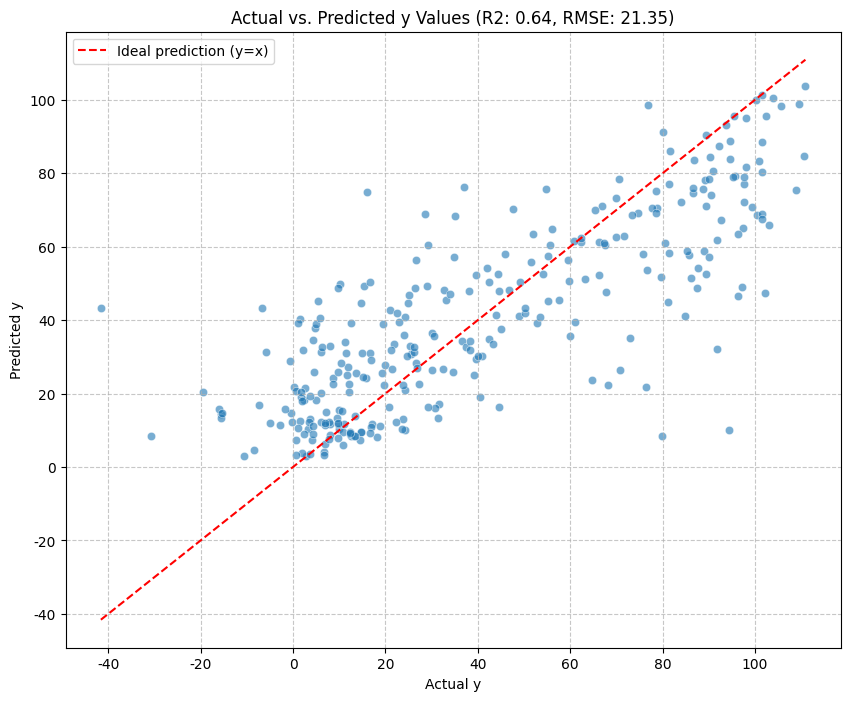

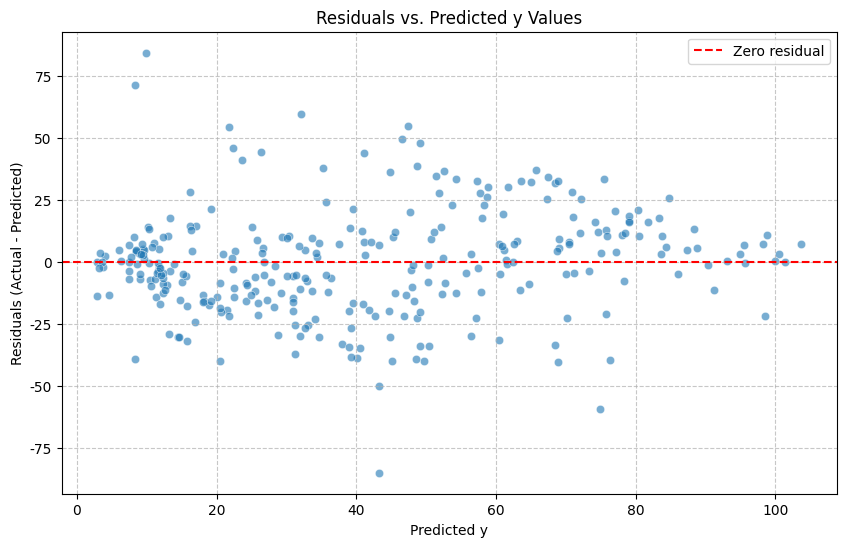

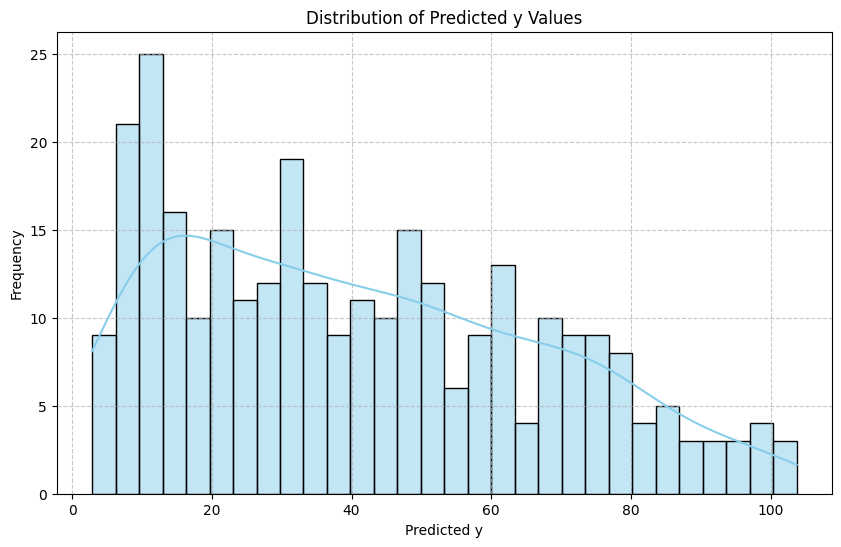

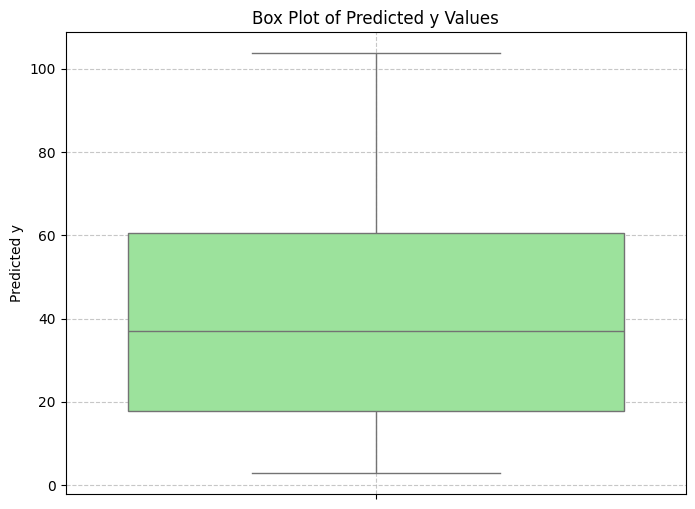


--- 予測、評価、および可視化の処理が完了しました ---


In [12]:
import pandas as pd
import lightgbm as lgb
import numpy as np
import os
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# LightGBMからのUserWarningを無視する設定
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# --- 設定 ---
# 予測用CSVファイルのパス (yカラムが含まれると仮定)
predict_csv_path_nc = 'ML_data/tox24_b_mord.csv'
predict_csv_path_c = 'ML_data/tox24_b_c_mord.csv'
# 目的変数のカラム名 (予測対象かつ、このデータセットにも含まれると仮定)
y_column = 'y'
# 識別子となるカラム名 (データ結合に使用)
identifier_columns = ["N"]
# 学習済みモデルのパス
model_load_path = 'trained_lgbm_model_for_prediction.pkl'
# 予測結果の保存パス
output_prediction_path = 'predictions_tox24_b_with_actuals.csv' # ファイル名を変更

# 学習時に使用した記述子のリスト（予測時も同じものを使用）
SELECTED_DESCRIPTORS = ['c_SLogP', 'c_ATSC1i', 'c_ETA_dEpsilon_D', 'c_AETA_beta_ns_d', 'nc_VSA_EState3', 'c_ETA_dEpsilon_B', 'nc_ATSC6p', 'nc_ATSC6pe', 'nc_SlogP_VSA11', 'nc_ATSC2d',
                        'c_BCUTi-1l', 'c_BCUTd-1l', 'nc_ATSC1i', 'nc_ATSC5pe', 'nc_FilterItLogS', 'nc_PEOE_VSA6', 'c_BCUTi-1h', 'c_ETA_shape_y', 'nc_IC5', 'nc_IC2', 'c_AMID_O', 'c_ETA_dBeta',
                        'nc_ATSC7d', 'nc_JGI8', 'nc_IC1', 'nc_ATSC3d', 'nc_ATSC1pe', 'nc_ATSC4pe', 'nc_ATSC3i', 'nc_VSA_EState2', 'nc_ATSC3dv', 'nc_SdO', 'nc_ATSC4Z', 'nc_ATSC8dv',
                        'nc_ATSC4dv', 'nc_PEOE_VSA8', 'nc_ATSC6v', 'c_AATSC0i', 'nc_ATSC1p', 'c_ATSC1p', 'nc_ATSC6i', 'nc_ATSC4p', 'c_FilterItLogS', 'nc_ATSC2pe', 'nc_ATSC3pe', 'nc_EState_VSA3',
                        'c_ATS0p', 'nc_JGI4', 'c_BCUTpe-1l', 'c_Mi', 'nc_SLogP', 'nc_ATSC8pe', 'nc_JGI3', 'c_SMR_VSA3', 'nc_ATSC2i', 'nc_ATSC4i', 'nc_ATSC7dv', 'c_AETA_eta_RL', 'nc_ATSC2v',
                        'nc_SMR_VSA3', 'c_ATSC1Z', 'nc_JGI6', 'nc_ATSC5i', 'c_AATS0i', 'c_BCUTdv-1l', 'nc_ATSC5v', 'nc_SIC3', 'c_ATSC2i', 'nc_ZMIC1', 'nc_Mi', 'c_ATSC7p', 'nc_TopoPSA',
                        'nc_SsCH3', 'nc_ATSC6d', 'nc_ATSC5Z', 'nc_AATSC0i', 'nc_EState_VSA6', 'c_BCUTdv-1h', 'c_ATSC4p', 'nc_BertzCT', 'c_ATSC6p', 'nc_PEOE_VSA10', 'c_ATSC3dv', 'c_ATSC6pe',
                        'c_ATSC1d', 'c_ATSC3pe', 'c_ATSC3p', 'nc_ATSC8p', 'nc_ATSC8d', 'nc_ATSC5d', 'nc_ATSC6Z', 'c_ATSC4dv', 'c_ATSC1v', 'c_ATSC4v', 'c_AMID_N', 'nc_PEOE_VSA9', 'c_ATSC2dv',
                        'c_nAcid', 'nc_SdsCH', 'c_ATSC1pe', 'c_AETA_eta_L', 'nc_ATSC3p', 'nc_WPath', 'nc_JGI5', 'nc_SaaCH', 'c_AATSC0p', 'nc_EState_VSA5', 'nc_AATS0i', 'nc_ATSC3v', 'c_ATSC2d',
                        'nc_ATSC7pe', 'c_ATSC2Z', 'c_AETA_eta', 'c_AATSC0v', 'c_FCSP3', 'c_AETA_beta_ns', 'nc_ATSC7v', 'nc_ATSC7Z', 'c_SlogP_VSA2', 'c_ATSC4d', 'c_ETA_shape_p', 'nc_ATSC3Z',
                        'c_Mp', 'nc_ATSC2Z', 'nc_VSA_EState7', 'nc_IC3', 'nc_ATSC1d', 'c_ETA_eta_FL', 'c_ATSC4pe', 'nc_ZMIC2', 'c_TIC1', 'nc_ATSC2dv', 'nc_SMR_VSA1', 'nc_AATS0dv', 'c_ATSC8dv',
                        'nc_SIC2', 'c_CIC5', 'nc_AATSC0p', 'c_EState_VSA2', 'c_IC3', 'c_BCUTv-1l', 'c_ETA_epsilon_5', 'c_IC5', 'c_ATSC4i', 'nc_VSA_EState4', 'c_VSA_EState8', 'c_BCUTp-1l',
                        'nc_ATSC5p', 'nc_EState_VSA2', 'nc_fMF', 'c_BCUTd-1h', 'nc_EState_VSA8', 'nc_ATSC1v', 'c_TopoPSA', 'nc_ATSC2m', 'nc_SlogP_VSA10', 'nc_JGI2', 'nc_ATSC4d', 'nc_VSA_EState5',
                        'nc_AATSC0v', 'nc_VSA_EState8', 'nc_Xp-5dv', 'nc_AATSC0pe', 'nc_Xc-3dv', 'c_AETA_beta', 'c_BCUTpe-1h', 'c_ZMIC2', 'nc_ATSC5dv', 'c_AETA_eta_FL', 'c_ATSC6v',
                        'c_AATS0v', 'nc_PEOE_VSA1', 'nc_PEOE_VSA2', 'nc_AATS0p', 'nc_ATSC8Z', 'nc_ATSC3m', 'nc_ATSC4v', 'c_ATSC7pe', 'nc_ATSC2p', 'c_ATSC2m', 'nc_SMR_VSA7', 'nc_ATSC7p', 'nc_ATSC0p',
                        'c_MID_h', 'c_ATSC2v', 'c_ATSC3i', 'nc_PEOE_VSA3', 'nc_ATS8dv', 'c_EState_VSA3', 'nc_ATSC7i', 'nc_ATS4i', 'c_MID_O', 'nc_ATSC0i', 'nc_nS', 'c_AETA_dBeta',
                        'c_ATSC5p', 'c_ATSC2p', 'c_ATSC5Z', 'nc_ATSC4m', 'nc_BalabanJ', 'c_PEOE_VSA8', 'c_ATSC7i', 'c_AETA_alpha', 'nc_JGI1', 'c_IC1', 'nc_JGT10', 'nc_JGI7', 'c_ATSC7v', 'c_ATSC5pe',
                        'c_PEOE_VSA1', 'nc_SlogP_VSA2', 'c_ETA_eta_L', 'nc_ATS7dv', 'nc_NsssCH', 'nc_ATS6dv', 'nc_ATS3pe', 'c_ATSC6dv', 'nc_PEOE_VSA7', 'nc_SdssC', 'nc_SMR_VSA9',
                        'c_Mv', 'c_PEOE_VSA9', 'c_ATSC6Z', 'nc_TopoPSA(NO)', 'nc_ZMIC5', 'c_ATSC8pe', 'nc_ATSC5m', 'c_SpMAD_A', 'c_BCUTv-1h', 'nc_SIC4', 'nc_AATS0d', 'nc_ATSC1m', 'nc_ATSC1Z',
                        'nc_ATSC8i', 'nc_AATSC0Z', 'nc_SIC0', 'nc_EState_VSA4', 'nc_EState_VSA7', 'c_AETA_beta_s', 'c_SlogP_VSA10', 'c_ETA_epsilon_4', 'c_AMID_C', 'nc_AATS0v', 'nc_ATSC1dv',
                        'c_ETA_eta', 'nc_piPC8', 'nc_ATSC0Z', 'c_ATSC3Z', 'c_ATSC6i', 'c_ATSC4Z', 'c_PEOE_VSA3', 'nc_nHBAcc', 'nc_CIC5', 'nc_JGI9', 'c_VSA_EState3', 'c_ATSC8p', 'nc_VSA_EState9',
                        'c_ETA_dEpsilon_A', 'c_ETA_psi_1', 'nc_Xp-7dv', 'nc_Xc-3d', 'nc_TopoShapeIndex', 'nc_MIC0', 'nc_ATS7i', 'c_AATS0d', 'nc_ZMIC4', 'c_ATSC8m', 'nc_CIC2', 'c_ATSC0p',
                        'c_ATSC3m', 'c_PEOE_VSA2', 'c_SM1_DzZ', 'nc_SMR_VSA6', 'nc_ATSC8v', 'nc_ATSC7m', 'nc_SIC1', 'c_SsOH', 'c_SpMax_A', 'nc_ATS5m', 'c_ATSC5v', 'c_ATSC5i', 'c_AMID_h', 'c_nBase',
                        'c_AATS0Z', 'c_BCUTZ-1h', 'c_ATSC3v', 'nc_LabuteASA', 'nc_SssNH', 'c_ATSC3d', 'c_ETA_epsilon_2', 'c_CIC2', 'nc_CIC0', 'nc_piPC2', 'nc_MIC4', 'nc_EState_VSA1',
                        'c_ETA_beta_ns_d', 'nc_EState_VSA9', 'nc_SsssCH', 'nc_SlogP_VSA3', 'c_ATSC5d', 'c_Xp-5dv', 'nc_GGI6', 'c_SpAbs_Dzp', 'nc_ATS3i', 'nc_Mp', 'c_ATSC2pe', 'c_ATS3p', 'c_C1SP3',
                        'nc_Xp-6dv', 'nc_AATSC0dv', 'nc_AATSC0d', 'nc_GGI5', 'c_ATSC7d', 'c_ATSC8d', 'c_PEOE_VSA6', 'c_SdO', 'c_SsCH3', 'c_SdsCH', 'c_SpMAD_DzZ', 'nc_FCSP3', 'nc_TIC1',
                        'nc_ATSC6dv', 'nc_TIC3', 'nc_TIC0', 'c_VR2_A', 'nc_ATSC0v', 'nc_ATSC8m', 'c_BCUTZ-1l', 'c_ATS3m', 'nc_SIC5', 'nc_ATS8i', 'nc_ATS6i', 'nc_Xpc-5d', 'nc_ATS4Z', 'c_AATS0p',
                        'nc_ATS0Z', 'nc_ATS3d', 'c_ETA_eta_F', 'c_AETA_eta_F', 'c_ATSC0Z', 'c_ATSC7m', 'nc_SlogP_VSA5', 'nc_nAcid', 'nc_Xch-5dv', 'c_AMID', 'c_SpMAD_Dzpe', 'c_NsOH',
                        'nc_Diameter', 'c_EState_VSA6', 'c_Xp-2dv', 'nc_Xp-1dv', 'c_Xp-3d', 'c_Xc-3dv', 'c_CIC4', 'c_BalabanJ', 'c_CIC0', 'c_SpMAD_Dzp', 'nc_Xpc-6dv', 'c_AATS0dv', 'nc_ATS5d',
                        'c_SMR', 'nc_bpol', 'c_ATSC1dv', 'nc_ATS0p', 'nc_ATS7d', 'c_ATS3Z', 'nc_ATS3dv', 'c_ATSC5dv', 'c_ATS0Z', 'c_ATSC6d', 'c_PEOE_VSA12', 'c_ETA_beta_ns', 'c_ETA_epsilon_1',
                        'c_PEOE_VSA10', 'c_MIC1', 'c_ATSC8Z', 'c_SdssC', 'c_ZMIC5', 'c_ZMIC4', 'nc_ATS5p', 'c_SddssS', 'nc_ATSC0dv', 'nc_CIC3', 'nc_Xp-7d', 'c_MID_N', 'nc_Xp-2dv', 'c_ATSC0i',
                        'c_IC2', 'nc_SsOH', 'nc_IC4', 'nc_CIC1', 'nc_Xp-5d', 'nc_nHBDon', 'c_MID_C', 'nc_CIC4', 'c_SpDiam_A', 'nc_MIC1', 'nc_ECIndex', 'nc_SlogP_VSA6', 'c_ATSC7Z', 'nc_VSA_EState1',
                        'c_VE1_A', 'c_ATSC4m', 'c_SpAbs_DzZ', 'nc_TSRW10', 'c_nS', 'c_AATSC0pe', 'c_ATSC7dv', 'c_ATSC8i', 'nc_GGI7', 'nc_MPC10', 'c_ATS8i', 'c_SM1_Dzp', 'c_ATS2p', 'c_ATSC0pe',
                        'nc_nRot', 'nc_piPC9', 'c_BCUTp-1h', 'c_ATSC5m', 'c_VSA_EState9', 'nc_Xch-7dv', 'nc_Xpc-5dv', 'nc_Xpc-4dv', 'c_PEOE_VSA7', 'nc_Xc-5dv', 'nc_AATS0m', 'nc_ATS1Z', 'nc_ATS2Z',
                        'nc_ATSC0m', 'nc_ATS2d', 'nc_ATS0v', 'c_TIC2', 'nc_Xch-7d', 'nc_ATS1m', 'nc_ATS6m', 'nc_AATSC0m', 'c_SMR_VSA1', 'nc_ATSC0pe', 'nc_ATS3m', 'c_MIC2', 'c_MIC3', 'nc_NssCH2',
                        'nc_ATS4p', 'c_MIC4', 'nc_fragCpx', 'nc_ATS1dv', 'nc_MZ', 'nc_ATS2dv', 'nc_TIC2', 'nc_Xp-3dv', 'nc_ATS5i', 'nc_AATS0pe', 'c_ATS5d', 'nc_n6AHRing', 'nc_ATS2i', 'c_ATS4Z',
                        'nc_ATSC6m', 'nc_ATS6pe', 'c_nRot', 'c_SpMAD_D', 'c_ATS2dv', 'c_AATSC0Z', 'c_VSA_EState2', 'c_EState_VSA5', 'nc_NdssC', 'c_EState_VSA7', 'c_SM1_Dzpe', 'nc_GGI9', 'nc_Mv',
                        'c_EState_VSA9', 'nc_Xp-4dv', 'c_BertzCT', 'nc_C1SP3', 'c_SpDiam_DzZ', 'nc_Xpc-4d', 'c_VSA_EState7', 'c_ABC', 'nc_Xch-6dv', 'c_ZMIC3', 'c_Xpc-5d', 'c_Xpc-5dv', 'nc_ATS6v',
                        'nc_ATS4pe', 'c_ZMIC1', 'nc_piPC3', 'nc_ATS4dv', 'nc_ATS5dv', 'nc_piPC7', 'nc_ATS2m', 'nc_IC0', 'c_ETA_dEpsilon_C', 'nc_ATS6d', 'nc_SaasC', 'c_fragCpx', 'c_ATS1pe', 'c_fMF',
                        'nc_ATS7Z', 'c_ATSC0dv', 'nc_ATS3Z', 'nc_ATS8m', 'nc_piPC10', 'nc_MIC3', 'c_JGI4', 'c_TSRW10', 'nc_PEOE_VSA11', 'c_ETA_epsilon_3', 'c_ATS3pe', 'c_ATSC0m', 'c_ETA_alpha',
                        'c_ATSC8v', 'c_MIC5', 'c_ETA_beta', 'nc_SssCH2', 'nc_MIC5', 'c_IC0', 'c_ATS8pe', 'c_ATSC0d', 'nc_nHetero', 'nc_Xp-3d', 'nc_ATS8d', 'nc_MWC06', 'nc_JGI10', 'nc_WPol', 'nc_SRW10',
                        'nc_Xc-6dv', 'c_SpDiam_Dzpe', 'nc_Sv', 'c_VSA_EState1', 'c_ATS3i', 'c_AATS0pe', 'nc_ABCGG', 'nc_ATS4v', 'nc_ATS8v', 'c_ATS3v', 'nc_GGI2', 'c_ATS2m', 'nc_ATS3p',
                        'c_ATS7pe', 'c_ATS3d', 'c_TopoPSA(NO)', 'nc_ATSC0d', 'c_ATS1p', 'c_ATS4dv', 'nc_ATS4m', 'nc_mZagreb2', 'c_AATSC0dv', 'c_AATSC0m', 'c_ATS2i', 'nc_nBondsD', 'c_VR1_A', 'nc_C2SP3',
                        'c_LogEE_A', 'nc_C3SP3', 'c_ATS7i', 'nc_ATS8Z', 'nc_ATS5Z', 'c_ABCGG', 'nc_GGI3', 'nc_SlogP_VSA1', 'nc_NddsN', 'nc_EState_VSA10', 'nc_nHRing', 'c_ETA_shape_x',
                        'c_CIC3', 'c_CIC1', 'c_TIC5', 'nc_piPC6', 'c_Xp-1d', 'nc_piPC4', 'nc_SssO', 'c_SM1_Dzi', 'c_SaaCH', 'c_IC4', 'c_LabuteASA', 'nc_SddssS', 'nc_MPC7', 'c_SMR_VSA7', 'c_Sm', 'c_Xp-6dv',
                        'nc_VMcGowan', 'nc_ZMIC3', 'c_Xp-3dv', 'nc_MIC2', 'c_EState_VSA4', 'c_Xp-7dv', 'c_ATS4v', 'c_NsCH3', 'c_VMcGowan', 'nc_AATS0Z', 'c_nFHRing', 'c_NdsCH',
                        'nc_ATS0pe', 'c_SaasC', 'c_SssO', 'c_ATS1v', 'c_ATS2Z', 'c_ATS0v', 'nc_ATS8p', 'c_nHRing', 'c_SsssCH', 'nc_ATS8pe', 'c_bpol', 'c_NaasC', 'c_ZMIC0', 'nc_ATS2p', 'c_piPC3', 'nc_ATS6p',
                        'c_TpiPC10', 'c_ATS1Z', 'c_ATS5Z', 'nc_naHRing', 'nc_GGI1', 'c_ECIndex', 'nc_ATS0dv', 'nc_ATS4d', 'nc_SsCl', 'nc_ATS1d', 'nc_TIC4', 'nc_TIC5', 'c_ATSC6m',
                        'nc_nX', 'c_nHBAcc', 'c_GGI2', 'c_JGI1', 'c_JGI2', 'nc_ZMIC0', 'c_MWC03', 'c_ETA_dAlpha_A', 'nc_VSA_EState6', 'c_AETA_eta_R', 'nc_ATS2v', 'c_ATS1i', 'c_ATS6pe', 'c_MIC0', 'c_Sp',
                        'nc_ATS7m', 'c_ATS7p', 'nc_piPC5', 'nc_SaaN', 'nc_MPC4', 'nc_SsssN', 'c_ATSC0v', 'c_ATS6i', 'nc_ATS0m', 'nc_MPC9', 'nc_ATS6Z', 'nc_SsNH2', 'c_ATS7d', 'nc_MWC05',
                        'c_SpDiam_Dzi', 'nc_MWC07', 'nc_Xch-6d', 'c_Xpc-4dv', 'c_BCUTm-1l', 'c_SlogP_VSA5', 'nc_Mm', 'nc_NssssC', 'nc_Sp', 'c_SlogP_VSA4', 'nc_Xc-5d', 'nc_Sm', 'c_VE3_Dzv', 'c_VE2_A',
                        'c_SlogP_VSA1', 'c_SM1_Dzv', 'c_ATS6dv', 'nc_Xpc-6d', 'c_SpMAD_Dzv', 'c_SlogP_VSA3', 'c_VSA_EState5', 'nc_Xp-6d', 'nc_MWC10', 'c_SpMax_Dzv', 'nc_SMR_VSA5', 'c_Xp-2d',
                        'c_SpAbs_Dzv', 'c_VE3_A', 'c_VR2_Dzpe', 'c_Xp-6d', 'c_SMR_VSA6', 'nc_NaasC', 'c_Xp-4dv', 'nc_NsCH3', 'c_AATSC0d', 'c_MID_X', 'c_ATS0dv', 'nc_C1SP2', 'nc_C2SP2', 'nc_GGI10',
                        'c_EState_VSA8', 'c_ATS3dv', 'c_EState_VSA1', 'nc_nBondsS', 'c_SRW04', 'c_SpAD_Dzv', 'c_ETA_eta_R', 'c_SpDiam_Dzv', 'c_SRW08', 'c_TMWC10', 'c_SpAbs_Dzi', 'c_MWC09', 'c_MWC08',
                        'c_SpMAD_Dzi', 'c_MWC04', 'c_VR2_Dzp', 'c_VR1_Dzv', 'c_EState_VSA10', 'c_Diameter', 'c_JGT10', 'c_SpAD_Dzp', 'c_GGI5', 'c_GGI7', 'c_GGI4', 'c_Spe', 'c_VE2_DzZ', 'c_PEOE_VSA5',
                        'c_nFRing', 'c_Xp-4d', 'c_nRing', 'c_AMID_X', 'c_MPC3', 'c_PEOE_VSA4', 'c_MPC4', 'c_MPC5', 'c_BCUTm-1h', 'c_piPC2', 'c_Xp-7d', 'c_piPC5', 'c_Xp-1dv', 'c_PEOE_VSA13',
                        'c_PEOE_VSA11', 'c_Mpe', 'c_Xpc-6dv', 'c_SsssN', 'c_TIC3', 'c_VSA_EState6', 'c_VR1_Dzi', 'c_nBondsS', 'c_nBondsD', 'c_C2SP3', 'c_C3SP3', 'c_Xch-5d', 'c_Xch-6d', 'c_Xch-7d',
                        'c_SddsN', 'c_ETA_beta_s', 'c_Xch-5dv', 'c_Xch-6dv', 'c_Xch-7dv', 'c_Xc-3d', 'c_Xc-5d', 'c_Xc-6dv', 'c_TIC4', 'nc_ABC', 'c_mZagreb2', 'c_nO', 'nc_n6ARing', 'nc_GGI8',
                        'nc_ATS2pe', 'nc_MWC02', 'nc_MWC08', 'nc_SssssC', 'nc_ATS7v', 'nc_SddsN', 'nc_ATS0d', 'nc_nO', 'nc_nN', 'nc_SRW08', 'nc_MW', 'c_SpAbs_A', 'c_nAtom', 'nc_GhoseFilter', 'c_nH',
                        'nc_GGI4', 'nc_SMR', 'nc_NssS', 'nc_nBondsM', 'nc_Xp-2d', 'nc_Xc-6d', 'nc_Xp-4d', 'nc_Spe', 'nc_C3SP2', 'nc_NdsCH', 'nc_nBondsKS', 'nc_nFHRing', 'nc_ATS5pe', 'nc_n10FRing',
                        'nc_NsNH2', 'nc_ATS1i', 'nc_ATS0i', 'nc_ATS7p', 'nc_ATS1p', 'nc_NsOH', 'nc_PEOE_VSA5', 'nc_Xp-1d', 'nc_MPC8', 'nc_PEOE_VSA13', 'c_ATS0m', 'nc_MPC5', 'c_ATS8m', 'c_ATS1m',
                        'nc_SlogP_VSA4', 'c_ATS4p', 'c_ATS5p', 'c_ATS0d', 'c_ATS5v', 'c_ATS6p', 'nc_nBase', 'c_ATS5m', 'c_ATS6m', 'c_ATS7dv', 'c_ATS6v', 'nc_TMPC10', 'c_ATS5dv', 'c_ATS0i', 'c_ATS1dv',
                        'c_nX', 'c_ATS4i', 'c_ATS5i', 'c_ATS2pe']


# --- 学習済みモデルのロード ---
print("--- 学習済みモデルのロードを開始 ---")
try:
    with open(model_load_path, 'rb') as f:
        model = pickle.load(f)
    print(f"モデル '{model_load_path}' を正常にロードしました。")
except FileNotFoundError:
    print(f"エラー: モデルファイル '{model_load_path}' が見つかりません。モデル作成スクリプトを実行して保存されていることを確認してください。")
    exit()
except Exception as e:
    print(f"エラー: モデルのロードに失敗しました: {e}")
    exit()

# --- 予測データの読み込みと結合 ---
print("\n--- 予測データの読み込みと結合処理を開始 ---")
try:
    # yカラムも読み込むように変更
    df_nc_pred = pd.read_csv(predict_csv_path_nc)
    df_c_pred = pd.read_csv(predict_csv_path_c)
except FileNotFoundError as e:
    print(f"エラー: 予測用CSVファイルが見つかりません: {e.filename}")
    exit()

if "SMILES" not in df_nc_pred.columns or "SMILES" not in df_c_pred.columns:
    print("エラー: 'SMILES' カラムが両方の予測用CSVファイルに存在しません。")
    exit()
# ここで 'y' カラムが存在するか確認
if y_column not in df_nc_pred.columns and y_column not in df_c_pred.columns:
    print(f"エラー: 予測データに目的変数 '{y_column}' カラムが見つかりませんでした。")
    print("このスクリプトは予測データに実測値が含まれることを前提としています。")
    exit()


# ncデータセットの記述子にプレフィックスを付ける
nc_cols_to_prefix_pred = [col for col in df_nc_pred.columns if col not in identifier_columns + ["SMILES", y_column]] # y_columnを除外
df_nc_features_prefixed_pred = df_nc_pred[nc_cols_to_prefix_pred].rename(columns={col: f'nc_{col}' for col in nc_cols_to_prefix_pred})
df_nc_processed_pred = pd.concat([df_nc_pred[identifier_columns + [y_column, "SMILES"]], df_nc_features_prefixed_pred], axis=1)

# cデータセットの記述子にプレフィックスを付ける
c_cols_to_prefix_pred = [col for col in df_c_pred.columns if col not in identifier_columns + ["SMILES"]] # y_columnはdf_nc_predで取得済みと仮定
df_c_features_prefixed_pred = df_c_pred[c_cols_to_prefix_pred].rename(columns={col: f'c_{col}' for col in c_cols_to_prefix_pred})
df_c_processed_pred = pd.concat([df_c_pred[identifier_columns + ["SMILES"]], df_c_features_prefixed_pred], axis=1)

# データを結合
df_combined_pred = pd.merge(df_nc_processed_pred, df_c_processed_pred, on=identifier_columns, how='inner', suffixes=('_nc', '_c'))

if 'SMILES_c' in df_combined_pred.columns and 'SMILES_nc' in df_combined_pred.columns:
    df_combined_pred.drop(columns=['SMILES_c'], inplace=True)
    df_combined_pred.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)
elif 'SMILES_c' in df_combined_pred.columns:
    df_combined_pred.rename(columns={'SMILES_c': 'SMILES'}, inplace=True)
elif 'SMILES_nc' in df_combined_pred.columns:
    df_combined_pred.rename(columns={'SMILES_nc': 'SMILES'}, inplace=True)

# y_columnが重複している場合は削除 (ncから来ているy_columnを保持)
if f'{y_column}_c' in df_combined_pred.columns:
    df_combined_pred.drop(columns=[f'{y_column}_c'], inplace=True)
if f'{y_column}_nc' in df_combined_pred.columns: # 正しいyカラム名に統一
    df_combined_pred.rename(columns={f'{y_column}_nc': y_column}, inplace=True)


if len(df_combined_pred) == 0:
    print("エラー: 予測データ結合後のデータフレームが空です。処理を中止します。")
    exit()
print(f"結合後の予測データフレーム形状: {df_combined_pred.shape}")

# --- 予測用特徴量の準備 ---
print("--- 予測用特徴量の準備を開始 ---")
X_predict = df_combined_pred[SELECTED_DESCRIPTORS].copy()
y_actual = df_combined_pred[y_column].copy() # 実測値を取得

for col in X_predict.columns:
    X_predict[col] = pd.to_numeric(X_predict[col], errors='coerce')

# 学習データと予測データのカラム順序が同じであることを確認
missing_cols = set(SELECTED_DESCRIPTORS) - set(X_predict.columns)
for c in missing_cols:
    X_predict[c] = np.nan # 欠損値で埋める

# 学習時に使用した記述子に絞り込み、順序を合わせる
X_predict = X_predict[SELECTED_DESCRIPTORS]

if X_predict.empty or X_predict.shape[1] == 0:
    print("エラー: 全ての前処理後、予測用特徴量が残っていません。予測を中止します。")
    exit()
print(f"予測用特徴量X_predictの最終形状: {X_predict.shape}")

# --- 予測の実行 ---
print("\n--- 予測を実行中 ---")
predictions = model.predict(X_predict)
print("予測が完了しました。")

# --- 予測結果の評価 ---
print("\n--- 予測結果の評価を開始 ---")

# R2スコアの計算
r2 = r2_score(y_actual, predictions)
print(f"予測データに対するR2スコア: {r2:.4f}")

# RMSEの計算
rmse = np.sqrt(mean_squared_error(y_actual, predictions))
print(f"予測データに対するRMSE: {rmse:.4f}")

# --- 結果の保存 ---
print("\n--- 予測結果を保存中 ---")
# 識別子、SMILES、実測値、予測値を結合
results_df = df_combined_pred[identifier_columns + ["SMILES", y_column]].copy()
results_df['Predicted_y'] = predictions

# 結果をCSVファイルとして保存
results_df.to_csv(output_prediction_path, index=False)
print(f"予測結果を '{output_prediction_path}' に保存しました。")

# --- 予測結果の可視化 ---
print("\n--- 予測結果の可視化を開始 ---")

# 日本語フォント設定 (必要であればコメント解除して使用)
try:
    plt.rcParams['font.family'] = 'DejaVu Sans' # Colab, Jupyterなどでの一般的なフォント
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の表示
except:
    pass # フォント設定が不要な環境ではエラーにならないように

# 予測値 vs. 実測値の散布図
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_actual, y=predictions, alpha=0.6)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', label='Ideal prediction (y=x)') # 理想的な予測線
plt.title(f'Actual vs. Predicted y Values (R2: {r2:.2f}, RMSE: {rmse:.2f})')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 残差プロット (Residual Plot)
residuals = y_actual - predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', label='Zero residual')
plt.title('Residuals vs. Predicted y Values')
plt.xlabel('Predicted y')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 予測値のヒストグラム (以前のコードから継続)
plt.figure(figsize=(10, 6))
sns.histplot(predictions, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Predicted y Values')
plt.xlabel('Predicted y')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 予測値の箱ひげ図 (以前のコードから継続)
plt.figure(figsize=(8, 6))
sns.boxplot(y=predictions, color='lightgreen')
plt.title('Box Plot of Predicted y Values')
plt.ylabel('Predicted y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n--- 予測、評価、および可視化の処理が完了しました ---")